In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob, os, yaml, itertools, subprocess, sys, shutil,sparse

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings, pickle
warnings.filterwarnings("ignore")

import matplotlib
from matplotlib.ticker import ScalarFormatter, MaxNLocator

# load all utils functions
os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

sys.path.append("utils")
from data_utils import *
from inSilicoMut_utils import *

drug_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
amino_acid_biophysical_properties = pd.read_csv("./data_processing/protein_seqs/biophysical_properties_AA.csv", index_col=[0])

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

drugs_lst = ['EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)
df_samples_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

# Analysis of in silico mutagenesis

# 1. Plot ECDFs for Global Check

In [2]:
def plot_ECDF(model_path, cc, regression=False, log_base=2, V1=False, include_uncertain=True, saveFig=False, show=False):

    drug = model_path.split("_")[0]
    full_drug_name = abbr_drug_dict[drug]

    # need to get predictions for all mutations across all loci
    dfs_lst = []

    if regression:
        search_path = os.path.join(results_dir, model_path, "ridge", "inSilico_analysis", "*", "*test_predictions.csv")
    else:
        search_path = os.path.join(results_dir, model_path, "inSilico_analysis", "*", "*test_predictions.csv")

    for fName in glob.glob(search_path):

        df = pd.read_csv(fName).rename(columns={'ROLLINGDB_ID': 'variant'})
        # df['variant'] = df['variant'].str.replace('_p_', '_p.').str.replace('_c_', '_c.').str.replace('+', '*')

        df = df.merge(who_variants.query("drug==@full_drug_name")[['variant', 'effect']], on='variant', how='left')

        # add critical concentratio
        df['CC'] = cc_dict[drug]

        # all variants should be in the who_variants dataframe, so there should only be 1 NaN in the effect column for H37Rv
        assert sum(pd.isnull(df['effect'])) == 1

        df['Locus'] = os.path.basename(os.path.dirname(fName))
        dfs_lst.append(df)

    df = pd.concat(dfs_lst)#.drop_duplicates("variant", keep="first")

    # check that they all have the same prediction for H37Rv. Higher threshold for PZA
    if drug == 'PZA':
        if df.query("variant=='MT_H37Rv'").pred_MIC.max() - df.query("variant=='MT_H37Rv'").pred_MIC.min() > 1e-4:
            raise ValueError(f"Problem with {model_path} predictions")
    else:
        if df.query("variant=='MT_H37Rv'").pred_MIC.max() - df.query("variant=='MT_H37Rv'").pred_MIC.min() > 1e-6:
            raise ValueError(f"Problem with {model_path} predictions")
        
    # put in same format as the in silico mutations to subset
    if V1:
        catalog_variants = who_variants_V1.copy().query("drug==@drug")
    else:
        catalog_variants = who_variants_V2.copy().rename(columns={'FINAL CONFIDENCE GRADING': 'confidence'}).loc[who_variants_V2['drug']==abbr_drug_dict[drug]]
    
    h37Rv_pred = df.query("variant=='MT_H37Rv'").pred_MIC.values[0]
    # print(f"H37Rv prediction: {np.round(h37Rv_pred, 2)} µg/mL")
    
    # get confidences. This also keeps only the mutations in that version of the catalog
    df = df.merge(catalog_variants[['variant', 'confidence']], on='variant', how='left')

    # assert sum(pd.isnull(df['confidence'])) == 0

    # when the same variant is tested in multiple loci (because it's in an overlapping upstream region), keep the prediction that's farther away from the H37Rv prediction
    df['ref_pred'] = h37Rv_pred
    # df['diff_from_ref'] = np.abs(df['pred_MIC'] - df['ref_pred'])
    df['fold_change'] = df['pred_MIC'] / df['ref_pred']
    df['log2_fold_change'] = np.log2(df['fold_change'])
    
    df = df.sort_values(['variant', 'fold_change'], ascending=[True, False]).drop_duplicates('variant', keep='first')

    if not include_uncertain:
        plot_df = df.query("variant != 'MT_H37Rv' & confidence != '3) Uncertain significance'")
    else:
        plot_df = df.query("variant != 'MT_H37Rv'")

    # print(plot_df.groupby("confidence")['pred_MIC'].agg(['mean', 'median']))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    sns.ecdfplot(data=plot_df, 
                 x='pred_MIC', 
                 hue="confidence", 
                 hue_order=np.sort(plot_df["confidence"].unique()),
                 palette=dict(zip(['1) Assoc w R', '2) Assoc w R - Interim', '3) Uncertain significance', '4) Not assoc w R - Interim', '5) Not assoc w R'], sns.color_palette("colorblind").as_hex())),
                 ax=ax,
                 log_scale=log_base, # for PZA, set to 10 to spread out the graph
                 zorder=3
                )
    
    # ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))
    ax.set_yticks(ticks=[0.25, 0.5, 0.75, 1], labels=[25, 50, 75, 100])

    for percentile in [0.25, 0.5, 0.75]:
        plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)

    # plt.axvline(x=cc, linestyle='--', color="black", linewidth=1, zorder=0, label=f"CC = {cc} µg/mL")
    plt.xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Percentile",  fontsize=8)
    plt.title(f"Predicted MICs of {plot_df.variant.nunique()} WHO Catalog Mutations\n", fontsize=10)
    
    y = plot_df['pred_MIC']
    plt.xlim(y.min()*1.1, y.max()*1.1)

    sns.move_legend(ax, fontsize=7, title='', ncol=1, loc='upper right', bbox_to_anchor=(1.45, 0.6))
    # sns.move_legend(ax, fontsize=6, title='', ncol=5, loc='upper right', bbox_to_anchor=(1, -0.15))#, bbox_to_anchor=(1.5, 0.6))
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveFig:
        if not os.path.isdir(f"results/{abbr_drug_dict[drug]}"):
            os.makedirs(f"results/{abbr_drug_dict[drug]}")
            
        plt.savefig(f"results/{abbr_drug_dict[drug]}/insilico_ECDF.svg", format='svg', bbox_inches='tight')
        plt.close()
    else:
        if show:
            plt.show()
        else:
            plt.close()

    if 'category' in df.columns:
        del df['category']
        
    return df.reset_index(drop=True)

In [3]:
def get_permutation_results_single_model(model_path):

    single_drug_permutation_predictions_fNames = glob.glob(f"{results_dir}/{model_path}/inSilico_analysis/*/test_predictions_*.csv")
    
    single_drug_permutation_predictions = []
    
    for fName in single_drug_permutation_predictions_fNames:
        suffix = os.path.basename(fName).split('.')[0][-1]
        df = pd.read_csv(fName)
        df['Permutation'] = suffix
        df['ref_pred'] = df.query("ROLLINGDB_ID=='MT_H37Rv'").pred_MIC.values[0]
        df = df.query("ROLLINGDB_ID != 'MT_H37Rv'")
        single_drug_permutation_predictions.append(df)
    
    single_drug_permutation_predictions = pd.concat(single_drug_permutation_predictions)
    single_drug_permutation_predictions.rename(columns={'ROLLINGDB_ID': 'variant'}, inplace=True)
    single_drug_permutation_predictions['log2_fold_change'] = np.log2(single_drug_permutation_predictions['pred_MIC'] / single_drug_permutation_predictions['ref_pred'])
    
    # check that eveyr permutation has the same prediction for H37Rv across the different loci
    # assert single_drug_permutation_predictions.groupby(["Permutation"]).ref_pred.nunique().nunique() == 1

    for perm in single_drug_permutation_predictions.Permutation.unique():
        assert single_drug_permutation_predictions.query("Permutation==@perm").ref_pred.nunique() <= 2

        if single_drug_permutation_predictions.query("Permutation==@perm").ref_pred.nunique() == 2:
            assert np.isclose(single_drug_permutation_predictions.query("Permutation==@perm").ref_pred.unique()[0], single_drug_permutation_predictions.query("Permutation==@perm").ref_pred.unique()[1])

    return single_drug_permutation_predictions

In [4]:
def compute_insilico_prediction_pvalue_from_permutations(df_pred, df_permutation_pred, variant):

    log2FC_predicted_MIC = df_pred.query("variant==@variant")['log2_fold_change'].values[0]

    permuted_log2FC_predicted_MICs = df_permutation_pred.query("variant==@variant")['log2_fold_change'].values
    
    # could be 20 if a variant is in the overlap region between two loci (like ethA and ethR intergenic variants)
    assert len(permuted_log2FC_predicted_MICs) in [10, 20]

    # get the proportion of the predictions that are at least as extreme as the test prediction
    # directionality is determined by whether the test prediction is less than or greater than the H37Rv prediction, for which we use the log2_fold_change column
    if log2FC_predicted_MIC > 0:
        pval = np.mean(permuted_log2FC_predicted_MICs >= log2FC_predicted_MIC)
    else:
        pval = np.mean(permuted_log2FC_predicted_MICs <= log2FC_predicted_MIC)

    # also return the average log2 fold change of the permutation models predictions
    return np.mean(permuted_log2FC_predicted_MICs), pval

In [6]:
all_drugs_insilico_pred = []

for drug in drugs_lst:   

    if drug in drugs_lst:

        # lineage SNPs worsened the PZA model
        if drug == 'PZA':
            log_base = 10
            model_path = f"{drug}_amino_acid"
        # AF thresh = 0.25 for the FQs
        # elif drug in ['MXF', 'LFX']:
        #     log_base = 2
        #     model_path = f"{drug}_lineage_amino_acid_AF25"
        else:
            log_base = 2
            model_path = f"{drug}_lineage_amino_acid"
        
        # try:
        df = plot_ECDF(model_path, cc_dict[drug], log_base=log_base, include_uncertain=True, V1=False, saveFig=True, show=True)
        df['gene'] = df['variant'].str.split('_').str[0]
        df.loc[df['variant']=='MT_H37Rv', 'gene'] = 'MT_H37Rv'
        
        df['drug'] = abbr_drug_dict[drug]
        df = df.reset_index(drop=True)

        # # get the predictions from the permuted models
        # df_permutation_predictions = get_permutation_results_single_model(model_path)

        # # add the average log2 FC prediction for each variant and the p-value to df
        # for i, row in df.iterrows():

        #     if row['variant'] != 'MT_H37Rv':
        #         mean_permutation_pred_log2FC, pval = compute_insilico_prediction_pvalue_from_permutations(df, df_permutation_predictions, row['variant'])
        #         df.loc[i, ['mean_permutation_log2FC', 'pval']] = mean_permutation_pred_log2FC, pval
                
        all_drugs_insilico_pred.append(df)
            
        # except:
        #     print(f"{drug} failed")

    # kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", 'r'))

    # print(drug)
    # print(np.sort(df.gene.unique()))
    # print(np.sort(np.array(kwargs['tier1_loci'])))
    
all_drugs_insilico_pred = pd.concat(all_drugs_insilico_pred).reset_index(drop=True)
# all_drugs_insilico_pred.to_csv("supplement/insilico_pred_all.csv", index=False)

# get silent variants
silent_variants_insilico_pred = all_drugs_insilico_pred.query("effect in @silent_lst")

In [23]:
isolate_variants.query("variant=='ethA_p.Arg207Gly'").merge(df_ETO)

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
0,SAMEA7561550,4326855,G,C,PASS,3347.0,False,1.0,101.0,34.0,...,"beijing,mungi","lin2.2.1,central_asia",NaN,0.011364,2,-6.459432,0,0.0,2-0,validation_set


In [22]:
df_ETO = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv")

In [24]:
old_pred.query("variant=='ethA_p.Arg207Gly'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
4891,ethA_p.Arg207Gly,0.797577,1.738179,missense_variant,5.0,ethA,1) Assoc w R,1.002264,1.734253,0.794315,ethA,Ethionamide


In [8]:
who_variants.loc[who_variants['FINAL CONFIDENCE GRADING']=='1) Assoc w R'].query("drug=='Ethionamide'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
16401,Ethionamide,ethA,LoF,ethA_LoF,1,LoF,"(see ""Genomic_coordinates"" sheet)",1.0,1291.0,658.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
16467,Ethionamide,ethA,p.Arg207Gly,ethA_p.Arg207Gly,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,57.0,36.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1
16900,Ethionamide,ethA,p.Lys37fs,ethA_p.Lys37fs,1,frameshift,"(see ""Genomic_coordinates"" sheet)",1.0,164.0,81.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
16906,Ethionamide,ethA,p.Met1?,ethA_p.Met1?,1,start_lost,"(see ""Genomic_coordinates"" sheet)",1.0,99.0,52.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
17185,Ethionamide,ethA,p.Tyr235fs,ethA_p.Tyr235fs,1,frameshift,"(see ""Genomic_coordinates"" sheet)",1.0,35.0,24.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
17520,Ethionamide,inhA,c.-777C>T,inhA_c.-777C>T,1,upstream_gene_variant,1673425,1.0,1434.0,939.0,...,NaN,1) Assoc w R,Alias fabG1_c.-15C>T,No change,NaN,NaN,yes,NaN,L,1


In [34]:
all_drugs_insilico_pred_regression = []

for drug in drugs_lst:   

    if drug in drugs_lst:

        # lineage SNPs did not worsen the PZA regression model, so use them here
        if drug == 'PZA':
            log_base = 10
        else:
            log_base = 2
        
        model_path = f"{drug}_lineage_amino_acid"
        
        df = plot_ECDF(model_path, cc_dict[drug], regression=True, log_base=log_base, include_uncertain=True, V1=False, saveFig=True, show=True)
        df['gene'] = df['variant'].str.split('_').str[0]
        df.loc[df['variant']=='MT_H37Rv', 'gene'] = 'MT_H37Rv'
        
        df['drug'] = abbr_drug_dict[drug]
        df = df.reset_index(drop=True)
        
        all_drugs_insilico_pred_regression.append(df)
            
all_drugs_insilico_pred_regression = pd.concat(all_drugs_insilico_pred_regression).reset_index(drop=True)

# get silent variants
silent_variants_insilico_pred_regression = all_drugs_insilico_pred_regression.query("effect in @silent_lst")

In [33]:
all_drugs_insilico_pred_regression.query("variant=='MT_H37Rv'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,MT_H37Rv,0.189746,1.140563,NaN,5.0,aftA-embCAB,NaN,1.140563,1.0,0.0,MT_H37Rv,Ethambutol
4713,MT_H37Rv,0.079856,1.056913,NaN,5.0,ethA,NaN,1.056913,1.0,0.0,MT_H37Rv,Ethionamide
6045,MT_H37Rv,-4.391494,0.047646,NaN,0.2,ahpC,NaN,0.047646,1.0,0.0,MT_H37Rv,Isoniazid
7985,MT_H37Rv,3.314146,9.946202,NaN,1.0,gyrBA,NaN,9.946202,1.0,0.0,MT_H37Rv,Levofloxacin
9390,MT_H37Rv,0.199606,1.148385,NaN,0.5,gyrBA,NaN,1.148385,1.0,0.0,MT_H37Rv,Moxifloxacin
10651,MT_H37Rv,4.726201,26.468436,NaN,100.0,clpC1,NaN,26.468436,1.0,0.0,MT_H37Rv,Pyrazinamide
11807,MT_H37Rv,-4.075611,0.059309,NaN,0.5,rpoBC,NaN,0.059309,1.0,0.0,MT_H37Rv,Rifampicin


In [25]:
all_drugs_insilico_pred.query("variant=='MT_H37Rv'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,MT_H37Rv,0.320308,1.248597,NaN,5.0,aftA-embCAB,NaN,1.248597,1.0,0.0,MT_H37Rv,Ethambutol
4713,MT_H37Rv,0.003262,1.002264,NaN,5.0,ethA,NaN,1.002264,1.0,0.0,MT_H37Rv,Ethionamide
6045,MT_H37Rv,-4.367011,0.048462,NaN,0.2,ahpC,NaN,0.048462,1.0,0.0,MT_H37Rv,Isoniazid
7985,MT_H37Rv,-1.984244,0.252745,NaN,1.0,gyrBA,NaN,0.252745,1.0,0.0,MT_H37Rv,Levofloxacin
9390,MT_H37Rv,-3.514702,0.087492,NaN,0.5,gyrBA,NaN,0.087492,1.0,0.0,MT_H37Rv,Moxifloxacin
10651,MT_H37Rv,4.640193,24.936594,NaN,100.0,clpC1,NaN,24.936594,1.0,0.0,MT_H37Rv,Pyrazinamide
11807,MT_H37Rv,-4.084623,0.058939,NaN,0.5,rpoBC,NaN,0.058939,1.0,0.0,MT_H37Rv,Rifampicin


# Any silent variants predicted to cause resistance?

In [141]:
silent_variants_insilico_pred.query("pred_MIC > CC").sort_values("fold_change", ascending=False)

# add any silent mutations predicted to cause resistance
silent_resistant_mutations = silent_variants_insilico_pred.query("pred_MIC > CC").sort_values("fold_change", ascending=False)
silent_resistant_mutations

# add Group 3 mutations with very high predicted PZA MICs
# PZA_Group3_high_MIC_mutations = all_drugs_insilico_pred.query("drug=='Pyrazinamide' & confidence=='3) Uncertain significance' & pred_MIC > 1000").sort_values("pred_MIC", ascending=False)

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
11131,pncA_c.3G>A,8.825194,453.57407,initiator_codon_variant,100.0,pncA,4) Not assoc w R - Interim,24.936594,18.189095,4.185002,pncA,Pyrazinamide


In [189]:
df_PZA = pd.read_csv(f"{data_dir}/PZA/data_for_model.csv")

In [196]:
len(isolate_variants.query("variant=='pncA_p.Met1?' & ROLLINGDB_ID in @df_PZA.ROLLINGDB_ID").REF.values[0])

846

In [206]:
isolate_variants.query("EFFECT.str.contains('|'.join(['start_lost', 'initiator_codon_variant']))").dropna(subset='GENE').query("GENE.str.contains('pncA')").merge(df_PZA[['ROLLINGDB_ID', 'category', 'Lineage']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,category,Lineage
0,SAMN05916261,2289239,C,T,PASS,3040.0,False,0.97,93.0,38.0,...,0.0,initiator_codon_variant,pncA,c.3G>A,p.Met1?,pncA_c.3G>A,Pyrazinamide,4) Not assoc w R - Interim,train_set,2
1,SAMN06094087,2289053,GTCCGGTGTGCCGGAGAAGTGGTCACCCGGGTCGATGTGGAAGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,...,NaN,start_lost,pncA,NaN,NaN,pncA_p.Met1?,Pyrazinamide,1) Assoc w R,train_set,4


In [33]:
def compute_number_isolates_with_variant(variant, drug_full_name):

    isolates_with_variant = isolate_variants.query("variant==@variant & drug == @drug_full_name").ROLLINGDB_ID.unique()

    df_training = pd.read_csv(f"{data_dir}/{drug_abbr_dict[drug_full_name]}/data_for_model.csv")

    return df_training.query("ROLLINGDB_ID in @isolates_with_variant & Span_CC == 0")['ROLLINGDB_ID'].nunique()

In [188]:
# df_codons_with_R_missense_mutations = []

# for drug in MXF_pred.drug.unique():

#     for gene in MXF_pred.query("drug==@drug").gene.unique():

#         if gene != 'MT_H37Rv':
    
#             R_mutations = who_variants.loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("gene==@gene & drug==@drug & effect == 'missense_variant'")['variant'].values
#             codons_with_R_mutations = []

#             for variant in R_mutations:
#                 try:
#                     codons_with_R_mutations.append(get_variant_number(variant, h37Rv_genes.query("Symbol==@gene")['Strand'].values[0]))
#                 except:
#                     # LoF, deletion, etc
#                     print(variant)

#             codons_with_R_mutations = np.unique(codons_with_R_mutations)
#             # print(drug, gene, codons_with_R_mutations)

#             df_single_drug_gene = pd.DataFrame({'Drug': drug, 'Gene': gene, 'Codon': codons_with_R_mutations})
            
#             df_codons_with_R_missense_mutations.append(df_single_drug_gene)

# df_codons_with_R_missense_mutations = pd.concat(df_codons_with_R_missense_mutations)

In [189]:
# for i, row in MXF_pred.iterrows():

#     drug = row['drug']
#     gene = row['gene']
#     codon = np.nan

#     if gene != 'MT_H37Rv':

#         if row['effect'] in ['initiator_codon_variant', 'start_lost']:
#             codon = 1
    
#         else:
    
#             start, end, sense = h37Rv_genes.query("Symbol==@gene")[['Start', 'End', 'Strand']].values[0]
#             coding_region_length = end - start + 1
    
#             if row['effect'] == 'stop_retained_variant':
#                 codon = coding_region_length / 3
    
#             elif row['effect'] in ['missense_variant', 'inframe_deletion', 'stop_gained', 'inframe_insertion']:
#                 codon = get_variant_number(row['variant'], sense)
                
#             elif row['effect'] == 'synonymous_variant':
#                 variant_number = get_variant_number(row['variant'], sense)
#                 codon = np.ceil(variant_number/3)

#         MXF_pred.loc[i, 'codon'] = codon
        
#         if codon in df_codons_with_R_missense_mutations.query("Drug==@drug & Gene==@gene")['Codon'].values:
#             MXF_pred.loc[i, 'same_codon_missense_R_variant'] = 1
#         else:
#             MXF_pred.loc[i, 'same_codon_missense_R_variant'] = 0

# print(MXF_pred.loc[pd.isnull(MXF_pred['codon'])].effect.unique())

In [190]:
ethA_nonsense = all_drugs_insilico_pred.query("drug=='Ethionamide' & gene=='ethA' & variant.str.contains('\*')")
ethA_nonsense_pred_R = ethA_nonsense.query("pred_MIC >= 5")
ethA_nonsense_pred_S = ethA_nonsense.query("pred_MIC < ref_pred")

print(f"{len(ethA_nonsense)} ethA nonsense mutations")
print(f"{len(ethA_nonsense_pred_R)}/{len(ethA_nonsense)} ({np.round(len(ethA_nonsense_pred_R)/len(ethA_nonsense)*100, 1)})% ethA nonsense mutations are predicted to cause resistance")
print(f"{len(ethA_nonsense_pred_S)}/{len(ethA_nonsense)} ({np.round(len(ethA_nonsense_pred_S)/len(ethA_nonsense)*100, 1)})% ethA nonsense mutations are predicted to cause susceptibility")

63 ethA nonsense mutations
9/63 (14.3)% ethA nonsense mutations are predicted to cause resistance
2/63 (3.2)% ethA nonsense mutations are predicted to cause susceptibility


In [191]:
ethA_nonsense_pred_S

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,mean_permutation_log2FC,pval
284,ethA_p.Gln24*,-0.473783,0.720074,stop_gained,5.0,ethA,2) Assoc w R - Interim,1.002264,0.718448,-0.477045,ethA,Ethionamide,0.240596,0.0
683,ethA_p.Trp21*,-0.147666,0.902710,stop_gained,5.0,ethA,2) Assoc w R - Interim,1.002264,0.900671,-0.150928,ethA,Ethionamide,0.235459,0.0


In [211]:
variant = 'ethA_p.Trp21*'
isolate_variants.query("variant == @variant").merge(df_ETO[['ROLLINGDB_ID', 'ETO_midpoint', 'Lineage', 'category']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_midpoint,Lineage,category
0,SAMEA7525886,4327411,C,T,PASS,2679.0,False,1.0,81.0,33.0,...,stop_gained,ethA,c.63G>A,p.Trp21*,ethA_p.Trp21*,Ethionamide,2) Assoc w R - Interim,1.875,2,train_set


In [206]:
df_pred = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv")
df_pred.query("Isolate in @isolates_with_variant")

,Isolate,y_test,lower,upper,Span_CC,y_pred


In [212]:
isolates_with_ethA_LoF = isolate_variants.query("GENE=='ethA'")

In [215]:
isolate_variants.query("GENE=='ethA' & EFFECT.str.contains('|'.join(['frameshift', 'start_lost', 'stop_gained']))").confidence.unique()

array(['2) Assoc w R - Interim', nan, '1) Assoc w R'], dtype=object)

# Summary of log2-transformed fold change (relative to H37Rv) for all groups/drugs

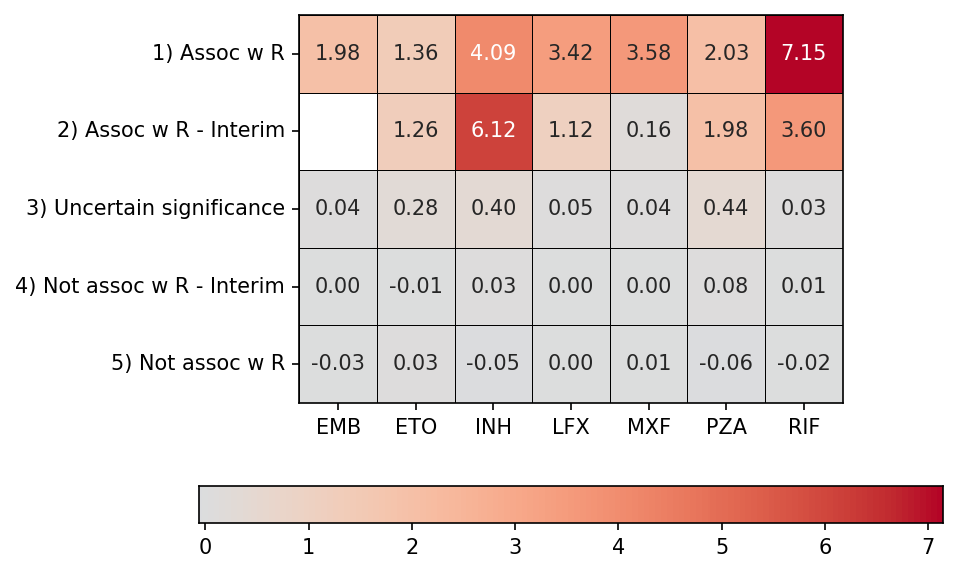

In [42]:
summary_catalog_groups_MICs = []

for drug in all_drugs_insilico_pred.drug.unique():

    df_single_drug = all_drugs_insilico_pred.query("drug==@drug & variant != 'MT_H37Rv'")
    df_summary = pd.DataFrame(df_single_drug.groupby('confidence')['log2_fold_change'].mean()).reset_index()
    df_summary['Drug'] = drug_abbr_dict[drug]
    summary_catalog_groups_MICs.append(df_summary)

summary_catalog_groups_MICs = pd.concat(summary_catalog_groups_MICs)
summary_catalog_groups_MICs = summary_catalog_groups_MICs.pivot(index='confidence', columns='Drug', values='log2_fold_change')
summary_catalog_groups_MICs.rename(columns={'ETH': 'ETO', 'LEV': 'LFX'}, inplace=True)

max_val = np.max(np.abs(summary_catalog_groups_MICs.fillna(0).values))

min_val = summary_catalog_groups_MICs.fillna(0).values.min()
max_val = summary_catalog_groups_MICs.fillna(0).values.max()

sns.heatmap(summary_catalog_groups_MICs,
            vmin=min_val,
            vmax=max_val,
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=0.3,
            linecolor='black',
            cbar=True,
            cmap='coolwarm',
            square=True,
            cbar_kws={"orientation": "horizontal"}
           )

plt.xlabel('')
plt.ylabel('')
sns.despine(top=False, right=False, left=False, bottom=False)
# plt.show()
plt.savefig("results/insilicio_mut_fold_change_summary.svg", bbox_inches='tight')

# Susceptibility-Associated Mutations

In [218]:
all_drugs_insilico_pred.query("pval <= 0.05 & fold_change <= 0.9 & effect != 'synonymous_variant'").effect.value_counts()

effect
missense_variant         59
upstream_gene_variant     7
stop_gained               2
inframe_deletion          2
start_lost                1
Name: count, dtype: int64

In [220]:
all_drugs_insilico_pred.query("pval <= 0.05 & fold_change <= 0.9 & effect not in ['synonymous_variant', 'missense_variant']")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,mean_permutation_log2FC,pval
284,ethA_p.Gln24*,-0.473783,0.720074,stop_gained,5.0,ethA,2) Assoc w R - Interim,1.002264,0.718448,-0.477045,ethA,Ethionamide,0.240596,0.0
887,ethR_p.Met1?,-1.492794,0.355324,start_lost,5.0,ethR,3) Uncertain significance,1.002264,0.354521,-1.496057,ethR,Ethionamide,0.108302,0.0
911,ethR_p.Trp145*,-1.274354,0.413410,stop_gained,5.0,ethR,3) Uncertain significance,1.002264,0.412476,-1.277616,ethR,Ethionamide,0.464930,0.0
924,inhA_c.-158C>T,-1.021148,0.492724,upstream_gene_variant,5.0,fabG1-inhA,3) Uncertain significance,1.002264,0.491611,-1.024410,inhA,Ethionamide,-0.000034,0.0
1003,inhA_c.-94C>T,-0.650962,0.636856,upstream_gene_variant,5.0,fabG1-inhA,3) Uncertain significance,1.002264,0.635417,-0.654224,inhA,Ethionamide,-0.000051,0.0
2204,gyrB_c.-93T>C,-2.325693,0.199479,upstream_gene_variant,1.0,gyrBA,3) Uncertain significance,0.252745,0.789248,-0.341449,gyrB,Levofloxacin,0.000425,0.0
2471,gyrB_p.Ala644del,-2.360082,0.194780,inframe_deletion,1.0,gyrBA,3) Uncertain significance,0.252745,0.770658,-0.375838,gyrB,Levofloxacin,0.009392,0.0
4918,rpsA_c.-31delG,4.102714,17.180660,upstream_gene_variant,100.0,rpsA,3) Uncertain significance,24.936594,0.688974,-0.537479,rpsA,Pyrazinamide,-0.004020,0.0
5115,rpsA_p.Met432_Ala438delinsThr,4.470363,22.167324,inframe_deletion,100.0,rpsA,3) Uncertain significance,24.936594,0.888948,-0.169830,rpsA,Pyrazinamide,-0.015019,0.0
5164,rpoB_c.-134T>G,-4.416125,0.046840,upstream_gene_variant,0.5,rpoBC,3) Uncertain significance,0.058939,0.794709,-0.331502,rpoB,Rifampicin,-0.000198,0.0


# Mutations that cause low-level resistance from the catalog. How are they predicted?

In [35]:
low_level_R_variants = who_variants.loc[(~pd.isnull(who_variants['Comment'])) & (who_variants['Comment'].str.contains('low'))][['drug', 'variant', 'Comment', 'Additional grading criteria applied']]

print(len(low_level_R_variants))

low_level_R_variants = all_drugs_insilico_pred.merge(low_level_R_variants, left_on=['drug', 'variant'], right_on=['drug', 'variant'], how='right')

print(len(low_level_R_variants))

21
21


In [36]:
who_variants.loc[(~pd.isnull(who_variants['Comment'])) & (who_variants['Comment'].str.contains('low'))][['drug', 'gene']].value_counts()

drug          gene
Isoniazid     inhA    8
Moxifloxacin  gyrB    8
              gyrA    5
Name: count, dtype: int64

In [37]:
low_level_R_variants.fold_change.min(), low_level_R_variants.fold_change.max()

(1.0321716055359822, 17.15429335404509)

In [38]:
low_level_R_variants[['drug', 'variant', 'effect', 'pred_MIC', 'ref_pred', 'CC', 'fold_change', 'Comment', 'Additional grading criteria applied']].to_csv("supplement/low_level_R_variants.csv", index=False)

# Individual Discrepancies / Interesting points to make

# ahpC Mutations (isoniazid)

In [145]:
# will pd.concat this at the end
mutations_of_interest = []

keep_cols = ['drug', 'variant', 'confidence', 'pred_MIC', 'ref_pred', 'fold_change', 'log2_fold_change']

# xpert range is -47 to -92. End is exclusive in np.arange
xpert_lst = np.arange(-92, -47+1).astype(str)

ahpC_resistant_mutations = all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant.str.contains('|'.join(@xpert_lst))").query("pred_MIC > 0.2").sort_values("pred_MIC", ascending=False)

ahpC_exp_evidence_R = ['-81C>T', '-54C>T', '-51G>A', '-48G>A', '-52C>T', '-72C>T']
ahpC_exp_evidence_R = [f"ahpC_c.{var}" for var in ahpC_exp_evidence_R]

ahpC_resistant_mutations = pd.concat([ahpC_resistant_mutations, all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant in @ahpC_exp_evidence_R").query("pred_MIC > 0.2").sort_values("pred_MIC", ascending=False)]).drop_duplicates()

ahpC_exp_evidence_notR = ['-84T>C', '-88G>A', '-10G>A']
ahpC_exp_evidence_notR = [f"ahpC_c.{var}" for var in ahpC_exp_evidence_notR]

# don't add these to mutations of interest dataframe. Add them to the not assoc w R dataframe below
ahpC_not_resistant_mutations = all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant in @ahpC_exp_evidence_notR").sort_values("pred_MIC", ascending=False)

mutations_of_interest.append(ahpC_resistant_mutations[keep_cols])

In [382]:
all_drugs_insilico_pred.query("variant in @ahpC_exp_evidence_R")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
6060,ahpC_c.-48G>A,-3.547162,0.085546,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,1.765221,0.819849,ahpC,Isoniazid
6061,ahpC_c.-51G>A,1.759575,3.385984,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,69.869249,6.126586,ahpC,Isoniazid
6064,ahpC_c.-52C>T,-2.873802,0.136427,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,2.815143,1.493208,ahpC,Isoniazid
6067,ahpC_c.-54C>T,0.567152,1.481596,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,30.572499,4.934163,ahpC,Isoniazid
6071,ahpC_c.-72C>T,-1.136151,0.454972,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,9.388273,3.230860,ahpC,Isoniazid
6090,ahpC_c.-81C>T,-0.292794,0.816319,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,16.844623,4.074216,ahpC,Isoniazid


In [383]:
all_drugs_insilico_pred.query("variant=='katG_p.Ser315Thr'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
7759,katG_p.Ser315Thr,2.044469,4.125213,missense_variant,0.2,katG-furA,1) Assoc w R,0.048462,85.123124,6.411479,katG,Isoniazid


In [379]:
len(all_drugs_insilico_pred.query("drug=='Isoniazid' & gene == 'ahpC' & variant.str.contains('|'.join(@xpert_lst))"))

44

In [380]:
len(ahpC_resistant_mutations)

14

In [147]:
# whoo, all predicted close to fold change of 1
ahpC_not_resistant_mutations

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
6094,ahpC_c.-84T>C,-4.361991,0.048631,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,1.003485,0.005019,ahpC,Isoniazid
6046,ahpC_c.-10G>A,-4.382883,0.047931,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.048462,0.989059,-0.015872,ahpC,Isoniazid
6097,ahpC_c.-88G>A,-4.389431,0.047714,upstream_gene_variant,0.2,ahpC,5) Not assoc w R,0.048462,0.984579,-0.022421,ahpC,Isoniazid


# mshA LoF Mutations (ethionamide)

In [367]:
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETO", "data_for_model.csv"))

mshA_mutations = all_drugs_insilico_pred.query("drug=='Ethionamide' & gene=='mshA'")
mshA_resistant_mutations = mshA_mutations.query("fold_change >= 1.5").sort_values("pred_MIC", ascending=False)

# mutations_of_interest.append(mshA_resistant_mutations[keep_cols])

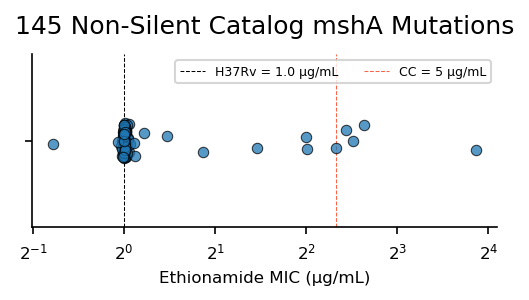

In [237]:
drug = 'ETO'

fig, ax = plt.subplots(figsize=(4, 1.5))

sns.stripplot(data=mshA_mutations.query("effect not in @silent_lst"),
              x='pred_MIC',
              log_scale=2,
              linewidth=0.5,
              edgecolor='black',
              # hue='confidence',
              alpha=0.75
             )

plt.xlabel('Ethionamide MIC (µg/mL)', fontsize=8)

plt.title(f"{len(mshA_mutations.query('effect not in @silent_lst'))} Non-Silent Catalog mshA Mutations")

ref_pred = all_drugs_insilico_pred.query("drug=='Ethionamide' & variant=='MT_H37Rv'")['pred_MIC'].values[0]

plt.xticks(fontsize=8)

plt.axvline(ref_pred, color='black', linestyle='--', linewidth=0.5, label=f"H37Rv = {np.round(ref_pred, 2)} µg/mL")
plt.axvline(cc_dict[drug], color='tomato', linestyle='--', linewidth=0.5, label=f"CC = {cc_dict[drug]} µg/mL")
plt.legend(fontsize=6, ncol=2)

sns.despine()
plt.savefig("results/Ethionamide/mshA_predictions_stripplot.svg", bbox_inches='tight')

In [371]:
mshA_mutations.effect.value_counts()

effect
missense_variant         129
synonymous_variant        85
stop_gained                9
upstream_gene_variant      6
inframe_deletion           1
Name: count, dtype: int64

In [373]:
mshA_mutations.query("fold_change > 2").sort_values("pred_MIC", ascending=False)

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
5975,mshA_p.Gly311*,3.865734,14.578129,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,14.545200,3.862471,mshA,Ethionamide
5965,mshA_p.Glu353*,2.636672,6.218953,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,6.204906,2.633409,mshA,Ethionamide
5961,mshA_p.Gln363*,2.514167,5.712676,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,5.699772,2.510904,mshA,Ethionamide
5963,mshA_p.Glu220*,2.438014,5.418952,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,5.406711,2.434751,mshA,Ethionamide
5959,mshA_p.Gln205*,2.323007,5.003741,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,4.992439,2.319745,mshA,Ethionamide
5958,mshA_p.Gln128*,2.013522,4.037667,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,4.028547,2.010260,mshA,Ethionamide
6033,mshA_p.Tyr123*,1.998733,3.996487,stop_gained,5.0,mshA,3) Uncertain significance,1.002264,3.987460,1.995470,mshA,Ethionamide
6036,mshA_p.Val224_Ser226del,1.462798,2.756424,inframe_deletion,5.0,mshA,3) Uncertain significance,1.002264,2.750198,1.459536,mshA,Ethionamide


In [378]:
isolate_variants.query("variant=='mshA_p.Val224_Ser226del'").merge(df_ETO).drop_duplicates(['ROLLINGDB_ID', 'variant'])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
0,SAMN06094080,576015,AAGTGATTTC,A,PASS,0.0,False,0.91,130.0,38.0,...,lam,NaN,4.3/LAM,0.005183,4,-7.591911,0,1.0,4-1,test_set


# rpoC mutations (rifampicin)

In [8]:
rpoC_mutations = all_drugs_insilico_pred.query("drug=='Rifampicin' & gene=='rpoC'")

print(f"Largest predicted MIC among the {len(rpoC_mutations)} rpoC mutations: {rpoC_mutations.pred_MIC.max()} for {rpoC_mutations.sort_values('pred_MIC').variant.values[-1]}")

Largest predicted MIC among the 1384 rpoC mutations: 0.16392262 for rpoC_p.Val709Phe


In [12]:
rpoC_mutations.query("variant=='rpoC_p.Val483Ala'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,mean_permutation_log2FC,pval
7988,rpoC_p.Val483Ala,-3.713458,0.076232,missense_variant,0.5,rpoBC,3) Uncertain significance,0.058939,1.293397,0.371165,rpoC,Rifampicin,0.007025,0.0


In [18]:
rpoC_mutations.query("variant=='rpoC_p.Leu516Pro'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,mean_permutation_log2FC,pval
7747,rpoC_p.Leu516Pro,-4.080351,0.059114,missense_variant,0.5,rpoBC,3) Uncertain significance,0.058939,1.002966,0.004272,rpoC,Rifampicin,-0.0032,0.0


# Not Assoc w R Mutations from the Literature Compiled for the 2023 Catalog

In [142]:
# 47 total, 41 for the drugs here
not_assoc_w_R_literature = pd.read_excel("~/who-analysis/data/NotAwR by literature.xlsx", sheet_name=None)['Sheet1']
print(len(not_assoc_w_R_literature))

47


In [143]:
not_assoc_w_R_pred = all_drugs_insilico_pred.copy()
not_assoc_w_R_pred['variant'] = not_assoc_w_R_pred.variant.str.replace('_p_', '_p.').str.replace('_c_', '_c.').str.replace('+', '*')

not_assoc_w_R_pred = not_assoc_w_R_pred.merge(not_assoc_w_R_literature, on=['drug', 'variant'])
print(len(not_assoc_w_R_pred))

22


In [148]:
# add the ahpC not assoc w R mutations here
not_assoc_w_R_pred = pd.concat([not_assoc_w_R_pred, ahpC_not_resistant_mutations]).drop_duplicates(["drug", "variant"])
print(f"Fold change range for {len(not_assoc_w_R_pred)} Not assoc w R by literature mutations: {not_assoc_w_R_pred.fold_change.min()}-{not_assoc_w_R_pred.fold_change.max()}")

Fold change range for 25 Not assoc w R by literature mutations: 0.6025737841976754-1.420650522955385


In [186]:
not_assoc_w_R_pred.sort_values("fold_change", ascending=False).head()

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
15,gyrA_p.Arg252Leu,-1.477692,0.359063,missense_variant,1.0,gyrBA,4) Not assoc w R - Interim,0.252745,1.420651,0.506552,gyrA,Levofloxacin
17,gyrA_p.Thr80Ala,-3.245332,0.105453,missense_variant,0.5,gyrBA,4) Not assoc w R - Interim,0.087492,1.205281,0.269370,gyrA,Moxifloxacin
19,rpsA_c.636A>C,4.688975,25.794200,synonymous_variant,100.0,rpsA,4) Not assoc w R - Interim,24.936594,1.034391,0.048782,rpsA,Pyrazinamide
14,gyrA_p.Ala90Gly,-1.958772,0.257247,missense_variant,1.0,gyrBA,4) Not assoc w R - Interim,0.252745,1.017813,0.025472,gyrA,Levofloxacin
18,clpC1_p.Val63Ala,4.661447,25.306684,missense_variant,100.0,clpC1,4) Not assoc w R - Interim,24.936594,1.014841,0.021254,clpC1,Pyrazinamide


In [149]:
not_assoc_w_R_pred.fold_change.mean()

1.003929273271209

In [187]:
not_assoc_w_R_pred[['drug', 'variant', 'effect', 'CC', 'ref_pred', 'pred_MIC', 'fold_change']].to_csv("supplement/not_assoc_R_muts.csv", index=False)

# Ethambutol: Known to have many low-level resistance mutations

In [261]:
EMB_promoter_variants = all_drugs_insilico_pred.query("drug=='Ethambutol' & effect=='upstream_gene_variant'").sort_values("pred_MIC", ascending=False)

# no R-associated variants in the catalog
EMB_promoter_variants.confidence.unique()

array(['3) Uncertain significance', '5) Not assoc w R',
       '4) Not assoc w R - Interim'], dtype=object)

In [262]:
who_variants.query("drug=='Ethambutol'").loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].effect.unique()

array(['missense_variant'], dtype=object)

In [263]:
who_variants.query("drug=='Ethambutol' & effect=='upstream_gene_variant'")['FINAL CONFIDENCE GRADING'].unique()

array(['3) Uncertain significance', '5) Not assoc w R',
       '4) Not assoc w R - Interim'], dtype=object)

In [264]:
who_variants.query("drug=='Ethambutol'").loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

array(['embB'], dtype=object)

In [265]:
mutations_of_interest.append(EMB_promoter_variants.query("fold_change > 2")[keep_cols])
print(EMB_promoter_variants.query("fold_change > 2").gene.value_counts())

gene
embA    15
embC     2
Name: count, dtype: int64


In [349]:
who_variants.query("variant in ['embC_c.-1503C>T', 'embC_c.-632G>A']")[['variant', 'Present_SOLO_S', 'Present_SOLO_R']]

,variant,Present_SOLO_S,Present_SOLO_R
12319,embC_c.-1503C>T,0.0,2.0
12888,embC_c.-632G>A,0.0,1.0


In [356]:
mutations_of_interest.append(EMB_promoter_variants.query("fold_change < 0.75")[keep_cols])

EMB_promoter_variants.query("fold_change < 0.75").sort_values("pred_MIC")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
2954,embC_c.-110C>T,-0.524520,0.695190,upstream_gene_variant,5.0,aftA-embCAB,3) Uncertain significance,1.248597,0.556777,-0.844828,embC,Ethambutol
2922,embC_c.-100C>T,-0.453411,0.730314,upstream_gene_variant,5.0,aftA-embCAB,5) Not assoc w R,1.248597,0.584907,-0.773720,embC,Ethambutol
2975,embC_c.-1188C>T,-0.410482,0.752372,upstream_gene_variant,5.0,aftA-embCAB,4) Not assoc w R - Interim,1.248597,0.602574,-0.730790,embC,Ethambutol
3186,embC_c.-1803G>C,-0.405089,0.755190,upstream_gene_variant,5.0,aftA-embCAB,5) Not assoc w R,1.248597,0.604830,-0.725397,embC,Ethambutol
3052,embC_c.-1425G>A,-0.305119,0.809375,upstream_gene_variant,5.0,aftA-embCAB,3) Uncertain significance,1.248597,0.648228,-0.625428,embC,Ethambutol
2977,embC_c.-1193C>T,-0.203454,0.868469,upstream_gene_variant,5.0,aftA-embCAB,5) Not assoc w R,1.248597,0.695556,-0.523762,embC,Ethambutol


In [355]:
who_variants.merge(EMB_promoter_variants.query("fold_change < 0.7").sort_values("pred_MIC")[['variant']])[['variant', 'Present_SOLO_R', 'Present_SOLO_S']]

,variant,Present_SOLO_R,Present_SOLO_S
0,embC_c.-100C>T,0.0,201.0
1,embC_c.-110C>T,0.0,10.0
2,embC_c.-1188C>T,56.0,1080.0
3,embC_c.-1193C>T,1.0,109.0
4,embC_c.-1425G>A,0.0,7.0
5,embC_c.-1803G>C,0.0,69.0


In [429]:
wtf_samples = []
low_QC = []

for name in redo_samples.ROLLINGDB_ID.values:

    if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/WHO_resistance/{name}_variants_combinedCodons.eff.vcf"):
        if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/WHO_resistance/{name}_variants_combinedCodons.vcf"):
            wtf_samples.append(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/WHO_resistance/{name}_variants_combinedCodons.vcf")
    else:
        low_QC.append(name)

In [430]:
len(wtf_samples)

56

In [431]:
pd.Series(wtf_samples).to_csv("/home/sak0914/fNames_to_annot.tsv", sep='\t', header=None, index=False)

In [432]:
for fName in wtf_samples:
    
    vcf_reader = vcf.Reader(filename=fName)

    for record in vcf_reader:
        if record.CHROM != 'Chromosome':
            print(fName)

In [ ]:
snpEff eff Mycobacterium_tuberculosis_h37rv -noStats -no-downstream -no-upstream -lof -fileList /home/sak0914/fNames_to_annot.tsv

In [417]:
wtf2_samples = []

for name in redo_samples.ROLLINGDB_ID.values:

    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon/{name}_variants.vcf"):
        if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/WHO_resistance/{name}_variants_combinedCodons.eff.vcf"):
            if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/WHO_resistance/{name}_variants_combinedCodons.vcf"):
                wtf2_samples.append(name)

len(wtf2_samples)

1

In [418]:
# len(wtf_samples), len(low_QC)

In [419]:
for sample in redo_samples.query("ROLLINGDB_ID in @wtf2_samples").ROLLINGDB_ID.values:
    # if not os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance"):
    #     os.mkdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance")
        
    print(f"python3 ~/Mtb_Megapipe/scripts/combine_codon_variants.py -i /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/pilon/{sample}_variants.vcf -o /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance/{sample}_variants_combinedCodons.vcf")

python3 ~/Mtb_Megapipe/scripts/combine_codon_variants.py -i /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMN02360607/pilon/SAMN02360607_variants.vcf -o /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMN02360607/WHO_resistance/SAMN02360607_variants_combinedCodons.vcf


In [269]:
EMB_susceptible_mutations = all_drugs_insilico_pred.query("drug=='Ethambutol' & fold_change < 0.8 & effect not in @silent_lst").sort_values("fold_change")

EMB_susceptible_mutations = EMB_susceptible_mutations.merge(who_variants, on=['drug', 'variant'])[keep_cols + ['Present_S', 'Present_R', 'Present_SOLO_S', 'Present_SOLO_R']]

In [270]:
all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC").drug.value_counts()

drug
Pyrazinamide    67
Ethambutol       6
Ethionamide      3
Rifampicin       2
Isoniazid        1
Levofloxacin     1
Moxifloxacin     1
Name: count, dtype: int64

In [271]:
len(all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC"))

81

# Group 1 Mutations that the Models Predicted Low MIC

In [272]:
def plot_predicted_MICs_strip(drug, save=False):

    missed_group1_variants = all_drugs_insilico_pred.query("confidence=='1) Assoc w R' & pred_MIC < CC & drug==@drug")

    if len(missed_group1_variants) == 0:
        return None
    
    ref_pred = missed_group1_variants.query("drug==@drug")['ref_pred'].values[0]
    drug_abbr = drug_abbr_dict[drug]
    cc = cc_dict[drug_abbr]

    if drug == 'Pyrazinamide':
        log_base = 10
        sig_fig = 1
    else:
        log_base = 2
        sig_fig = 2

    log_base = 2
    
    fig, ax = plt.subplots(figsize=(2, 3))
    
    sns.stripplot(data=missed_group1_variants.query("drug==@drug"),
                  x='drug',
                  y='pred_MIC',
                  log_scale=log_base,
                  jitter=True,
                  alpha=0.75,
                  linewidth=0.75,
                  edgecolor='black',
                  ax=ax
                 )

    plt.axhline(cc, label=f'CC = {cc}', color='tomato', linestyle='--', linewidth=1, zorder=0)
    plt.axhline(ref_pred, label=f'H37Rv = {np.round(ref_pred, sig_fig)}', color='black', linestyle='--', linewidth=1, zorder=0)
    plt.legend(fontsize=6)
    
    plt.xticks([])
    plt.yticks(fontsize=8)

    # Set the y-tick labels' font size
    # ax.tick_params(axis='y', labelsize=8)

    # Get the current y-tick labels
    y_ticks = plt.gca().get_yticklabels()
    
    # Set the font size for y-tick labels
    plt.setp(y_ticks, fontsize=8)

    plt.xlabel('')
    plt.title(drug, fontsize=8)
    plt.ylabel('Predicted MIC (µg/mL)', fontsize=8)
    
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(f"results/{drug}/Group1_missed.svg")
    else:
        # plt.close()
        plt.show()

    search_variants = missed_group1_variants['variant'].values

    df_phenos = pd.read_csv(os.path.join(data_dir, drug_abbr, "data_for_model.csv"))

    df_phenos_with_variants = isolate_variants.query("variant in @search_variants").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_phenos.query("category=='train_set'")[['ROLLINGDB_ID', f'{drug_abbr}_lower_bound', f'{drug_abbr}_upper_bound']])

    return pd.DataFrame(df_phenos_with_variants.groupby(['variant'])[['ROLLINGDB_ID']].nunique()).reset_index().merge(missed_group1_variants, on='variant', how='right')

81 missed Group 1 variants
24 variants are present in the training dataset


drug
Pyrazinamide    11
Ethambutol       6
Ethionamide      2
Rifampicin       2
Isoniazid        1
Levofloxacin     1
Moxifloxacin     1
Name: count, dtype: int64

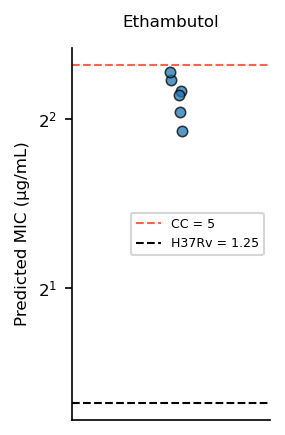

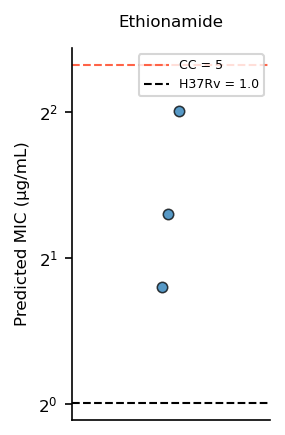

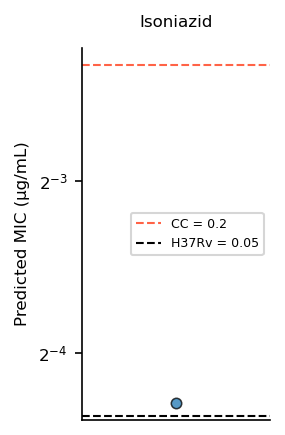

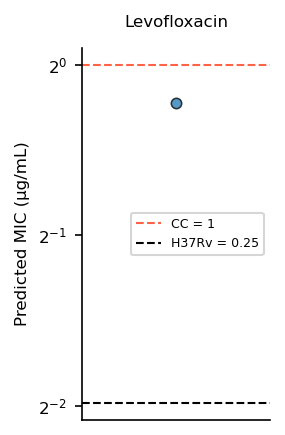

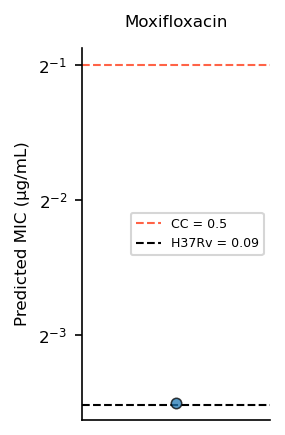

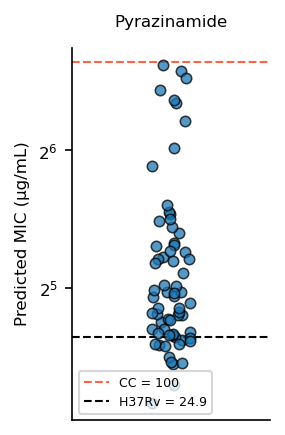

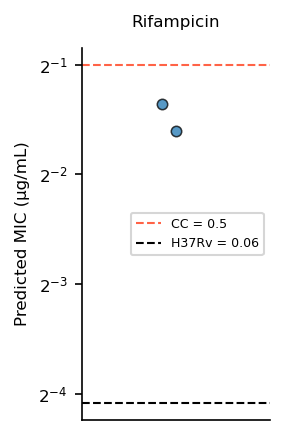

In [277]:
missing_group1_annotated = []

for drug in all_drugs_insilico_pred.drug.unique():
    missing_group1_annotated.append(plot_predicted_MICs_strip(drug, save=True))

missing_group1_annotated = pd.concat(missing_group1_annotated)
print(f"{len(missing_group1_annotated)} missed Group 1 variants")
print(f"{len(missing_group1_annotated.dropna(subset='ROLLINGDB_ID'))} variants are present in the training dataset")
missing_group1_annotated.dropna(subset='ROLLINGDB_ID')['drug'].value_counts()

In [293]:
sum(pd.isnull(missing_group1_annotated['ROLLINGDB_ID'])) / len(missing_group1_annotated)

0.7037037037037037

In [289]:
missing_group1_annotated['drug'].value_counts()

drug
Pyrazinamide    67
Ethambutol       6
Ethionamide      3
Rifampicin       2
Isoniazid        1
Levofloxacin     1
Moxifloxacin     1
Name: count, dtype: int64

In [294]:
missing_group1_annotated.query("drug=='Moxifloxacin'")

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,gyrB_p.Glu501Asp,29.0,-3.500851,0.088336,missense_variant,0.5,gyrBA,1) Assoc w R,0.087492,1.009647,0.013851,gyrB,Moxifloxacin


In [308]:
df_MXF = pd.read_csv(f"{data_dir}/MXF/data_for_model.csv")
gyrB_Glu501Asp_isolates = isolate_variants.query("variant=='gyrB_p.Glu501Asp' & drug=='Moxifloxacin'").merge(df_MXF)
len(gyrB_Glu501Asp_isolates)

39

In [309]:
len(gyrB_Glu501Asp_isolates.query("category=='train_set'")), len(gyrB_Glu501Asp_isolates.query("category=='train_set' & AF > 0.25 & AF <= 0.75"))

(29, 9)

In [319]:
search_isolates = gyrB_Glu501Asp_isolates.query("category=='train_set'").ROLLINGDB_ID.values
len(search_isolates)

29

In [321]:
isolate_variants.query("ROLLINGDB_ID in @search_isolates & variant != 'gyrB_p.Glu501Asp' & drug=='Moxifloxacin' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.nunique()

12

In [318]:
who_variants.query("variant=='gyrB_p.Glu501Asp'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
30113,Levofloxacin,gyrB,p.Glu501Asp,gyrB_p.Glu501Asp,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,44.0,13.0,...,FQ cross-resistance,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,FQ X-R,NaN,1
33930,Moxifloxacin,gyrB,p.Glu501Asp,gyrB_p.Glu501Asp,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,43.0,34.0,...,NaN,1) Assoc w R,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,NaN,F,1


In [295]:
missing_group1_annotated.query("drug=='Levofloxacin'")

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,gyrB_p.Asn499Thr,7.0,-0.226074,0.854958,missense_variant,1.0,gyrBA,1) Assoc w R,0.252745,3.382687,1.75817,gyrB,Levofloxacin


In [296]:
missing_group1_annotated.query("drug=='Rifampicin'")

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,rpoB_p.His445Asn,22.0,-1.602862,0.329223,missense_variant,0.5,rpoBC,1) Assoc w R,0.058939,5.585790,2.481761,rpoB,Rifampicin
1,rpoB_p.Leu430Pro,88.0,-1.354685,0.391020,missense_variant,0.5,rpoBC,1) Assoc w R,0.058939,6.634274,2.729939,rpoB,Rifampicin


In [281]:
who_variants.query("variant in ['rpoB_p.His445Asn', 'rpoB_p.Leu430Pro'] & drug=='Rifampicin'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
41261,Rifampicin,rpoB,p.His445Asn,rpoB_p.His445Asn,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,104.0,35.0,...,Borderline,1) Assoc w R,NaN,No change,NaN,NaN,yes,Borderline,NaN,1
41336,Rifampicin,rpoB,p.Leu430Pro,rpoB_p.Leu430Pro,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,208.0,53.0,...,Borderline,1) Assoc w R,NaN,No change,NaN,NaN,yes,Borderline,NaN,1


In [297]:
missing_group1_annotated.query("drug=='Ethionamide'")

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,ethA_p.Arg207Gly,NaN,0.797577,1.738179,missense_variant,5.0,ethA,1) Assoc w R,1.002264,1.734253,0.794315,ethA,Ethionamide
1,ethA_p.Met1?,94.0,1.298436,2.459621,start_lost,5.0,ethA,1) Assoc w R,1.002264,2.454065,1.295174,ethA,Ethionamide
2,inhA_c.-777C>T,795.0,2.006424,4.017851,upstream_gene_variant,5.0,fabG1-inhA,1) Assoc w R,1.002264,4.008776,2.003162,inhA,Ethionamide


In [298]:
missing_group1_annotated.query("drug=='Ethambutol'")

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,embB_p.Asp328Tyr,19.0,2.229651,4.690206,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.248597,3.756380,1.909343,embB,Ethambutol
1,embB_p.Asp354Ala,66.0,1.930265,3.811252,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.248597,3.052427,1.609957,embB,Ethambutol
2,embB_p.Gln497Lys,44.0,2.043801,4.123304,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.248597,3.302349,1.723493,embB,Ethambutol
3,embB_p.Gly406Ala,120.0,2.277775,4.849296,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.248597,3.883795,1.957467,embB,Ethambutol
4,embB_p.Met306Ile,825.0,2.169008,4.497139,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.248597,3.601753,1.848699,embB,Ethambutol
5,embB_p.Tyr319Cys,12.0,2.142651,4.415726,missense_variant,5.0,aftA-embCAB,1) Assoc w R,1.248597,3.536549,1.822342,embB,Ethambutol


In [284]:
who_variants.query("variant in ['gyrA_p.Ala90Val', 'gyrA_p.Asp94Ala'] & drug=='Moxifloxacin'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
33236,Moxifloxacin,gyrA,p.Ala90Val,gyrA_p.Ala90Val,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,946.0,536.0,...,NaN,1) Assoc w R,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,NaN,F,1
33331,Moxifloxacin,gyrA,p.Asp94Ala,gyrA_p.Asp94Ala,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,320.0,168.0,...,NaN,1) Assoc w R,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,NaN,F,1


In [322]:
missing_group1_annotated.query("drug=='Isoniazid'")

,variant,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
0,katG_p.Trp328Leu,1.0,-4.290394,0.051105,missense_variant,0.2,katG-furA,1) Assoc w R,0.048462,1.054542,0.076616,katG,Isoniazid


In [324]:
who_variants.query("variant=='katG_p.Trp328Leu'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
22582,Isoniazid,katG,p.Trp328Leu,katG_p.Trp328Leu,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,12.0,12.0,...,NaN,1) Assoc w R,High-level resistance,No change,NaN,NaN,yes,NaN,G,1


In [329]:
df_INH = pd.read_csv(f"{data_dir}/INH/data_for_model.csv")

isolate_variants.query("variant=='katG_p.Trp328Leu'").merge(df_INH[['ROLLINGDB_ID', 'category', 'INH_lower_bound', 'Lineage']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,category,INH_lower_bound,Lineage
0,SAMEA7561296,2155129,C,A,PASS,1935.0,False,1.0,54.0,36.0,...,missense_variant,katG,c.983G>T,p.Trp328Leu,katG_p.Trp328Leu,Isoniazid,1) Assoc w R,train_set,1.6,4


# Save Mutations of Interest with Catalog SOLO Counts to a Table

In [287]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [262]:
isolate_variants.query("variant in ['pncA_c.309C>T', 'pncA_c.3G>A']").merge(df_PZA_phenos[['ROLLINGDB_ID', 'PZA_lower_bound', 'PZA_upper_bound', 'Coll2014', 'category']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,PZA_lower_bound,PZA_upper_bound,Coll2014,category
0,2289239,C,T,PASS,3040.0,False,0.97,93.0,38.0,60.0,...,c.3G>A,p.Met1?,pncA_c.3G>A,Pyrazinamide,4) Not assoc w R - Interim,SAMN05916261,500.0,inf,2.2.1,train_set


In [263]:
who_variants.query("variant.str.contains('103') & effect=='missense_variant' & gene=='pncA'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,compatible_variant
36199,Pyrazinamide,pncA,p.Tyr103Asp,pncA_p.Tyr103Asp,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,3.0,2.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Tyr103Asp
36200,Pyrazinamide,pncA,p.Tyr103Cys,pncA_p.Tyr103Cys,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,13.0,9.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Tyr103Cys
36202,Pyrazinamide,pncA,p.Tyr103His,pncA_p.Tyr103His,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,7.0,7.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,pncA_p_Tyr103His
36203,Pyrazinamide,pncA,p.Tyr103Ser,pncA_p.Tyr103Ser,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,1.0,1.0,...,3) Uncertain significance,NaN,DOWN from AwRI to Uncertain,NaN,NaN,yes,NaN,NaN,2,pncA_p_Tyr103Ser


In [267]:
df_mutations_of_interest = pd.concat(mutations_of_interest)
df_mutations_of_interest['variant'] = df_mutations_of_interest.variant.str.replace('_p_', '_p.').str.replace('_c_', '_c.').str.replace('+', '*')

df_mutations_of_interest = df_mutations_of_interest.merge(who_variants, on=['drug', 'variant'])[keep_cols] # + ['Present_S', 'Present_R', 'Present_SOLO_S', 'Present_SOLO_R']]#.sort_values(['drug', "fold_change"], ascending=[True, False])

In [270]:
df_mutations_of_interest.to_csv("results/tables/insilico_muts_of_interest.csv", index=False)

# Counts of Group 3 Mutations with Fold Changes > 2 or < 0.8

Don't interpret them too much. Just give counts.

In [179]:
Group_3_interesting_variants = all_drugs_insilico_pred.query("confidence=='3) Uncertain significance' & (fold_change > 2 | fold_change < 0.8)")

print(len(Group_3_interesting_variants))

336


In [183]:
Group_3_interesting_variants[['drug', 'gene']].value_counts()

drug          gene  
Isoniazid     katG      62
Pyrazinamide  pncA      57
Ethionamide   ethA      45
Ethambutol    embB      28
Bedaquiline   mmpL5     21
Ethambutol    embA      19
Moxifloxacin  gyrB      17
              gyrA      10
Levofloxacin  gyrA      10
Isoniazid     ahpC       9
Rifampicin    rpoB       9
Ethionamide   inhA       9
Bedaquiline   Rv0678     6
Isoniazid     inhA       6
Ethionamide   mshA       6
Levofloxacin  gyrB       5
Ethionamide   ethR       4
Pyrazinamide  rpsA       4
Ethambutol    ubiA       3
Bedaquiline   mmpS5      3
Pyrazinamide  clpC1      1
Ethambutol    embC       1
Rifampicin    rpoC       1
Name: count, dtype: int64

In [198]:
Group_3_interesting_variants.query("gene=='Rv0678'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
40,Rv0678_p_Arg134Gly,-4.036100,0.060955,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,2.026251,0.706187,Rv0678,Bedaquiline
70,Rv0678_p_Asp47dup,-2.805725,0.143019,inframe_insertion,0.25,Rv0678,3) Uncertain significance,0.030083,4.754151,1.559018,Rv0678,Bedaquiline
78,Rv0678_p_Cys46_Asp47insGly,-2.729206,0.150809,inframe_insertion,0.25,Rv0678,3) Uncertain significance,0.030083,5.013112,1.612057,Rv0678,Bedaquiline
135,Rv0678_p_Leu40Val,-6.423699,0.011649,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,0.387217,-0.948771,Rv0678,Bedaquiline
175,Rv0678_p_Ser68Gly,-2.414087,0.187624,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,6.236884,1.830481,Rv0678,Bedaquiline
176,Rv0678_p_Ser68Ile,-3.998801,0.062552,missense_variant,0.25,Rv0678,3) Uncertain significance,0.030083,2.079319,0.732041,Rv0678,Bedaquiline


In [201]:
who_variants.query("variant=='Rv0678_p.Ser68Gly'")[['drug', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

,drug,Present_SOLO_R,Present_SOLO_S,Present_R,Present_S
3360,Bedaquiline,0.0,1.0,0.0,1.0
7807,Clofazimine,0.0,1.0,0.0,1.0


In [202]:
all_drugs_insilico_pred.query("variant=='gyrA_p_Asp94Gly'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
557,gyrA_p_Asp94Gly,1.755495,3.376422,missense_variant,1.0,gyrBA,1) Assoc w R,0.250035,13.503820,2.602973,gyrA,Levofloxacin
505,gyrA_p_Asp94Gly,-0.587967,0.665280,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,13.129125,2.574833,gyrA,Moxifloxacin


In [297]:
all_drugs_insilico_pred.query("drug=='Bedaquiline' & confidence=='5) Not assoc w R'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
373,mmpL5_p_Asp767Asn,-6.015654,0.015456,missense_variant,0.25,mmpLS5,5) Not assoc w R,0.030083,0.513793,-0.960742,mmpL5,Bedaquiline


In [302]:
who_variants.query("variant in ['mmpL5_p.Asp767Asn', 'mmpS5_c.-74G>T'] & drug=='Bedaquiline'")[['variant', 'Present_S', 'Present_R']]

,variant,Present_S,Present_R
2524,mmpL5_p.Asp767Asn,3915.0,185.0
2753,mmpS5_c.-74G>T,93.0,37.0


In [304]:
isolate_variants.query("variant=='mmpL5_p.Asp767Asn'").drop_duplicates(['ROLLINGDB_ID', 'variant'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
169,776182,C,T,PASS,3184.0,False,1.00,96.0,33.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,30571
221,776182,C,T,PASS,823.0,False,0.96,26.0,38.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,23886
291,776182,C,T,PASS,1361.0,False,1.00,38.0,36.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,22755
422,776182,C,T,PASS,2358.0,False,1.00,67.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,25496
504,776182,C,T,PASS,4910.0,False,1.00,136.0,37.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,29598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716667,776182,C,T,PASS,8497.0,False,1.00,243.0,35.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,SAMEA5282543
716869,776182,C,T,PASS,1537.0,False,1.00,43.0,36.0,57.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,SAMEA5282549
717032,776182,C,T,PASS,3874.0,False,0.90,178.0,36.0,59.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,SAMEA5282422
717344,776182,C,T,PASS,7527.0,False,1.00,202.0,37.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R,HN878


# Relationship between Length Change and Predicted MIC

In [5]:
# def make_heatmap_deletion_predictions(drug, locus, gene):

#     # coding changes only, exclude nonsense mutations
#     df_coding_mutations = all_drugs_insilico_pred.query("gene==@gene & variant.str.contains('_p_') & ~variant.str.contains('*')").reset_index(drop=True)
    
#     df_coding_mutations['end_codon'] = df_coding_mutations['variant'].apply(get_variant_number, args=('-', False))
#     df_coding_mutations['start_codon'] = df_coding_mutations['variant'].apply(get_variant_number, args=('-', True))
#     df_coding_mutations['start_codon'] = df_coding_mutations['start_codon'].str[0].fillna(df_coding_mutations['start_codon']).astype(int)
    
#     # to get protein length differences
#     df_protein_seqs = pd.read_csv(os.path.join(results_dir, drug, "inSilico_analysis", locus, "df_protein_seqs.csv")).rename(columns={'ROLLINGDB_ID': 'variant'})
#     df_protein_seqs = df_protein_seqs.set_index('variant')

#     ref_protein_length = len(df_protein_seqs.loc['MT_H37Rv', f'{gene}_AA'].replace('-', ''))

#     assert df_coding_mutations.end_codon.max() <= ref_protein_length
    
#     # get lengths of the mutations
#     lengths_df = pd.DataFrame(df_protein_seqs.loc[df_coding_mutations['variant']][f'{gene}_AA'].str.replace('-', '').str.len()).reset_index().rename(columns={f'{gene}_AA': 'protein_length'})
#     df_coding_mutations = df_coding_mutations.merge(lengths_df, on='variant')

#     df_coding_mutations['length_reduction'] = ref_protein_length - df_coding_mutations['protein_length']

#     assert len(df_coding_mutations.query("length_reduction != 0 & effect == 'missense_variant'")) == 0
#     assert len(df_coding_mutations.query("length_reduction == 0 & effect != 'missense_variant'")) == 0
    
#     return df_coding_mutations.query("effect != 'missense_variant'")

In [6]:
# drug = 'PZA'
# locus = 'pncA'
# gene = 'pncA'

# df_coding_mutations = make_heatmap_deletion_predictions(drug, locus, gene)
# df_coding_mutations.fold_change.min()

In [3]:
# fig, ax = plt.subplots()

# scatter = sns.scatterplot(data=df_coding_mutations,
#                         x='start_codon',
#                         y='length_reduction',
#                         hue='log_fold_change',
#                           palette='Reds',
#                           ax=ax,
#                           legend=False
#                        )

# plt.yscale('log')

# # Get the minimum and maximum values of log_fold_change
# # smallest log fold change for resistance-increasing is 0
# min_val = 0 # df_coding_mutations['log_fold_change'].min()
# max_val = df_coding_mutations['log_fold_change'].max()

# # Normalize the color map to the data range
# norm = mcolors.Normalize(vmin=min_val, vmax=max_val)
# sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

# cbar = plt.colorbar(sm, ax=ax, orientation='vertical')
# cbar.set_label('Log Fold Change')

# # Optional: Remove the black outline around the color bar
# cbar.outline.set_visible(False)

# # # add text annotations with the mutation names
# # cc = cc_dict[drug]
# # for i, row in df_coding_mutations.query("pred_MIC > @cc").iterrows():
# #     ax.text(row['start_codon'] + 1, row['length_reduction']*1.05, s=row['mutation'].replace('_p_', '').replace(gene, ''), fontsize=5)

# sns.despine()
# plt.show()

# 2: Compare in silico WHO catalog predictions between Models +/- AA Features for pncA only

In [7]:
def get_who_catalog_variants_compare(model_path_1, locus, model_path_2=None, model_name_1='- AA', model_name_2='+ AA'):

    insilico_pred_1 = pd.read_csv(os.path.join(results_dir, model_path_1, "inSilico_analysis", locus, "test_predictions.csv"))

    if model_path_2 is not None:
        
        insilico_pred_2 = pd.read_csv(os.path.join(results_dir, model_path_2, "inSilico_analysis", locus, "test_predictions.csv"))

        combined_insilico_predictions = insilico_pred_1[['ROLLINGDB_ID', 'pred_MIC']].rename(columns={'pred_MIC': model_name_1}).merge(insilico_pred_2[['ROLLINGDB_ID', 'pred_MIC']].rename(columns={'pred_MIC': model_name_2}), on='ROLLINGDB_ID').rename(columns={'ROLLINGDB_ID': 'mutation'})

        # keep only those in V1 or V2 or nonsense mutations
        return combined_insilico_predictions.query("mutation in @who_variants.variant | mutation == 'MT_H37Rv'")

    else:
        return insilico_pred_1.rename(columns={'ROLLINGDB_ID': 'mutation', 'pred_MIC': model_name_1}).query("mutation in @who_variants.variant | mutation == 'MT_H37Rv'")
        
    
    
def compare_missense_nonsense_predictions_two_models(model_path_1, locus, model_path_2=None, log_base=10, model_name_1='- AA', model_name_2='+ AA', saveName=None):

    drug = model_path_1.split('_')[0]
    cc = cc_dict[drug]
    full_drug_name = abbr_drug_dict[drug]
    
    combined_insilico_predictions = get_who_catalog_variants_compare(model_path_1, locus, model_path_2, model_name_1, model_name_2)

    # get only nonsense and missense mutations (so exclude upstream promoter variants and indels)
    missense_nonsense_muts = combined_insilico_predictions.query("~mutation.str.contains('_c.') & ~mutation.str.contains('|'.join(['del', 'ins', 'ext']))")

    missense_nonsense_muts['codon'] = missense_nonsense_muts['mutation'].apply(get_variant_number, args=('+'))
    missense_nonsense_muts.loc[missense_nonsense_muts['mutation'].str.contains('\*'), 'type'] = 'nonsense'
    missense_nonsense_muts.loc[~missense_nonsense_muts['mutation'].str.contains('\*'), 'type'] = 'missense'
    missense_nonsense_muts['codon'] = missense_nonsense_muts['codon'].astype(int)

    # keep only cases where there is at least one missense and one nonsense on the codon
    missense_nonsense_codons = pd.DataFrame(missense_nonsense_muts.groupby('codon', dropna=True)['type'].nunique()).query("type > 1").index.values
    missense_nonsense_muts = missense_nonsense_muts.query("codon in @missense_nonsense_codons & mutation != 'MT_H37Rv'")

    # add WHO confidences 
    who_confidences = who_variants.query("drug==@full_drug_name & gene==@gene")[['variant', 'FINAL CONFIDENCE GRADING']].rename(columns={'variant': 'mutation'})
    
    # add confidence gradings for the shape
    missense_nonsense_muts = missense_nonsense_muts.merge(who_confidences[['mutation', 'FINAL CONFIDENCE GRADING']], on='mutation',how='left')
    
    assert sum(pd.isnull(missense_nonsense_muts['FINAL CONFIDENCE GRADING'])) == 0
    missense_nonsense_muts['R_assoc'] = (missense_nonsense_muts['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')).astype(int)

    if model_path_2 is None:
        
        fig, ax = plt.subplots(1, 1, figsize=(9, 3))

        sns.stripplot(data=missense_nonsense_muts,
                      x='codon',
                      y=model_name_1,
                      hue='type',
                      hue_order=['missense', 'nonsense'],
                      dodge=True,
                      jitter=True,
                      s=6.5,
                      log_scale=10,
                      edgecolor='black',
                      linewidth=0.75,
                      palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                      alpha=0.75,
                      ax=ax
                     )

        ax.set_xlabel(f"{locus} Codon", fontsize=9)
        ax.set_ylabel("Predicted MIC (µg/mL)", fontsize=9)
        ax.set_title(f"Predicted MICs of Nonsense and Missense Mutations, {model_name_1}", fontsize=9)
        
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

        ax.set_yscale('log', base=log_base)
        ax.legend(ncol=1, fontsize=8)

    else:
        fig, axs = plt.subplots(2, 1, figsize=(9, 6))
        models_lst = [model_name_1, model_name_2]

        sns.stripplot(data=missense_nonsense_muts,
                      x='codon',
                      y=model_name_1,
                      hue='type',
                      hue_order=['missense', 'nonsense'],
                      dodge=True,
                      jitter=True,
                      s=6.5,
                      log_scale=10,
                      edgecolor='black',
                      linewidth=0.75,
                      palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                      alpha=0.75,
                      ax=axs[0]
                     )
    
        sns.stripplot(data=missense_nonsense_muts,
                      x='codon',
                      y=model_name_2,
                      hue='type',
                      hue_order=['missense', 'nonsense'],
                      dodge=True,
                      jitter=True,
                      s=6.5,
                      log_scale=10,
                      edgecolor='black',
                      linewidth=0.75,
                      palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                      alpha=0.75,
                      ax=axs[1]
                 )

        for i, ax in enumerate(axs):
            ax.set_xlabel(f"{locus} Codon", fontsize=9)
            ax.set_ylabel("Predicted MIC (µg/mL)", fontsize=9)
            ax.set_title(f"Predicted MICs of Nonsense and Missense Mutations, {models_lst[i]}", fontsize=9)
            
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    
            ax.set_yscale('log', base=log_base)
            ax.legend(ncol=1, fontsize=8)

    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    sns.despine()

    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
            
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return missense_nonsense_muts

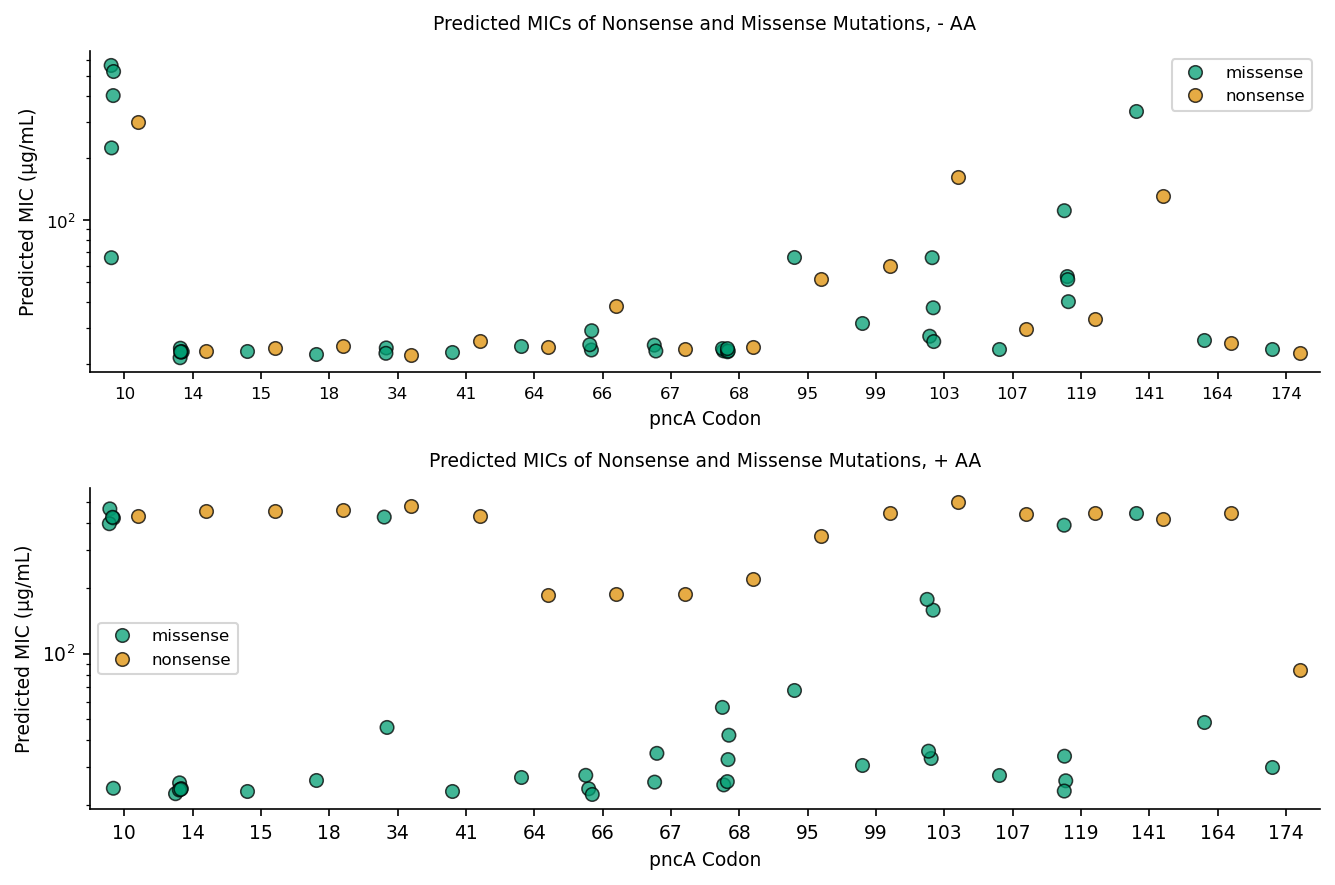

In [8]:
model_path_1 = "PZA_lineage"
model_path_2 = 'PZA_lineage_amino_acid'
locus = 'pncA'
gene = 'pncA'

missense_nonsense_muts_pncA = compare_missense_nonsense_predictions_two_models(model_path_1, locus, model_path_2=model_path_2, log_base=10, model_name_1='- AA', model_name_2='+ AA', saveName=f"results/{abbr_drug_dict[model_path_1.split('_')[0]]}/nonsense_missense_lineage_comparison.svg")

missense_nonsense_muts_pncA_codon_averaged = missense_nonsense_muts_pncA.groupby(['codon', 'type'])[['- AA', '+ AA']].mean().reset_index()

In [396]:
missense_nonsense_muts_pncA_codon_averaged.query("type=='missense'")

,codon,type,- AA,+ AA
0,10,missense,355.288254,347.346850
2,14,missense,22.779946,23.758704
4,15,missense,23.222490,23.294367
6,18,missense,22.416569,26.015192
8,34,missense,23.210794,236.443058
10,41,missense,22.936853,23.211103
12,64,missense,24.512384,26.978868
14,66,missense,25.712858,24.526068
16,67,missense,23.886319,30.080734
18,68,missense,23.327606,36.268696


In [405]:
# st.wilcoxon is the Wilcoxon signed-rank test (nonparametric matched-pairs)
st.ttest_rel(missense_nonsense_muts_pncA_codon_averaged.query("type=='missense'").sort_values("codon")['+ AA'],
             missense_nonsense_muts_pncA_codon_averaged.query("type=='nonsense'").sort_values("codon")['+ AA'],
             alternative='less',
            )

TtestResult(statistic=-7.693347435247667, pvalue=3.094362889623449e-07, df=17)

In [406]:
# st.wilcoxon is the Wilcoxon signed-rank test (nonparametric matched-pairs)
st.ttest_rel(missense_nonsense_muts_pncA_codon_averaged.query("type=='missense'").sort_values("codon")['- AA'],
             missense_nonsense_muts_pncA_codon_averaged.query("type=='nonsense'").sort_values("codon")['- AA'],
             alternative='less',
            )

TtestResult(statistic=0.5321337206393336, pvalue=0.6992402626996248, df=17)

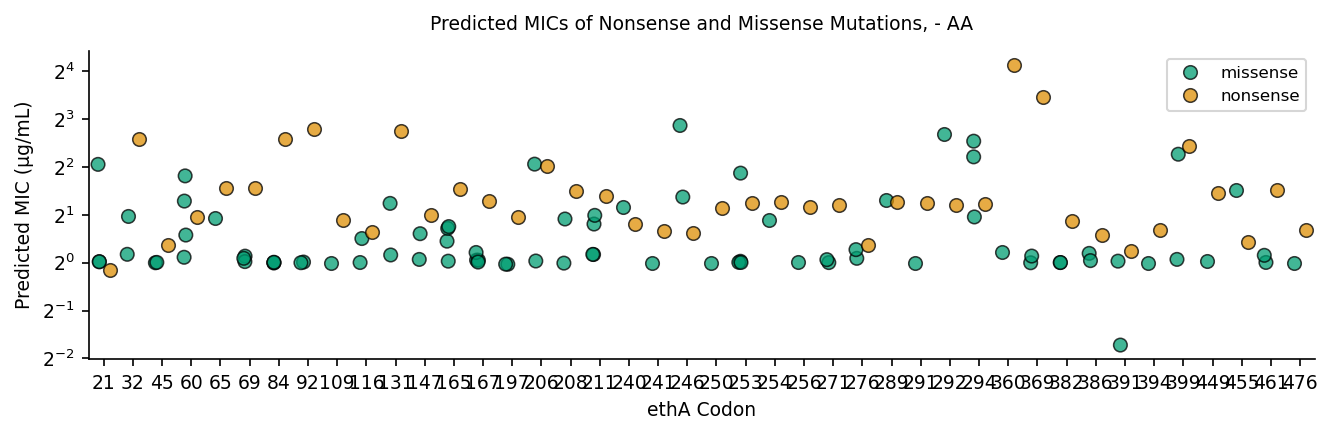

In [11]:
model_path_1 = "ETO_lineage_amino_acid"
locus = 'ethA'
gene = 'ethA'

missense_nonsense_muts_ethA = compare_missense_nonsense_predictions_two_models(model_path_1, locus, model_path_2=None, log_base=2)#, saveName=f"results/{abbr_drug_dict[model_path_1.split('_')[0]]}/nonsense_missense_lineage_AA.svg")

In [48]:
pred_col = 'log2_pred_MIC'

missense_nonsense_muts_ethA_unmelt = missense_nonsense_muts_ethA.groupby(['codon', 'type'])[[pred_col]].mean().reset_index()
missense_nonsense_muts_ethA_unmelt = missense_nonsense_muts_ethA_unmelt.pivot(index='codon', columns='type', values=pred_col)

In [411]:
st.ttest_rel(missense_nonsense_muts_ethA_unmelt['missense'], 
             missense_nonsense_muts_ethA_unmelt['nonsense'],
             alternative='less'
            )

TtestResult(statistic=-4.929801154636057, pvalue=7.027058378030668e-06, df=41)

In [49]:
st.spearmanr(missense_nonsense_muts_ethA_unmelt['missense'],
             missense_nonsense_muts_ethA_unmelt['nonsense']
            )

SignificanceResult(statistic=0.1692731545255652, pvalue=0.28387004810311)

In [66]:
# restrict to comparing mutations that are actually in the training set
df_ETO = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv")
ETO_training_isolates = df_ETO.query("category=='train_set'").ROLLINGDB_ID.unique()

variants_in_training_set = isolate_variants.query("ROLLINGDB_ID in @ETO_training_isolates").variant.unique()
missense_nonsense_muts_ethA_training_set = missense_nonsense_muts_ethA.query("mutation in @variants_in_training_set")

missense_nonsense_muts_ethA_training_set_unmelt = missense_nonsense_muts_ethA_training_set.groupby(['codon', 'type'])[[pred_col]].mean().reset_index()
missense_nonsense_muts_ethA_training_set_unmelt = missense_nonsense_muts_ethA_training_set_unmelt.pivot(index='codon', columns='type', values=pred_col)

In [69]:
# no, same thing
st.spearmanr(missense_nonsense_muts_ethA_training_set_unmelt.dropna()['missense'],
             missense_nonsense_muts_ethA_training_set_unmelt.dropna()['nonsense']
            )

SignificanceResult(statistic=0.07368421052631578, pvalue=0.7643412715216654)

In [14]:
def which_nonsense_muts_present_in_training_data(df_phenos, df_nonsense, gene, drug):
    '''
    Get a boolean variable for whether each variant is present in the training dataset
    '''

    cc = cc_dict[drug]
    
    df_nonsense.rename(columns={'ROLLINGDB_ID': 'variant'}, inplace=True)

    if '-' in gene:
        gene = gene.split('-')[0]

    train_isolates_with_nonsense_muts_with_MICs = isolate_variants.query("GENE==@gene & EFFECT=='stop_gained' & variant != 'stop_gained'").merge(df_phenos[['ROLLINGDB_ID', f'{drug}_lower_bound', f'{drug}_midpoint', f'{drug}_upper_bound', 'category']], on='ROLLINGDB_ID').query("category=='train_set'")
    
    print(f"{train_isolates_with_nonsense_muts_with_MICs.ROLLINGDB_ID.nunique()} training isolates have early stop codons in {gene}")
    
    df_nonsense['train_nonsense'] = df_nonsense['variant'].isin(train_isolates_with_nonsense_muts_with_MICs.variant.values).astype(int)

    # add the average measured MIC for training set isolates with each nonsense mutation
    df_nonsense = df_nonsense.merge(pd.DataFrame(train_isolates_with_nonsense_muts_with_MICs.groupby('variant')[f'{drug}_midpoint'].mean()).reset_index(), how='left')

    # add a boolean variable to change the shape of the point using the average MIC midpoint
    df_nonsense['Train_phenotype'] = (df_nonsense[f"{drug}_midpoint"] >= cc).astype(int).map({0: 'Susceptible', 1: 'Resistant'})
        
    return df_nonsense
    
    

# def which_missense_muts_present_in_training_data(df_phenos, df_nonsense, gene):
#     '''
#     Get a boolean variable for whether each variant is present in the training dataset
#     '''

#     df_nonsense.rename(columns={'ROLLINGDB_ID': 'variant'}, inplace=True)
#     df_train = df_phenos.query("category=='train_set'")

#     if '-' in gene:
#         gene = gene.split('-')[0]

#     sense = h37Rv_full.query("Name==@gene")['Strand'].values[0]

#     nonsyn_muts_df = isolate_variants.query("ROLLINGDB_ID in @df_train.ROLLINGDB_ID & GENE==@gene & variant.str.contains('_p.')").reset_index(drop=True)

#     # add codon
#     nonsyn_muts_df['codon'] = nonsyn_muts_df['variant'].apply(get_variant_number, args=sense).astype(int)
    
#     df_nonsense['train_nonsilent'] = df_nonsense['codon'].isin(nonsyn_muts_df['codon']).astype(int)

#     return df_nonsense


    
def plot_nonsense_predictions(model_path, locus, figsize=(12, 7), saveName=None):

    drug = model_path.split('_')[0]
    cc = cc_dict[drug]
    gene = locus.split('-')[0]
    
    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", locus, "test_predictions.csv"))
    ssm_predictions = ssm_predictions.query("ROLLINGDB_ID.str.contains('\*') | ROLLINGDB_ID == 'MT_H37Rv'")
    
    # get the codon -- sense doesn't matter because return_start_and_end = False, so just use positive
    ssm_predictions['codon'] = ssm_predictions['ROLLINGDB_ID'].apply(get_variant_number, args=('+'))
    
    # remove H37Rv
    plot_df = ssm_predictions.query("ROLLINGDB_ID != 'MT_H37Rv'")

    # add annotation for whether or not each variant is in the training dataset
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, 'data_for_model.csv'))
    plot_df = which_nonsense_muts_present_in_training_data(df_phenos, plot_df, locus, drug)
    # plot_df = which_missense_muts_present_in_training_data(df_phenos, plot_df, locus)

    hue_col = 'train_nonsense'
    plot_df[hue_col] = plot_df[hue_col].map({0: 'Train Absent', 1: 'Train Present'})
    color_palette = dict(zip(['Train Absent', 'Train Present'], sns.color_palette('colorblind').as_hex()))
    size_dict = {'Train Absent': 15, 'Train Present': 25}

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
        
    sns.scatterplot(data=plot_df,
                      x='codon',
                      y='pred_MIC',
                      hue=hue_col,
                      palette=color_palette,
                      hue_order=['Train Absent', 'Train Present'],
                      # palette=dict(zip([model_name_1, model_name_2], sns.color_palette('colorblind').as_hex())),
                      alpha=0.9,
                      style='Train_phenotype',
                      markers={'Susceptible': "o", 'Resistant': "X"},
                      size=hue_col,
                      sizes=size_dict,
                      edgecolor='black',
                      linewidth=0.25,
                      ax=ax,
                      zorder=2,
                      legend=True
                     )

    h37Rv_predictions = ssm_predictions.query("ROLLINGDB_ID == 'MT_H37Rv'")['pred_MIC'].values[0]
    
    if drug == 'PZA':
        ax.set_yscale('log', base=10)
    else:
        ax.set_yscale('log', base=2)
        
    ax.axhline(y=h37Rv_predictions, color='black', linewidth=0.5, linestyle='--', zorder=0, label=f'H37Rv = {np.round(h37Rv_predictions, 2)} µg/mL')
    ax.axhline(y=cc, color='darkred', linewidth=0.5, linestyle='--', zorder=0, label=f'CC = {cc} µg/mL')
    ax.legend(ncol=1, loc='best', fontsize=8, title='')# loc='upper right', bbox_to_anchor=(0.5, -0.1))
    
    ax.set_xlabel(f"{gene} Residue (L = {plot_df.codon.max()})", fontsize=10)
    ax.set_ylabel('Predicted MIC (µg/mL)', fontsize=10)
    
    # ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=9)
    # ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=9)
    
    ax.set_xlim(left=0, right=int(plot_df.codon.max()*1.01))
    ax.set_title(f"Predicted MICs for Nonsense mutations in {locus.split('-')[0]}")
    
    plt.tight_layout()
    sns.despine()

    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
            
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return plot_df

# Save the SSM Predictions to Supplement

In [15]:
with pd.ExcelWriter("~/MtbQuantCNN/supplement/all_drugs_SSM_predictions.xlsx") as writer:

    for fName in glob.glob(os.path.join(results_dir, f"*_lineage_amino_acid", "inSilico_analysis/saturation_mutagenesis", "*", "test_predictions.csv")):

        gene = os.path.basename(os.path.dirname(fName))
        drug = os.path.dirname(fName).replace(results_dir, '').replace('inSilico_analysis/saturation_mutagenesis', '').replace(gene, '').replace('/', '').replace('_lineage_amino_acid', '')
        cc = cc_dict[drug]
        
        ssm_predictions = pd.read_csv(fName).rename(columns={'ROLLINGDB_ID': 'variant'})
        ssm_predictions['codon'] = ssm_predictions['variant'].apply(get_variant_number, args=('+'))
        
        ref_pred = ssm_predictions.query("variant=='MT_H37Rv'").pred_MIC.values[0]
        
        del ssm_predictions['log2_pred_MIC']
        
        ssm_predictions = ssm_predictions.query("variant!='MT_H37Rv'")
        
        ssm_predictions['ref_pred'] = ref_pred
        ssm_predictions['fold_change'] = ssm_predictions['pred_MIC'] / ssm_predictions['ref_pred']
    
        # write to the Excel file
        ssm_predictions.sort_values("codon").to_excel(writer, sheet_name=f"{abbr_drug_dict[drug]}_{gene}", index=False)

141 training isolates have early stop codons in ethA


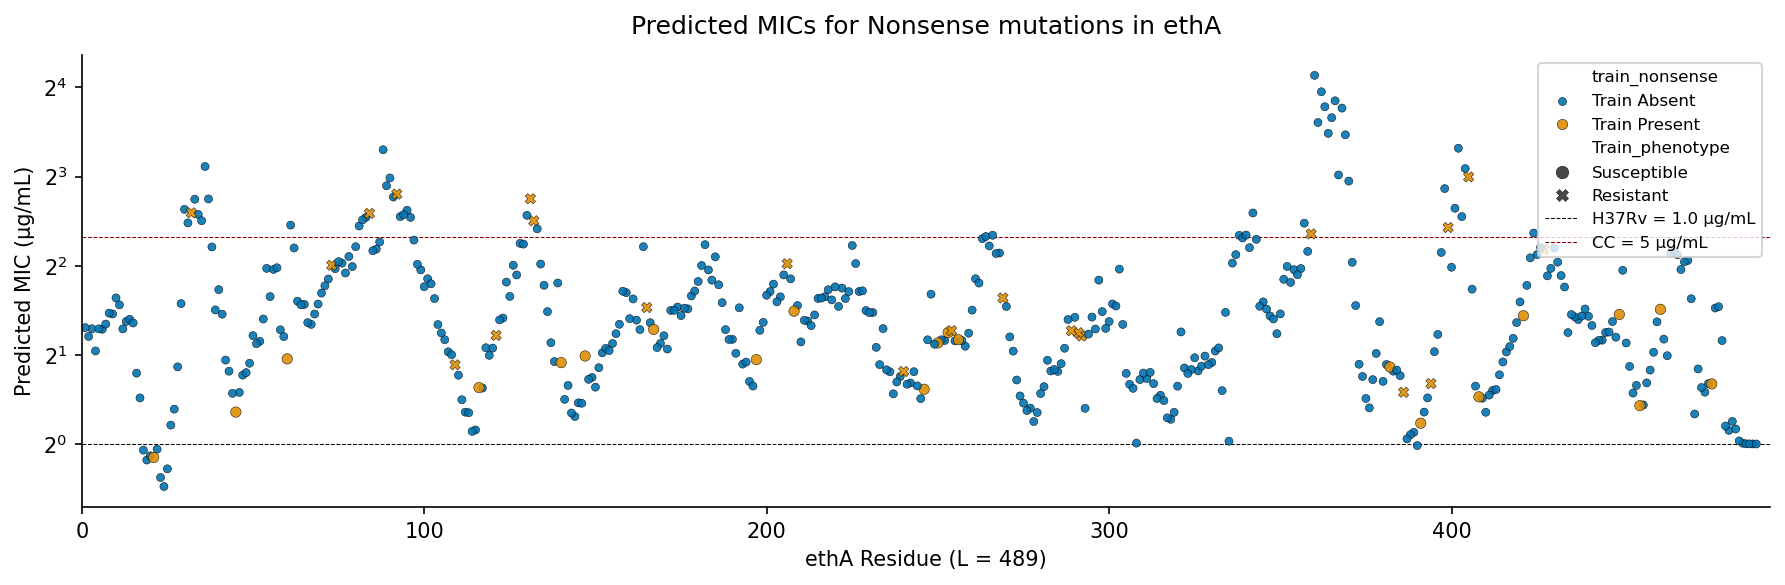

In [18]:
model_path = "ETO_lineage_amino_acid"
locus = 'ethA'

df_ETO_ethA_nonsense = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [361]:
len(df_ETO_ethA_nonsense.query("pred_MIC > 5")), len(df_ETO_ethA_nonsense.query("pred_MIC <= 5")), len(df_ETO_ethA_nonsense.query("pred_MIC <= 5"))/len(df_ETO_ethA_nonsense)

(52, 437, 0.8936605316973415)

In [363]:
df_ETO_ethA_nonsense.pred_MIC.mean()

3.0538046577096116

In [19]:
st.spearmanr(df_ETO_ethA_nonsense['codon'], df_ETO_ethA_nonsense['pred_MIC'])

SignificanceResult(statistic=-0.12325674713212253, pvalue=0.006351580936953587)

In [366]:
len(df_ETO_ethA_nonsense.query("train_nonsense=='Train Present'"))

43

In [24]:
codons_with_nonsense_in_train = df_ETO_ethA_nonsense.query("train_nonsense == 'Train Present'").codon.values

In [25]:
df_ETO_ethA_nonsense.query("train_nonsense != 'Train Present'")

,variant,log2_pred_MIC,pred_MIC,codon,train_nonsense,ETO_midpoint,Train_phenotype
0,ethA_p.Ala107*,1.036374,2.051066,107,Train Absent,NaN,Susceptible
1,ethA_p.Ala112*,0.359798,1.283246,112,Train Absent,NaN,Susceptible
2,ethA_p.Ala12*,1.293555,2.451313,12,Train Absent,NaN,Susceptible
3,ethA_p.Ala128*,2.252631,4.765511,128,Train Absent,NaN,Susceptible
4,ethA_p.Ala152*,1.025084,2.035078,152,Train Absent,NaN,Susceptible
...,...,...,...,...,...,...,...
484,ethA_p.Val487*,0.004015,1.002787,487,Train Absent,NaN,Susceptible
485,ethA_p.Val489*,0.003322,1.002305,489,Train Absent,NaN,Susceptible
486,ethA_p.Val7*,1.347103,2.544007,7,Train Absent,NaN,Susceptible
487,ethA_p.Val8*,1.470323,2.770840,8,Train Absent,NaN,Susceptible


In [26]:
# no relationship between codon at which a nonsense mutation is observed in the training dataset and the observed ETO MIC
st.spearmanr(df_ETO_ethA_nonsense.query("train_nonsense=='Train Present'")['codon'],
             df_ETO_ethA_nonsense.query("train_nonsense=='Train Present'")['ETO_midpoint']
            )

SignificanceResult(statistic=-0.02302693064599625, pvalue=0.8834733738373998)

In [27]:
for i, row in df_ETO_ethA_nonsense.iterrows():
    df_ETO_ethA_nonsense.loc[i, 'min_distance_to_codon_in_train'] = np.min(np.abs(row['codon'] - codons_with_nonsense_in_train))

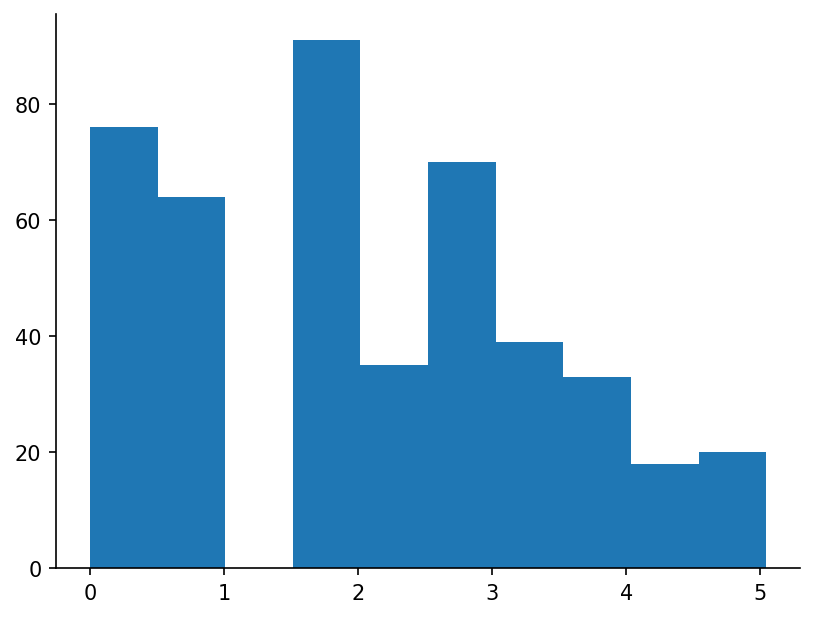

In [28]:
plt.hist(np.log2(df_ETO_ethA_nonsense.query("train_nonsense=='Train Absent'")['min_distance_to_codon_in_train']))
sns.despine()
plt.show()

In [42]:
# there is no relationship between the distance to an observed nonsense mutation and the predicted MIC
st.spearmanr(df_ETO_ethA_nonsense.query("train_nonsense=='Train Absent'")['min_distance_to_codon_in_train'], 
             df_ETO_ethA_nonsense.query("train_nonsense=='Train Absent'")['log2_pred_MIC'],
            )

SignificanceResult(statistic=0.0027917282001759256, pvalue=0.9531174898578598)

In [45]:
df_ETO_ethA_nonsense['pred_MIC'].mean()

3.0538046577096116

In [46]:
df_ETO_ethA_nonsense.train_nonsense.value_counts()

train_nonsense
Train Absent     446
Train Present     43
Name: count, dtype: int64

In [47]:
df_ETO_ethA_nonsense.query("train_nonsense=='Train Present'").Train_phenotype.value_counts()

Train_phenotype
Resistant      22
Susceptible    21
Name: count, dtype: int64

2 training isolates have early stop codons in mshA


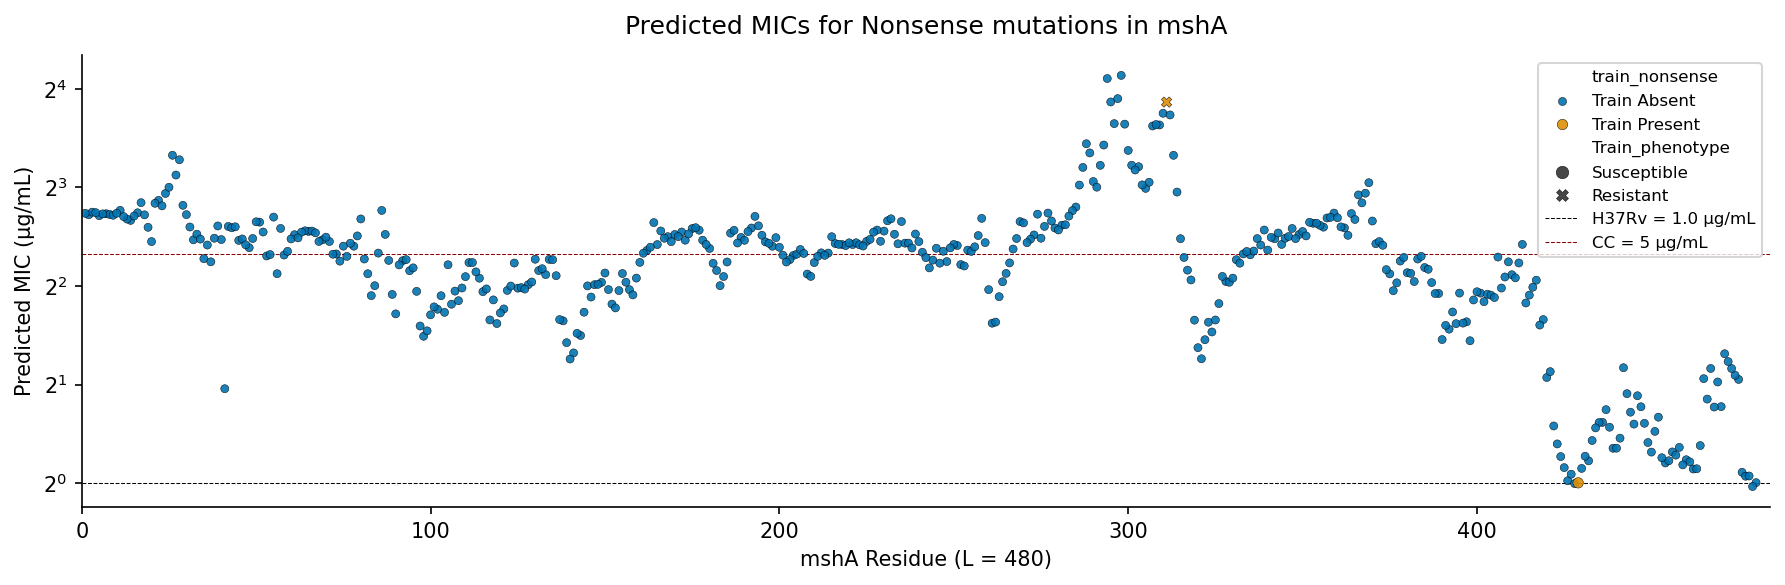

In [20]:
model_path = "ETO_lineage_amino_acid"
locus = 'mshA'

df_ETH_mshA_nonsense = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [21]:
st.spearmanr(df_ETH_mshA_nonsense['codon'], df_ETH_mshA_nonsense['pred_MIC'])

SignificanceResult(statistic=-0.3991647099162756, pvalue=8.73773700410875e-20)

In [240]:
df_ETH_mshA_nonsense.query("codon==311")

,variant,category,log2_pred_MIC,pred_MIC,codon,train_nonsense,ETO_midpoint,Train_phenotype
217,mshA_p.Gly311*,NaN,3.865734,14.578129,311,Train Present,10.0,Resistant


In [241]:
isolate_variants.query("variant=='mshA_p.Gly311*'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
312513,SAMEA7526397,576278,G,T,PASS,2491.0,NaN,1.0,71.0,35.0,60.0,NaN,NaN,stop_gained,mshA,NaN,NaN,mshA_p.Gly311*,Ethionamide,3) Uncertain significance
312514,SAMEA7526397,576278,G,T,PASS,2491.0,NaN,1.0,71.0,35.0,60.0,NaN,NaN,stop_gained,mshA,NaN,NaN,mshA_p.Gly311*,Isoniazid,3) Uncertain significance


In [242]:
df_ETO_phenos.query("ROLLINGDB_ID=='SAMEA7526397'")

,ROLLINGDB_ID,ETO_MEDIA,ETO_lower_bound,ETO_midpoint,ETO_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
3885,SAMEA7526397,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,3.1.2,3.1.1.i2,"east_african_indian,ghana,mungi",NaN,NaN,0.008058,3,-6.95535,0,1.0,3-1,train_set


19 training isolates have early stop codons in katG


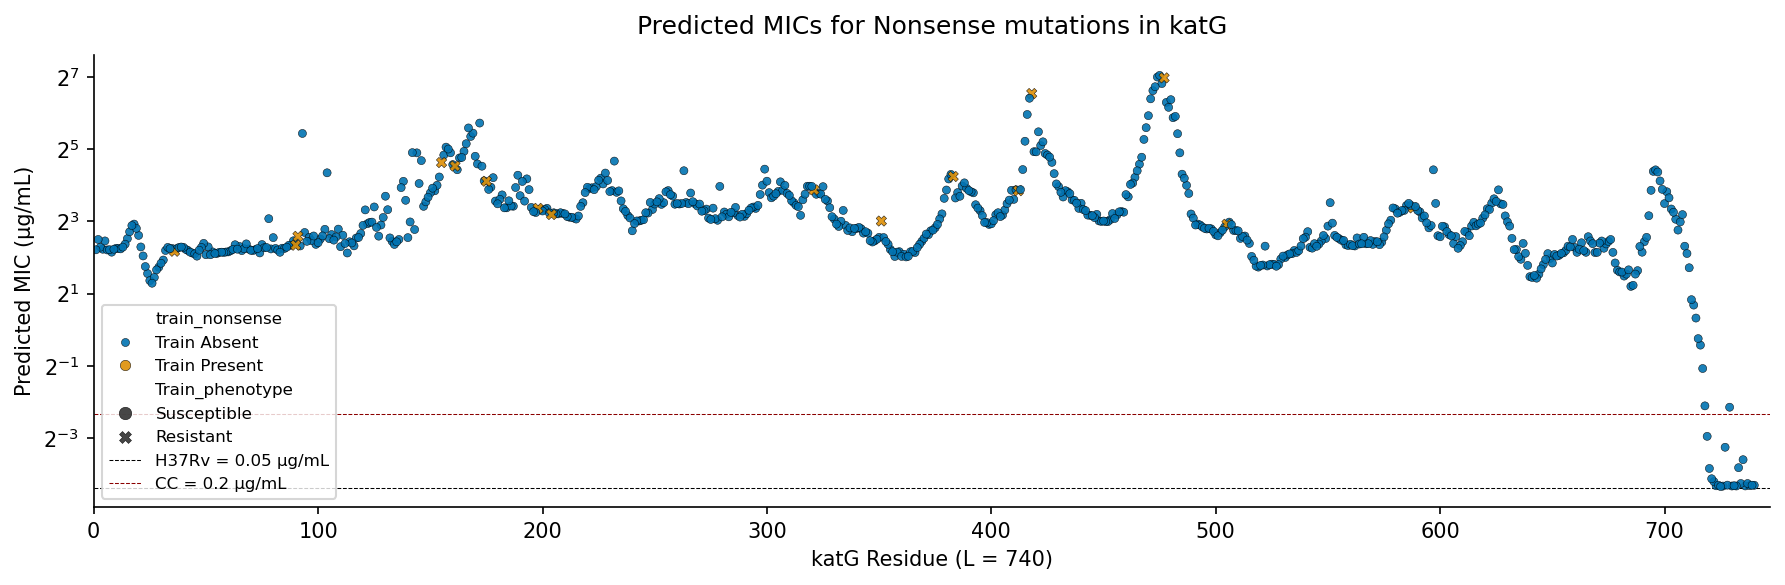

In [209]:
model_path = "INH_lineage_amino_acid"
locus = 'katG'
gene = 'katG'

df_INH_katG = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{gene}_nonsense_lineage_AA.svg")

In [211]:
df_INH_katG.query("pred_MIC <= 0.2").sort_values("codon")

,variant,log2_pred_MIC,pred_MIC,codon,train_nonsense,INH_midpoint,Train_phenotype
470,katG_p.Lys719*,-2.948099,0.129579,719,Train Absent,NaN,Susceptible
512,katG_p.Phe720*,-3.836912,0.069980,720,Train Absent,NaN,Susceptible
734,katG_p.Val721*,-4.121336,0.057458,721,Train Absent,NaN,Susceptible
213,katG_p.Gln722*,-4.199476,0.054429,722,Train Absent,NaN,Susceptible
184,katG_p.Asp723*,-4.315932,0.050208,723,Train Absent,NaN,Susceptible
513,katG_p.Phe724*,-4.299965,0.050767,724,Train Absent,NaN,Susceptible
735,katG_p.Val725*,-4.336418,0.049500,725,Train Absent,NaN,Susceptible
73,katG_p.Ala726*,-4.324223,0.049921,726,Train Absent,NaN,Susceptible
74,katG_p.Ala727*,-3.250164,0.105100,727,Train Absent,NaN,Susceptible
664,katG_p.Trp728*,-4.298033,0.050835,728,Train Absent,NaN,Susceptible


In [212]:
df_INH_katG.query("pred_MIC <= 0.2").sort_values("codon")

,variant,log2_pred_MIC,pred_MIC,codon,train_nonsense,INH_midpoint,Train_phenotype
470,katG_p.Lys719*,-2.948099,0.129579,719,Train Absent,NaN,Susceptible
512,katG_p.Phe720*,-3.836912,0.069980,720,Train Absent,NaN,Susceptible
734,katG_p.Val721*,-4.121336,0.057458,721,Train Absent,NaN,Susceptible
213,katG_p.Gln722*,-4.199476,0.054429,722,Train Absent,NaN,Susceptible
184,katG_p.Asp723*,-4.315932,0.050208,723,Train Absent,NaN,Susceptible
513,katG_p.Phe724*,-4.299965,0.050767,724,Train Absent,NaN,Susceptible
735,katG_p.Val725*,-4.336418,0.049500,725,Train Absent,NaN,Susceptible
73,katG_p.Ala726*,-4.324223,0.049921,726,Train Absent,NaN,Susceptible
74,katG_p.Ala727*,-3.250164,0.105100,727,Train Absent,NaN,Susceptible
664,katG_p.Trp728*,-4.298033,0.050835,728,Train Absent,NaN,Susceptible


In [184]:
df_INH_phenos = pd.read_csv(os.path.join(data_dir, "INH", "data_for_model.csv"))

isolate_variants.query("variant=='katG_p.Asp735*'").merge(df_INH_phenos[['ROLLINGDB_ID', 'INH_lower_bound', 'INH_upper_bound', 'category']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,INH_lower_bound,INH_upper_bound,category
0,2153907,GTC,CTA,Amb,3100.0,False,0.77,89.0,37.0,60.0,...,katG,c.2203_2205delGACinsTAG,p.Asp735*,katG_p.Asp735*,NaN,NaN,SAMEA3558168,3.2,inf,train_set


In [185]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA3558168' & drug=='Isoniazid'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
93625,2726210,T,C,PASS,5684.0,False,1.0,154.0,37.0,60.0,0.0,0.0,synonymous_variant,ahpC,c.18T>C,p.Ile6Ile,ahpC_c.18T>C,Isoniazid,4) Not assoc w R - Interim,SAMEA3558168


In [186]:
who_variants.query("variant=='katG_p.Asp735*'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1


9 training isolates have early stop codons in pncA


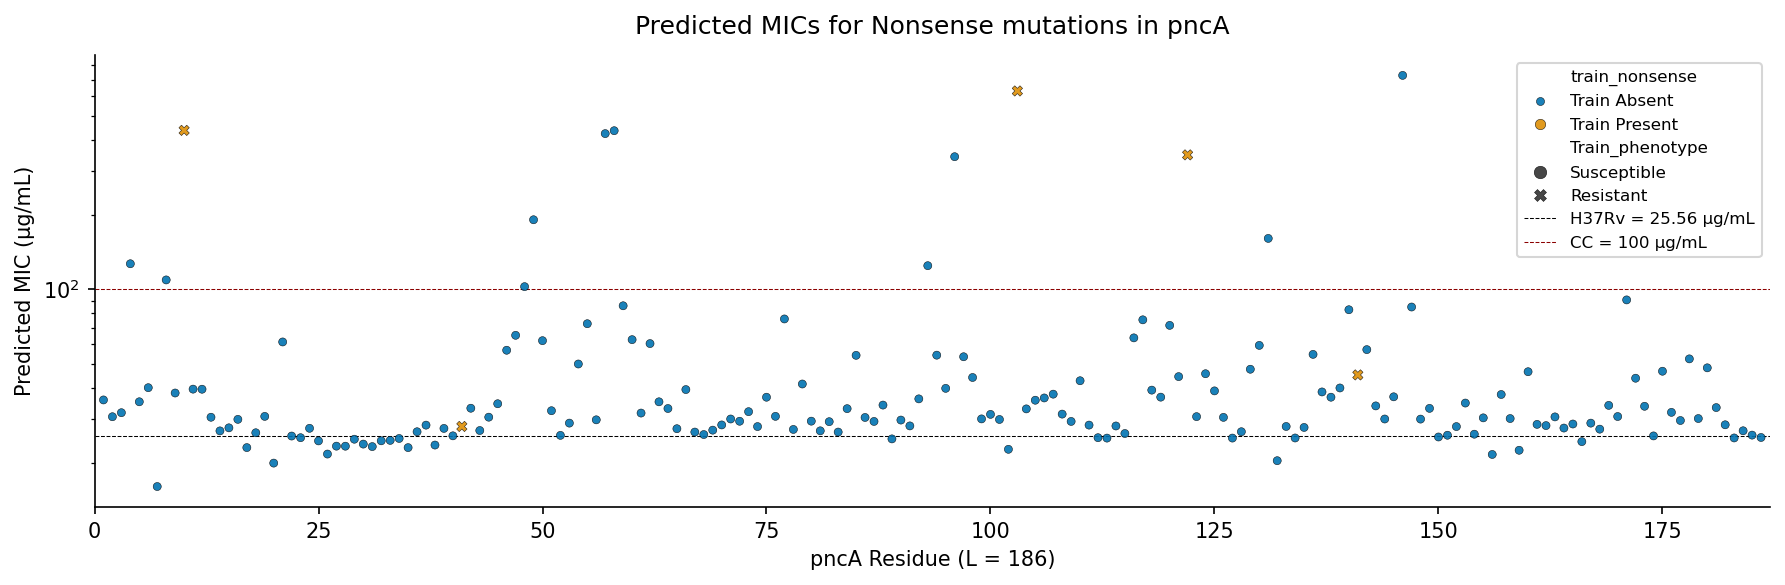

In [121]:
model_path = "PZA"
locus = 'pncA'
gene = 'pncA'

df_PZA_pncA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense.svg")

In [132]:
len(df_PZA_pncA.query("pred_MIC > 100")), len(df_PZA_pncA.query("pred_MIC > 100")) / len(df_PZA_pncA)

(13, 0.06989247311827956)

9 training isolates have early stop codons in pncA


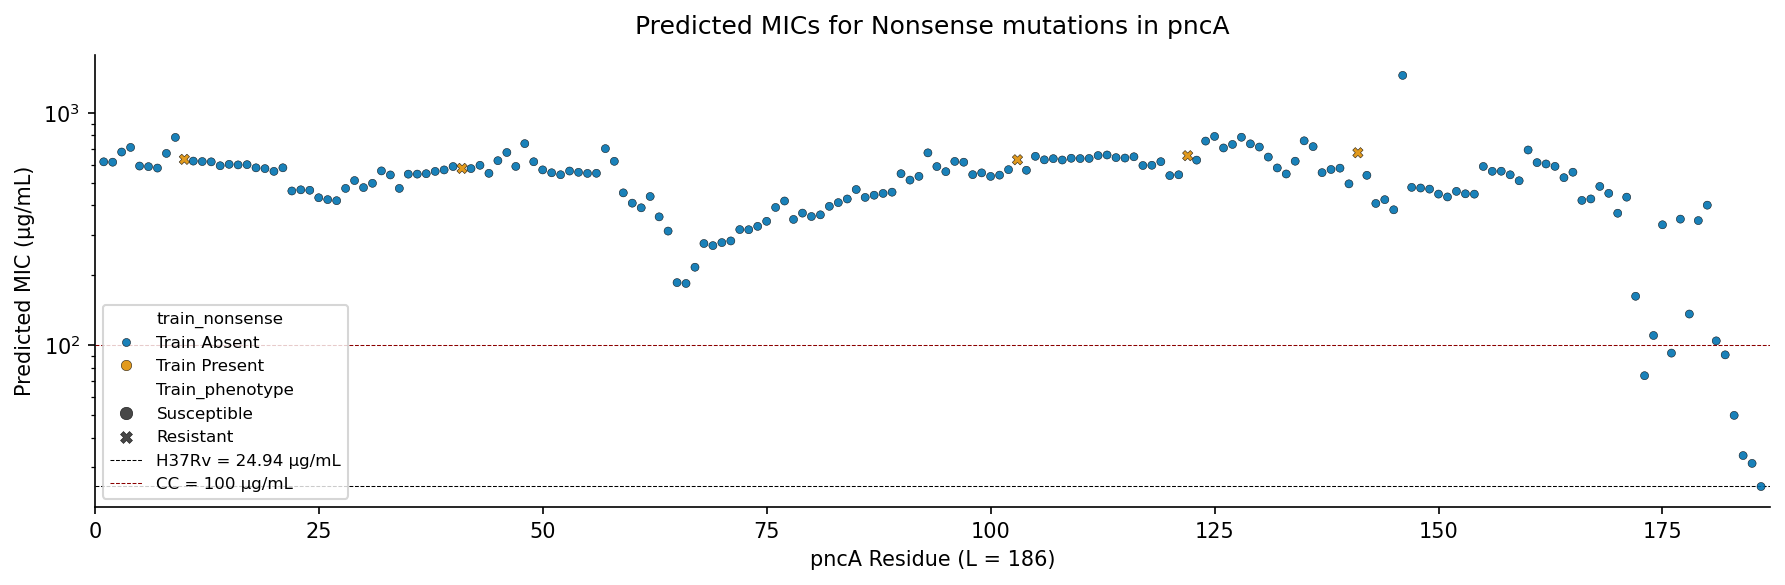

In [118]:
model_path = "PZA_amino_acid"
locus = 'pncA'
gene = 'pncA'

df_PZA_pncA_AA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{gene}_nonsense_AA.svg")

In [119]:
df_PZA_pncA_AA.query("pred_MIC < 100").sort_values("codon")

,variant,log2_pred_MIC,pred_MIC,codon,train_nonsense,PZA_midpoint,Train_phenotype
65,pncA_p.Glu173*,6.211962,74.128780,173,Train Absent,NaN,Susceptible
29,pncA_p.Arg176*,6.534536,92.702500,176,Train Absent,NaN,Susceptible
107,pncA_p.Leu182*,6.509673,91.118540,182,Train Absent,NaN,Susceptible
178,pncA_p.Val183*,5.644733,50.030410,183,Train Absent,NaN,Susceptible
55,pncA_p.Cys184*,5.070989,33.613960,184,Train Absent,NaN,Susceptible
134,pncA_p.Ser185*,4.958846,31.100073,185,Train Absent,NaN,Susceptible
135,pncA_p.Ser186*,4.628453,24.734499,186,Train Absent,NaN,Susceptible


In [20]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))
gene = 'pncA'

# 2.3: Did the models predict resistance for Group 1 Mutations?

In [16]:
def did_model_get_missense_WHO_Rassoc_mutations(model_path, gene):

    drug = model_path.split("_")[0]
    cc = cc_dict[drug]
    
    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).query("~ROLLINGDB_ID.str.contains('\*') & ROLLINGDB_ID != 'MT_H37Rv'").reset_index(drop=True)

    # add codon
    ssm_predictions['codon'] = ssm_predictions['ROLLINGDB_ID'].apply(get_variant_number, args=('+'))
    
    # rename to original format to merge with WHO catalog
    ssm_predictions['drug'] = abbr_drug_dict[drug]
    
    # keep only those in the catalog
    ssm_predictions = ssm_predictions.merge(who_variants_V2[['drug', 'variant', 'FINAL CONFIDENCE GRADING']], left_on=['drug', 'ROLLINGDB_ID'], right_on=['drug', 'variant'], how='inner')
    
    ssm_predictions = ssm_predictions.loc[ssm_predictions['FINAL CONFIDENCE GRADING'].isin(['1) Assoc w R'])]

    found = len(ssm_predictions.query("pred_MIC > @cc"))
    missed = len(ssm_predictions.query("pred_MIC <= @cc"))
    
    print(f"Predicted resistance for {found}/{found + missed} ({np.round(found / (found + missed)*100, 2)}%) of Group 1 missense mutations")

    return ssm_predictions

In [17]:
drug = 'PZA'

# _ = did_model_get_missense_WHO_Rassoc_mutations(drug, 'pncA')
_ = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_lineage_amino_acid", 'pncA')

Predicted resistance for 55/110 (50.0%) of Group 1 missense mutations


In [18]:
drug = 'INH'

katG_AA_missense = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_lineage_amino_acid", 'katG')

Predicted resistance for 3/4 (75.0%) of Group 1 missense mutations


In [19]:
drug = 'ETH'

_ = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_lineage_amino_acid", 'ethA')

Predicted resistance for 0/1 (0.0%) of Group 1 missense mutations


In [73]:
def get_missense_pred_matrix(model_path, gene):

    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})

    # add amino acid codon
    ssm_predictions['codon'] = ssm_predictions['mutation'].apply(get_variant_number, args='+')
    ssm_predictions.loc[ssm_predictions['mutation']=='MT_H37Rv', 'codon'] = 0

    # add binary value for the predicted MICs
    ssm_predictions['pred_phenotype'] = (ssm_predictions['pred_MIC'] > 100).fillna(0).astype(int)
    
    # for plotting
    ssm_predictions['mut_AA'] = ssm_predictions['mutation'].str[-3:]
    
    # get MIC fold change to plot diverging heatmap
    h37Rv_pred = ssm_predictions.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0]
    ssm_predictions['log2_fold_change_H37Rv'] = np.log2(ssm_predictions['pred_MIC'] / h37Rv_pred)

    # no nonsense plotted in this graph
    missense_pred_matrix = ssm_predictions.query("~mutation.str.contains('\*') & mutation != 'MT_H37Rv'")

    # keep only first codon changes that are alternative start codons. The amino acid is not changed in these, just 
    # missense_pred_matrix = missense_pred_matrix.loc[~((missense_pred_matrix['codon']==1) & (~missense_pred_matrix['mutation'].str.contains('|'.join(['1Val', '1Leu', '1Ile', '1Met']))))]

    # exclude first codon because they're either start lost or the alternative start codons are converted to Met
    missense_pred_matrix = missense_pred_matrix.loc[missense_pred_matrix['codon'] != 1]

    # PLOT LOG FOLD CHANGE RELATIVE TO H37RV
    missense_pred_matrix = missense_pred_matrix.pivot(index='codon', columns='mut_AA', values='log2_fold_change_H37Rv')
    
    missense_pred_matrix.index = missense_pred_matrix.index.values.astype(int)
    
    # check that the NaNs are the reference amino acids. Not true for the first codon because all the non-Met/Val/Ile/Leu cases will be NaN
    # assert len(np.unique(missense_pred_matrix.iloc[1:].isna().sum(axis=1))) == 1
    assert len(np.unique(missense_pred_matrix.isna().sum(axis=1))) == 1
    assert np.unique(missense_pred_matrix.isna().sum(axis=1))[0] == 1
    
    gene_start, gene_end, gene_sense = h37Rv_genes.query("Symbol==@gene")[['Start', 'End', 'Strand']].values[0]
    
    if gene_sense == '-':
        protein_seq = h37Rv.seq[gene_start-1:gene_end].reverse_complement().translate()
    else:
        protein_seq = h37Rv.seq[gene_start-1:gene_end].translate()
    
    # protein sequence checks. When creating df_protein_seqs for the encoding, alternative start codons were translated to M
    assert protein_seq[0] in ['M', 'V', 'I', 'L']
    assert protein_seq[-1] == '*'
    assert list(str(protein_seq)).index('*') == len(protein_seq) - 1
    
    protein_seq = str(protein_seq)[:-1]
    
    for i, row in missense_pred_matrix.iterrows():

        # first row is loc 1 (because codon 1), not 0 like default
        if i > 1:
            nan_aa = row[row.isna()].index.tolist()
            assert len(nan_aa) == 1
            assert nan_aa[0] == Bio.SeqUtils.IUPACData.protein_letters_1to3[protein_seq[i-1]]
        
    # fill NaNs (no AA change) with a log fold change of 0 (fold change of 1) because sns.clustermap can't handle them
    missense_pred_matrix = missense_pred_matrix.fillna(0)
    
    return ssm_predictions, missense_pred_matrix

In [74]:
def plot_saturation_mutagenesis_heatmap(missense_pred_matrix, gene, x_min=None, x_max=None, col_colors=None, saveName=None):
        
    hydrophobic = 'lightgreen'
    charged = 'cornflowerblue'
    polar_uncharged = 'mediumpurple'
    other = 'white'
    aromatic = 'orange'
    
    amino_acid_property_colors = pd.DataFrame(index=np.sort(pd.Series(missense_pred_matrix.columns).apply(lambda x: Bio.SeqUtils.IUPACData.protein_letters_3to1[x]).values))
    
    amino_acid_property_colors['color'] = [hydrophobic, other, charged, charged, aromatic, other, charged, hydrophobic, charged, hydrophobic, hydrophobic, polar_uncharged, other, polar_uncharged, charged, polar_uncharged, polar_uncharged, hydrophobic, aromatic, aromatic]
    
    amino_acid_property_colors = amino_acid_property_colors.reset_index()
    amino_acid_property_colors.index = [Bio.SeqUtils.IUPACData.protein_letters_1to3[val] for val in amino_acid_property_colors['index']]

    cluster = sns.clustermap(missense_pred_matrix.T,
                       z_score=None,
                       standard_scale=None,
                       row_cluster=True,
                       row_colors=amino_acid_property_colors[['color']],
                       col_colors=col_colors,
                       col_cluster=False,
                       center=0,
                       linewidths=0.1,
                       linecolor='lightgray',
                       cmap=sns.color_palette("coolwarm", as_cmap=True),
                       figsize=(16, 6),
                       dendrogram_ratio=(0.05, 0.05),
                   )

    # Adjust the position of the row dendrogram axes
    row_dendro_ax = cluster.ax_row_dendrogram.get_position()
    cluster.ax_row_dendrogram.set_position([row_dendro_ax.x0, row_dendro_ax.y0, row_dendro_ax.width, row_dendro_ax.height])
    
    # Get the positions of the main heatmap axes
    pos = cluster.ax_heatmap.get_position()
    
    # Define the position for the colorbar axis: vertical and to the right of the plot
    cbar_ax = plt.axes([pos.x1 + 0.015, pos.y0, 0.01, pos.height])
    
    # Create the colorbar
    cbar = plt.colorbar(cluster.ax_heatmap.collections[0], cax=cbar_ax, orientation='vertical')
    
    # Remove the black outline around the color bar
    cbar.outline.set_visible(False)
    
    # Remove the colorbar axes created by sns.clustermap
    plt.delaxes(cluster.cax)
    
    # Remove the "colors" name and ticks for both axis colorings
    cluster.ax_row_colors.set_xticks(ticks=[], labels=[])
    
    # Adjust the x-axis limits after plotting
    if x_min is None:
        x_min = missense_pred_matrix.index.min()

    if x_max is None:
        x_max = missense_pred_matrix.index.max()

    if col_colors is not None:
        cluster.ax_col_colors.set_yticks(ticks=[], labels=[])
        cluster.ax_col_colors.set_xlim(left=x_min, right=x_max)

    # Move y-axis to the left
    cluster.ax_heatmap.yaxis.set_ticks_position('left')

    # Move x-axis to the top to be with the color legend
    cluster.ax_heatmap.xaxis.set_ticks_position('top')

    cluster.ax_heatmap.set_xlim(left=x_min, right=x_max)

    # Adjust the y positions of the tick labels
    for label in cluster.ax_heatmap.get_xticklabels():
        label.set_fontsize(9)

        # Move the ticks slightly higher too to not interfere with the coloring
        if col_colors is not None:
            label.set_y(label.get_position()[1] + 0.03)
    
    # Change rotation of x and y ticks
    cluster.ax_heatmap.set_xticklabels(cluster.ax_heatmap.get_xticklabels(), rotation=90)
    cluster.ax_heatmap.set_yticklabels(cluster.ax_heatmap.get_yticklabels(), rotation=0)
    
    cluster.ax_heatmap.set_xlabel(f'{gene} Residue')
    cluster.ax_heatmap.set_ylabel('')
    
    sns.despine()

    if saveName is None:
        plt.show()
    else:
        if '.png' in saveName:
            plt.savefig(saveName, bbox_inches='tight', dpi=600)
        else:
            plt.savefig(saveName, bbox_inches='tight')

    pred_summary = pd.DataFrame(missense_pred_matrix.mean(axis=1)).reset_index()
    pred_summary.columns = ['residue', 'average']

    return pred_summary


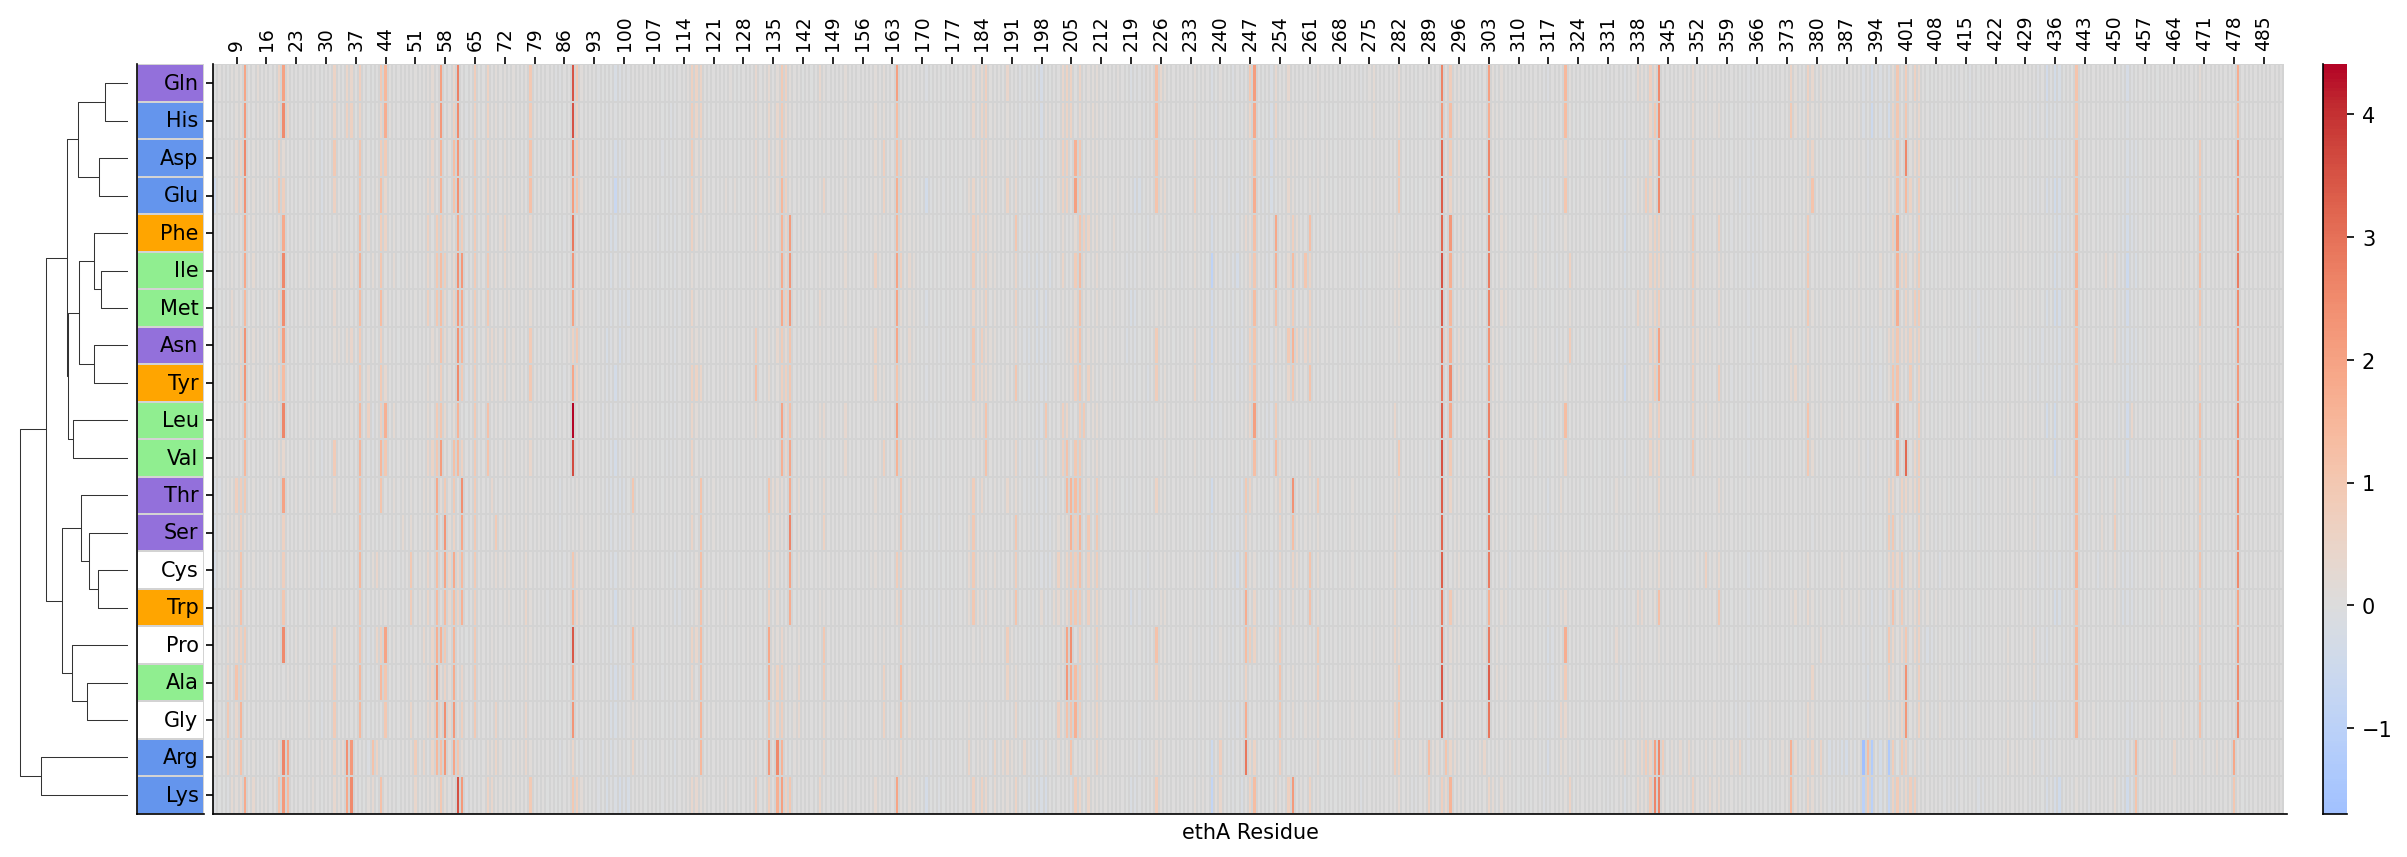

In [76]:
model_path = 'ETO_lineage_amino_acid'
gene = 'ethA'

_, ETO_missense_pred_matrix = get_missense_pred_matrix(model_path, gene)

_ = plot_saturation_mutagenesis_heatmap(ETO_missense_pred_matrix, gene, x_min=None, x_max=None, col_colors=None)#, saveName="results/Ethionamide/ethA_SSM_heatmap.svg")

In [89]:
df_ETO_ethA_missense = pd.DataFrame(ETO_missense_pred_matrix.mean(axis=1)).reset_index()
df_ETO_ethA_missense.columns = ['codon', 'missense_avg_log2_FC']

In [90]:
df_ETO_ethA_comparison = df_ETO_ethA_nonsense.merge(df_ETO_ethA_missense, on='codon')

In [91]:
st.spearmanr(df_ETO_ethA_comparison['log2_pred_MIC'],
             df_ETO_ethA_comparison['missense_avg_log2_FC']
            )

SignificanceResult(statistic=0.19675249538385226, pvalue=1.1970454993862057e-05)

In [96]:
# plt.scatter(df_ETO_ethA_comparison['codon'], df_ETO_ethA_comparison['log2_pred_MIC'])
# plt.scatter(df_ETO_ethA_comparison['codon'], df_ETO_ethA_comparison['missense_avg_log2_FC'])

In [126]:
MIC_thresh = 4
df_ETO_ethA_nonsense.loc[df_ETO_ethA_nonsense['pred_MIC'] > MIC_thresh, 'color'] = sns.color_palette("coolwarm", n_colors=5).as_hex()[-1] # red
df_ETO_ethA_nonsense.loc[df_ETO_ethA_nonsense['pred_MIC'] <= MIC_thresh, 'color'] = '#ffffff'

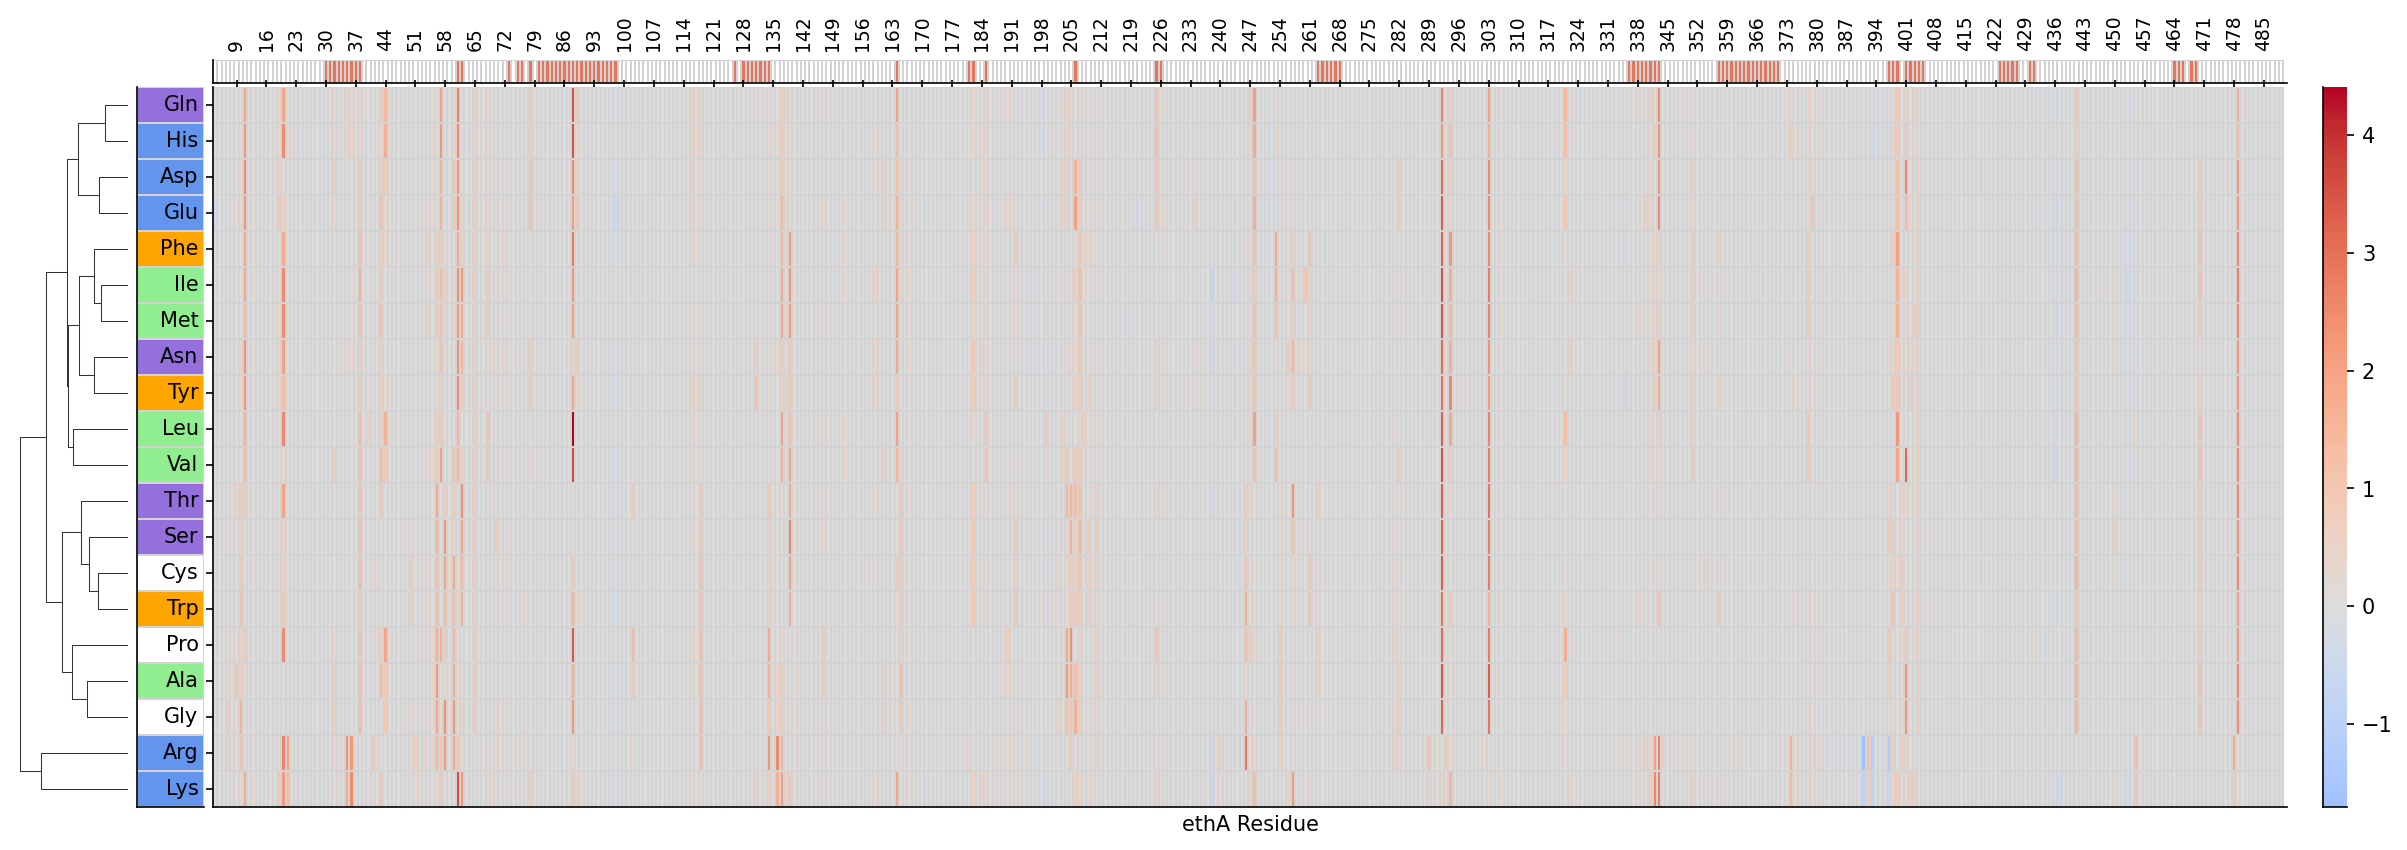

In [128]:
pred_summary = plot_saturation_mutagenesis_heatmap(ETO_missense_pred_matrix, 'ethA', x_min=None, x_max=None, col_colors=df_ETO_ethA_nonsense[['codon', 'color']].set_index('codon'))

Arg231, Gly263, Gly319 and Glu324) (Fig. 3C). Each of these amino acids plays an important role in either the substrate binding or the domain interaction (Fig. 3B). The side-chain amines of Arg273. Gly299 is not in the vicinity of the active site, but should be important for the protein stability as the next residue, Gly300, forms the only interdomain hydrogen bond with Gly61 (Fig. 3A). Although not directly seen in the model, Gly356

 Towards the end of C-terminus, a large α-helix spanning Cys409 to Ile445 crosses back to the N-terminal, which is likely to stabilize the overall folding of the protein. Therefore the mutations within this α-helix, such as in mc24937, would detrimentally affect the conformation of MshA leading to its inactivation.

# GeO Clustering

In [13]:
def average_missense_pred_by_residue_save_for_GeO(model_path, gene):
    '''
    Doesn't matter which column you use between pred_MIC, log2_pred_MIC, and fold_change_H37Rv because they're all just transformations of each other.
    '''

    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
    
    # add amino acid codon
    ssm_predictions['codon'] = ssm_predictions['mutation'].apply(get_variant_number, args='+')
    h37Rv_pred = ssm_predictions.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0]
    ssm_predictions['log2_fold_change_H37Rv'] = np.log2(ssm_predictions['pred_MIC'] / h37Rv_pred)

    # exclude codon 1 because the only mutations are to the alternative amino acids V, I, and L, but all are replace with M anyway
    # exclude nonsense mutations, this is only for missense, and exclude H37Rv and first codon, which will be added in manually
    df_keep = ssm_predictions.query("mutation != 'MT_H37Rv' & codon > 1 & ~mutation.str.contains('\*')")

    # should be 19 only because there are 19 other amino acids at each site 
    df_keep_summary = pd.DataFrame(df_keep.codon.value_counts()).reset_index().sort_values('codon')
    assert df_keep_summary['count'].nunique() == 1
    assert df_keep_summary['count'].unique()[0] == 19
    assert df_keep_summary['codon'].min() == 2
    
    df = pd.DataFrame(df_keep.groupby("codon")['log2_fold_change_H37Rv'].mean()).reset_index()
    df.columns = ['residue', 'average']
    df = df.sort_values('residue')

    if not os.path.isdir(f"spatial_clustering/{gene}"):
        os.makedirs(f"spatial_clustering/{gene}")

    df.to_csv(f"spatial_clustering/{gene}/values_to_cluster.csv", index=False)

In [19]:
average_missense_pred_by_residue_save_for_GeO("PZA_amino_acid", "pncA")

In [96]:
average_missense_pred_by_residue_save_for_GeO("INH_lineage_amino_acid", "katG")

In [15]:
average_missense_pred_by_residue_save_for_GeO("ETO_lineage_amino_acid", "ethA")

In [16]:
average_missense_pred_by_residue_save_for_GeO("MXF_lineage_amino_acid", "gyrA")

In [17]:
average_missense_pred_by_residue_save_for_GeO("MXF_lineage_amino_acid", "gyrB")

In [18]:
average_missense_pred_by_residue_save_for_GeO("RIF_lineage_amino_acid", "rpoB")

In [24]:
def plot_saturation_heatmap_with_GeO_colors(model_path, gene, pval_thresh=0.1, plot_neutral=False, x_min=None, x_max=None):
    '''
    Plot the hot spots from each of the positive and negative score analyses. These mean hot spots of high and low predicted MICs. Cold spots are no significant change from H37Rv

    G_score > 1 for both cases to be a hot spot because we took absolute value of the negative scores for clustering. 

    G_score < 1 and BH_pval ≤ 0.05 = cold spot meaning no significant change from H37Rv, NOT significantly associated with hypersusceptibility
    '''
    
    drug = model_path.split('_')[0]

    GeO_scores = pd.read_csv(f"supplement/{gene}_GeO_scores.csv").rename(columns={'residue': 'codon'})

    color_dict = {1: sns.color_palette("coolwarm", n_colors=5).as_hex()[-1], # red
                 -1: sns.color_palette("coolwarm", n_colors=5).as_hex()[0], # blue
                 np.nan: '#ffffff' # gray
                 }    

    # add a different color for neutral mutations. If plot_neutral = False, they will be gray
    if plot_neutral:
        color_dict[0] = "#ab83a7" # mixing of the red and blue colors


    GeO_scores.loc[(GeO_scores['BH_pval'] <= pval_thresh) & (GeO_scores['G_score'] > 0) & (GeO_scores['average'] > 0), 'clustering_result'] = 1
    GeO_scores.loc[(GeO_scores['BH_pval'] <= pval_thresh) & (GeO_scores['G_score'] < 0) & (GeO_scores['average'] > 0), 'clustering_result'] = -1
    
    GeO_scores['color'] = GeO_scores['clustering_result'].map(color_dict)

    protein_length = int((h37Rv_full.query("Name==@gene")['Stop'].values[0] - h37Rv_full.query("Name==@gene")['Start'].values[0] + 1) / 3) - 1
    
    # get the residues that are missing from the structure
    missing_residues = list(set(np.arange(protein_length) + 1) - set(GeO_scores.codon))
    
    # set their color to be insignificant
    GeO_scores = pd.concat([GeO_scores, pd.DataFrame({'codon': missing_residues, 'color': '#ffffff'})], axis=0)

    # just need the mapping between codon and color
    col_colors = GeO_scores[['codon', 'color']].set_index('codon')
    
    # get the AA prediction matrix
    _, AA_matrix = get_missense_pred_matrix(model_path, gene)

    pred_summary = plot_saturation_mutagenesis_heatmap(AA_matrix, gene, x_min=x_min, x_max=x_max, col_colors=col_colors, saveName=f"results/{abbr_drug_dict[drug]}/{gene}_SSM_heatmap_GeO.png")

    # NaNs are residues that are not in the structure
    return GeO_scores.dropna(subset='G_score'), AA_matrix, pred_summary

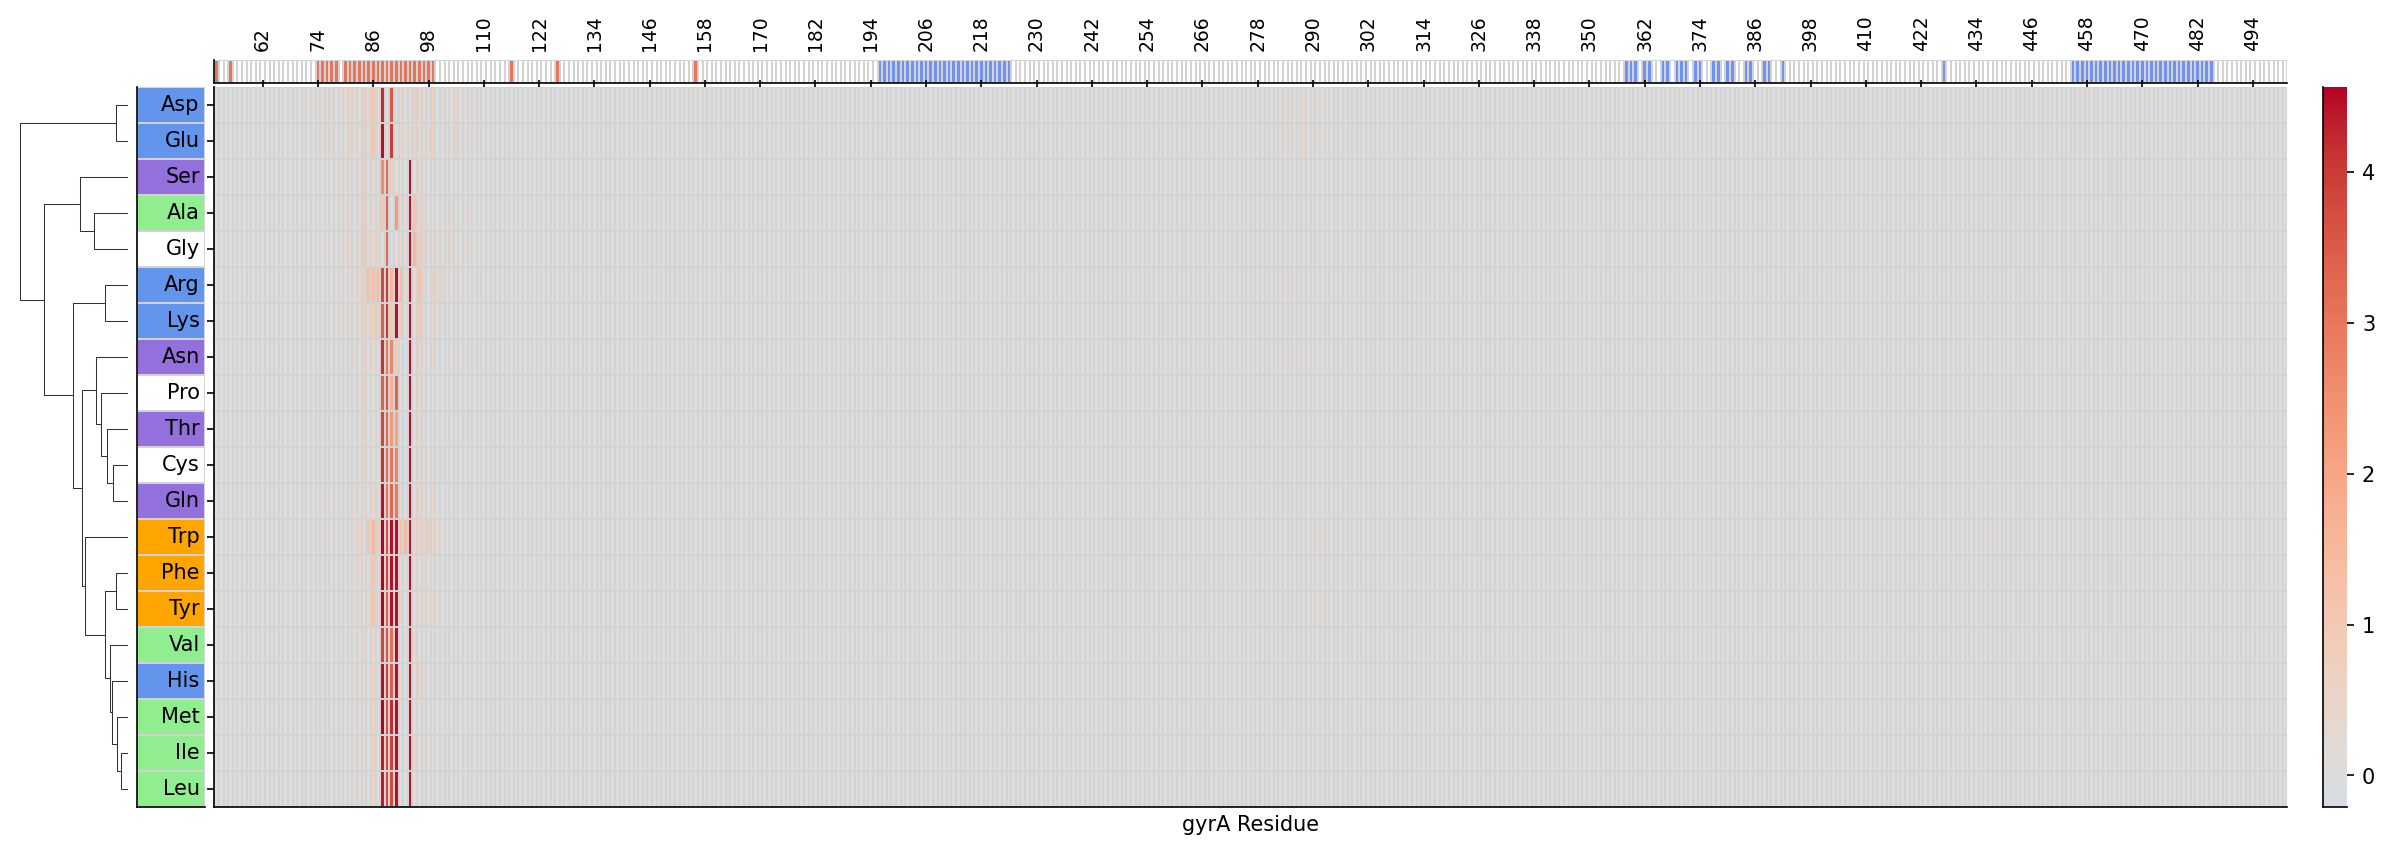

In [25]:
model_path = 'MXF_lineage_amino_acid'
gene = 'gyrA'

# only the important sites
gyrA_GeO_scores, gyrA_missense, gyrA_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene, x_min=50, x_max=500)

In [26]:
gyrA_GeO_scores.dropna(subset='clustering_result').codon.min(), gyrA_GeO_scores.dropna(subset='clustering_result').codon.max()

(50, 485)

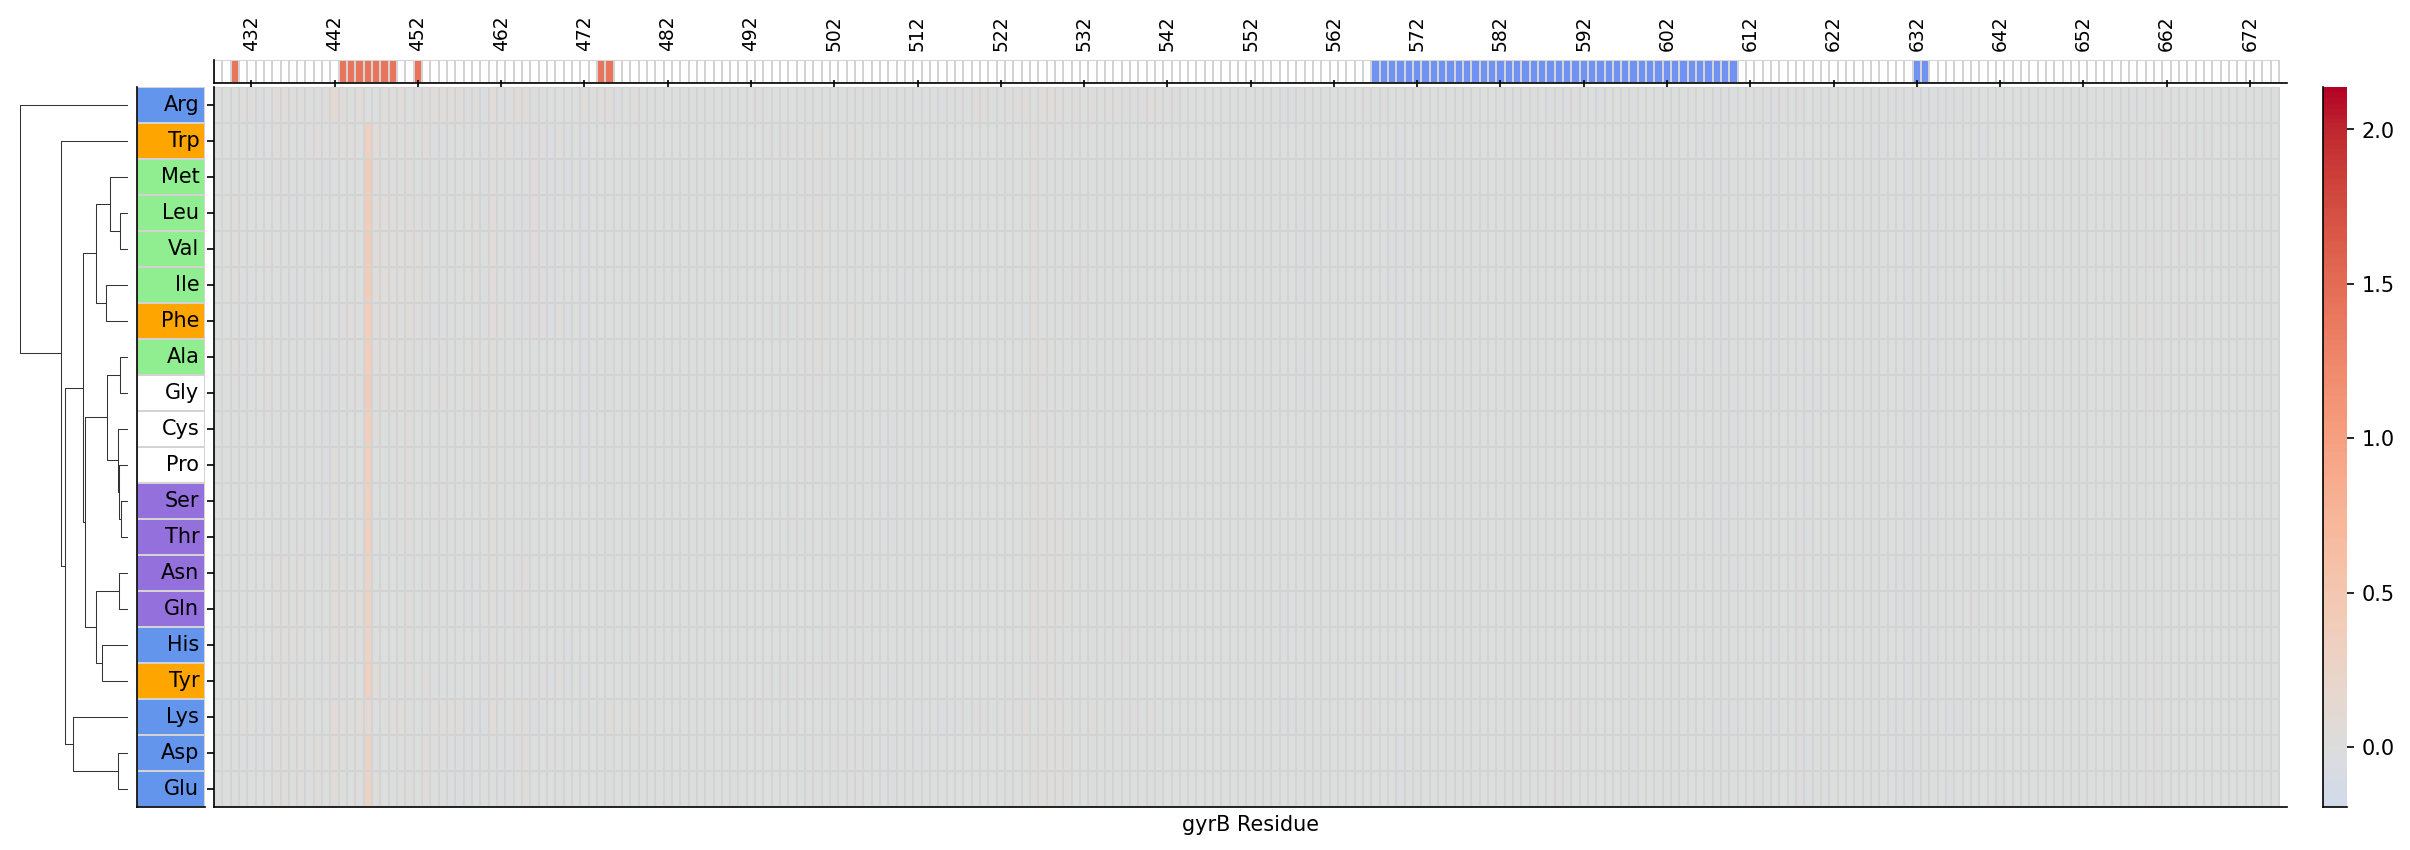

In [27]:
model_path = 'MXF_lineage_amino_acid'
gene = 'gyrB'

# the gyrB structure used for clustering only has 426-675
gyrB_GeO_scores, gyrB_missense, gyrB_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene, x_min=426)

In [30]:
gyrB_GeO_scores.dropna(subset='clustering_result').codon.min(), gyrB_GeO_scores.dropna(subset='clustering_result').codon.max()

(430, 633)

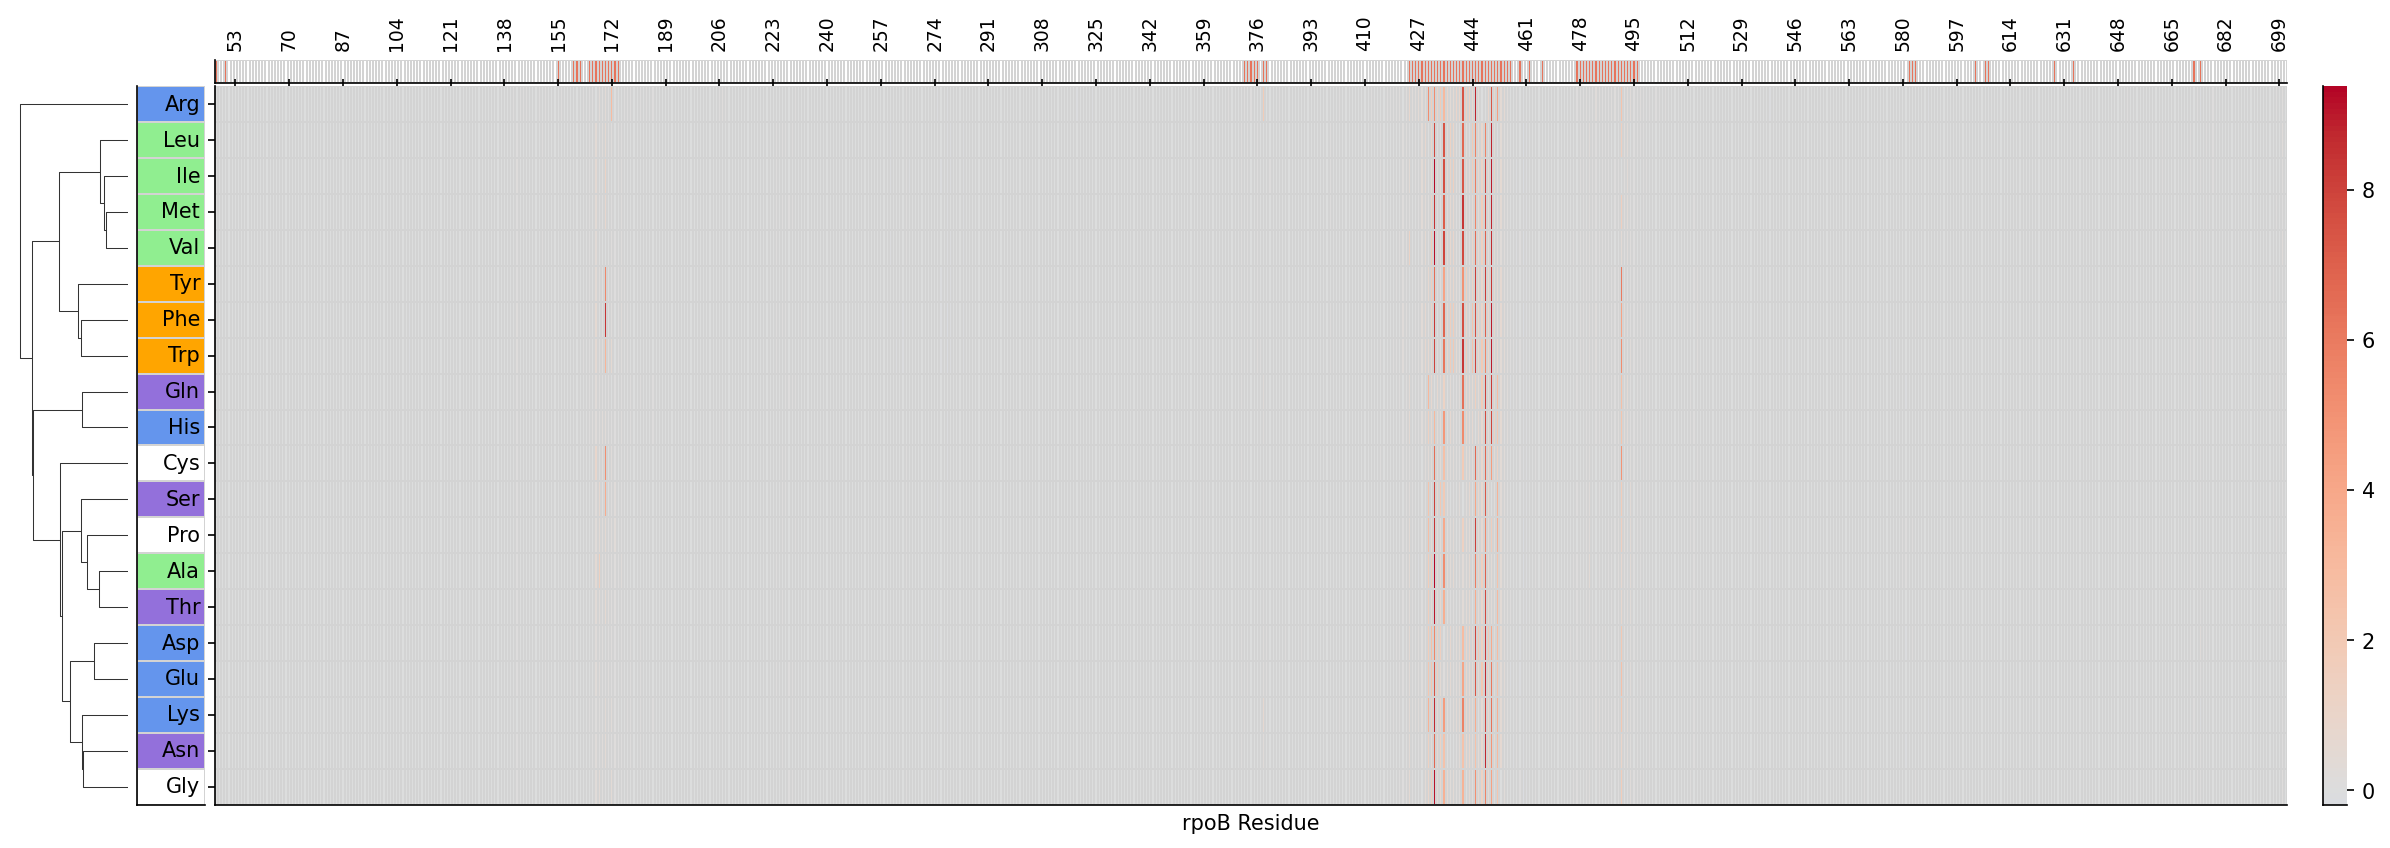

In [22]:
model_path = 'RIF_lineage_amino_acid'
gene = 'rpoB'

# R-associated hot spots occur only in 47-674 (see other notebook), so only show those
rpoB_GeO_scores, rpoB_missense, rpoB_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene, plot_neutral=False, x_min=45, x_max=700)

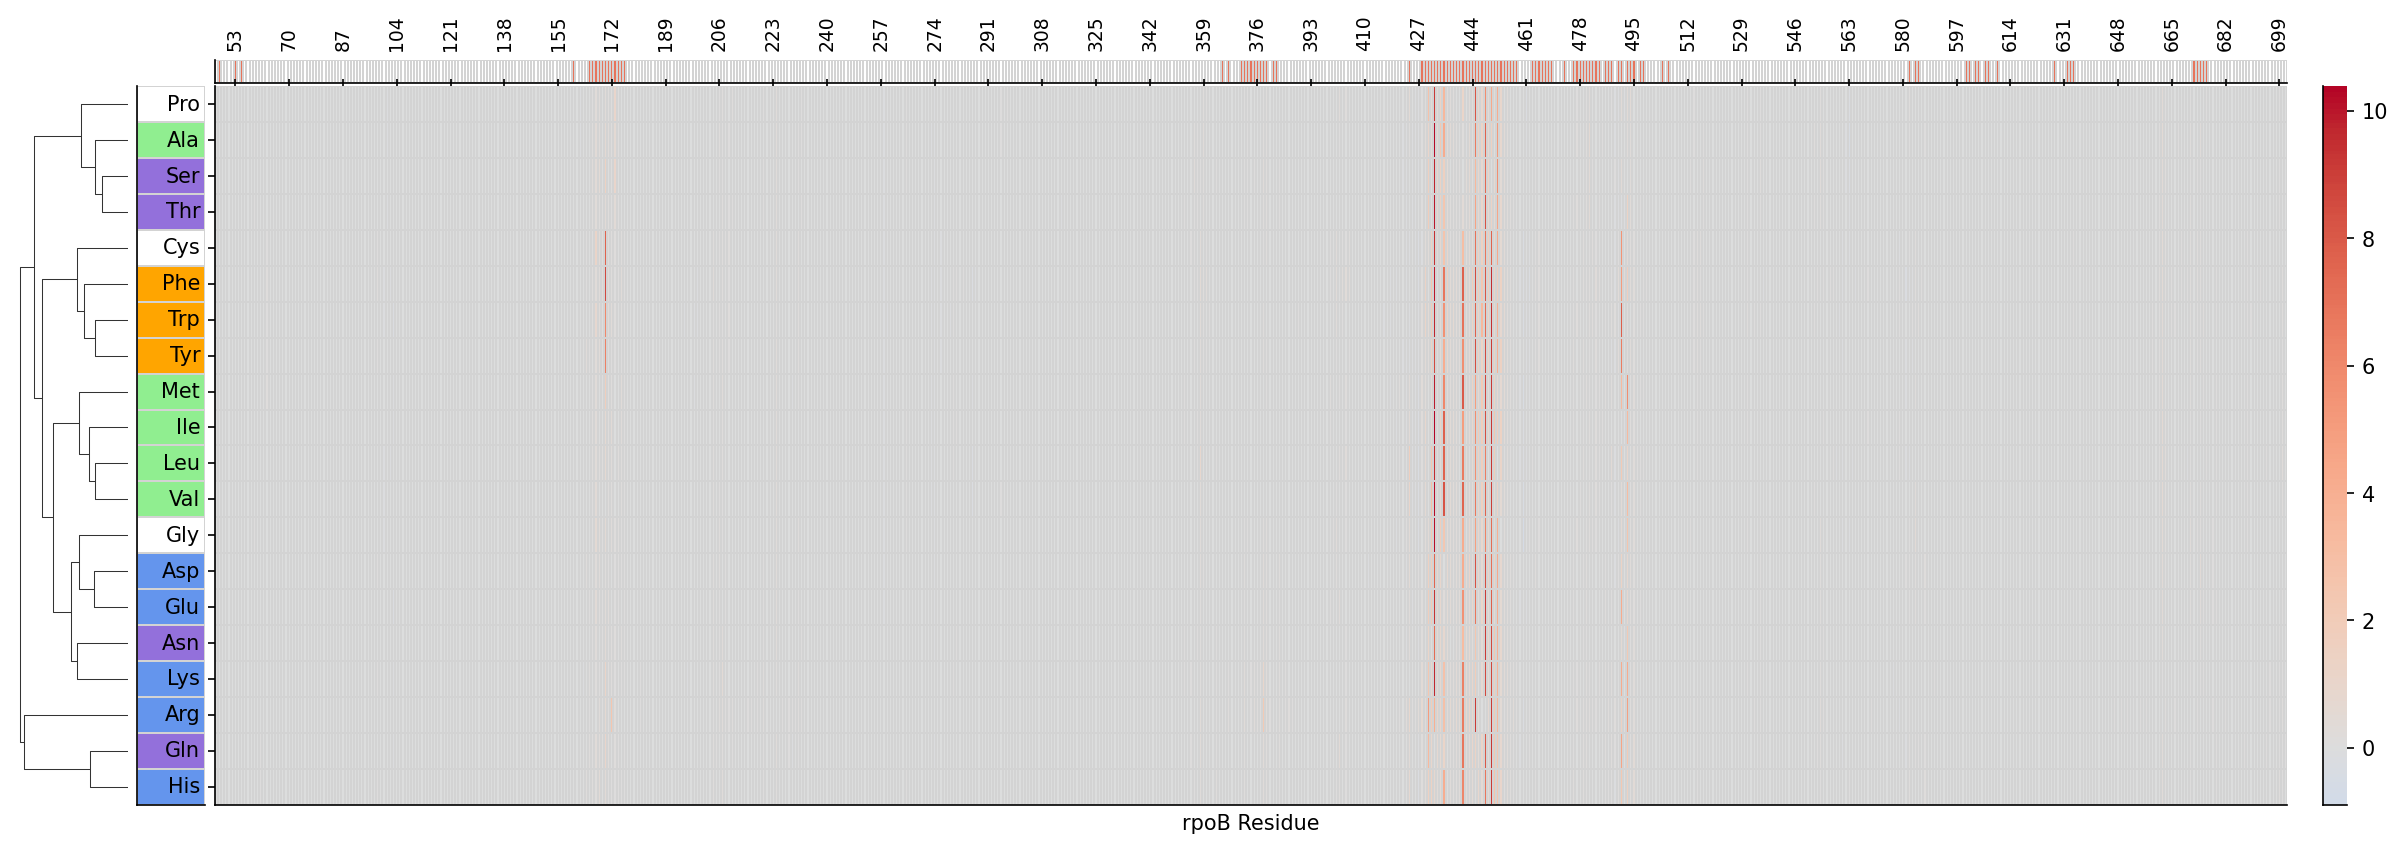

In [36]:
model_path = 'RIF_lineage_amino_acid'
gene = 'rpoB'

# R-associated hot spots occur only in 47-674 (see other notebook), so only show those
rpoB_GeO_scores, rpoB_missense, rpoB_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene, plot_neutral=False, x_min=45, x_max=700)

In [21]:
rpoB_GeO_scores.dropna(subset='clustering_result').codon.min(), rpoB_GeO_scores.dropna(subset='clustering_result').codon.max()

(47, 674)

In [23]:
rpoB_GeO_scores.dropna(subset='clustering_result').query("codon >= 426 & codon <= 452").shape

(27, 8)

In [26]:
rpoB_GeO_scores.dropna(subset='clustering_result').query("codon >= 426 & codon <= 452").clustering_result.unique()

array([1.])

In [27]:
rpoB_GeO_scores.clustering_result.unique()

array([nan,  1.])

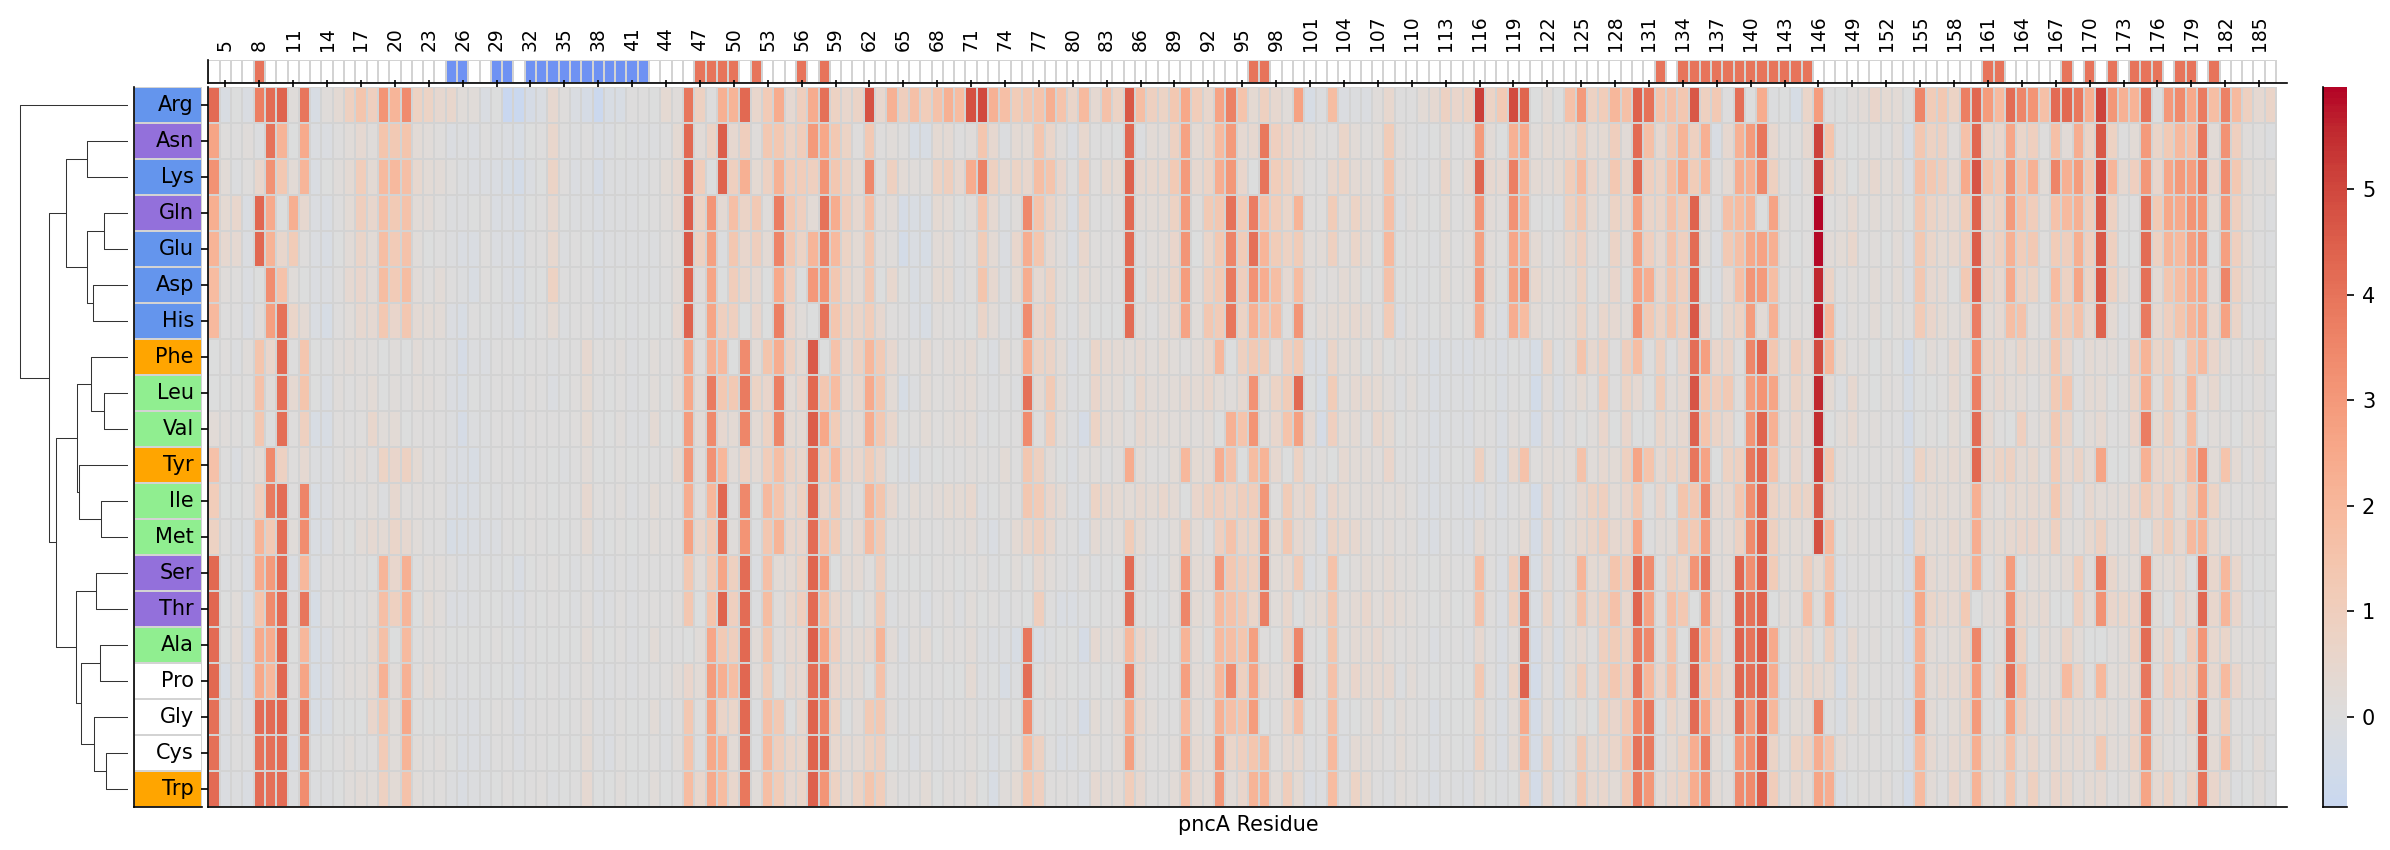

In [29]:
model_path = 'PZA_amino_acid'
gene = 'pncA'

pncA_GeO_scores, pncA_missense, pncA_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene)

In [31]:
# F58, W68, P70 -- Phe and Trp are both hydrophobic. Pro might be an electron donor because of the lone pair on N
pd.DataFrame(pncA_missense.loc[[58, 68], :])#.sort_values(68, ascending=False)

mut_AA,Ala,Arg,Asn,Asp,Cys,Gln,Glu,Gly,His,Ile,Leu,Lys,Met,Phe,Pro,Ser,Thr,Trp,Tyr,Val
58,2.634357,4.072595,2.538233,3.156142,4.159224,4.036915,3.598260,3.578436,3.989355,0.670943,1.408379,3.147347,1.557771,0.000000,3.941479,2.762997,1.790544,3.082049,1.082645,2.509243
68,-0.003256,1.599098,0.357079,0.369092,-0.026315,0.355088,0.215768,-0.049625,0.142519,0.236772,0.105994,0.807050,0.041581,0.090707,0.012420,0.091800,0.013518,0.000000,-0.004975,0.096046


In [41]:
pos = 58
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,58
mut_AA,
Asn,4.309380
Lys,4.302351
His,4.248163
Glu,4.228255
Gln,4.223792


In [42]:
pos = 68
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,68
mut_AA,
Arg,4.410510
Lys,4.107992
Asp,3.460346
Gln,2.886894
Glu,2.839460


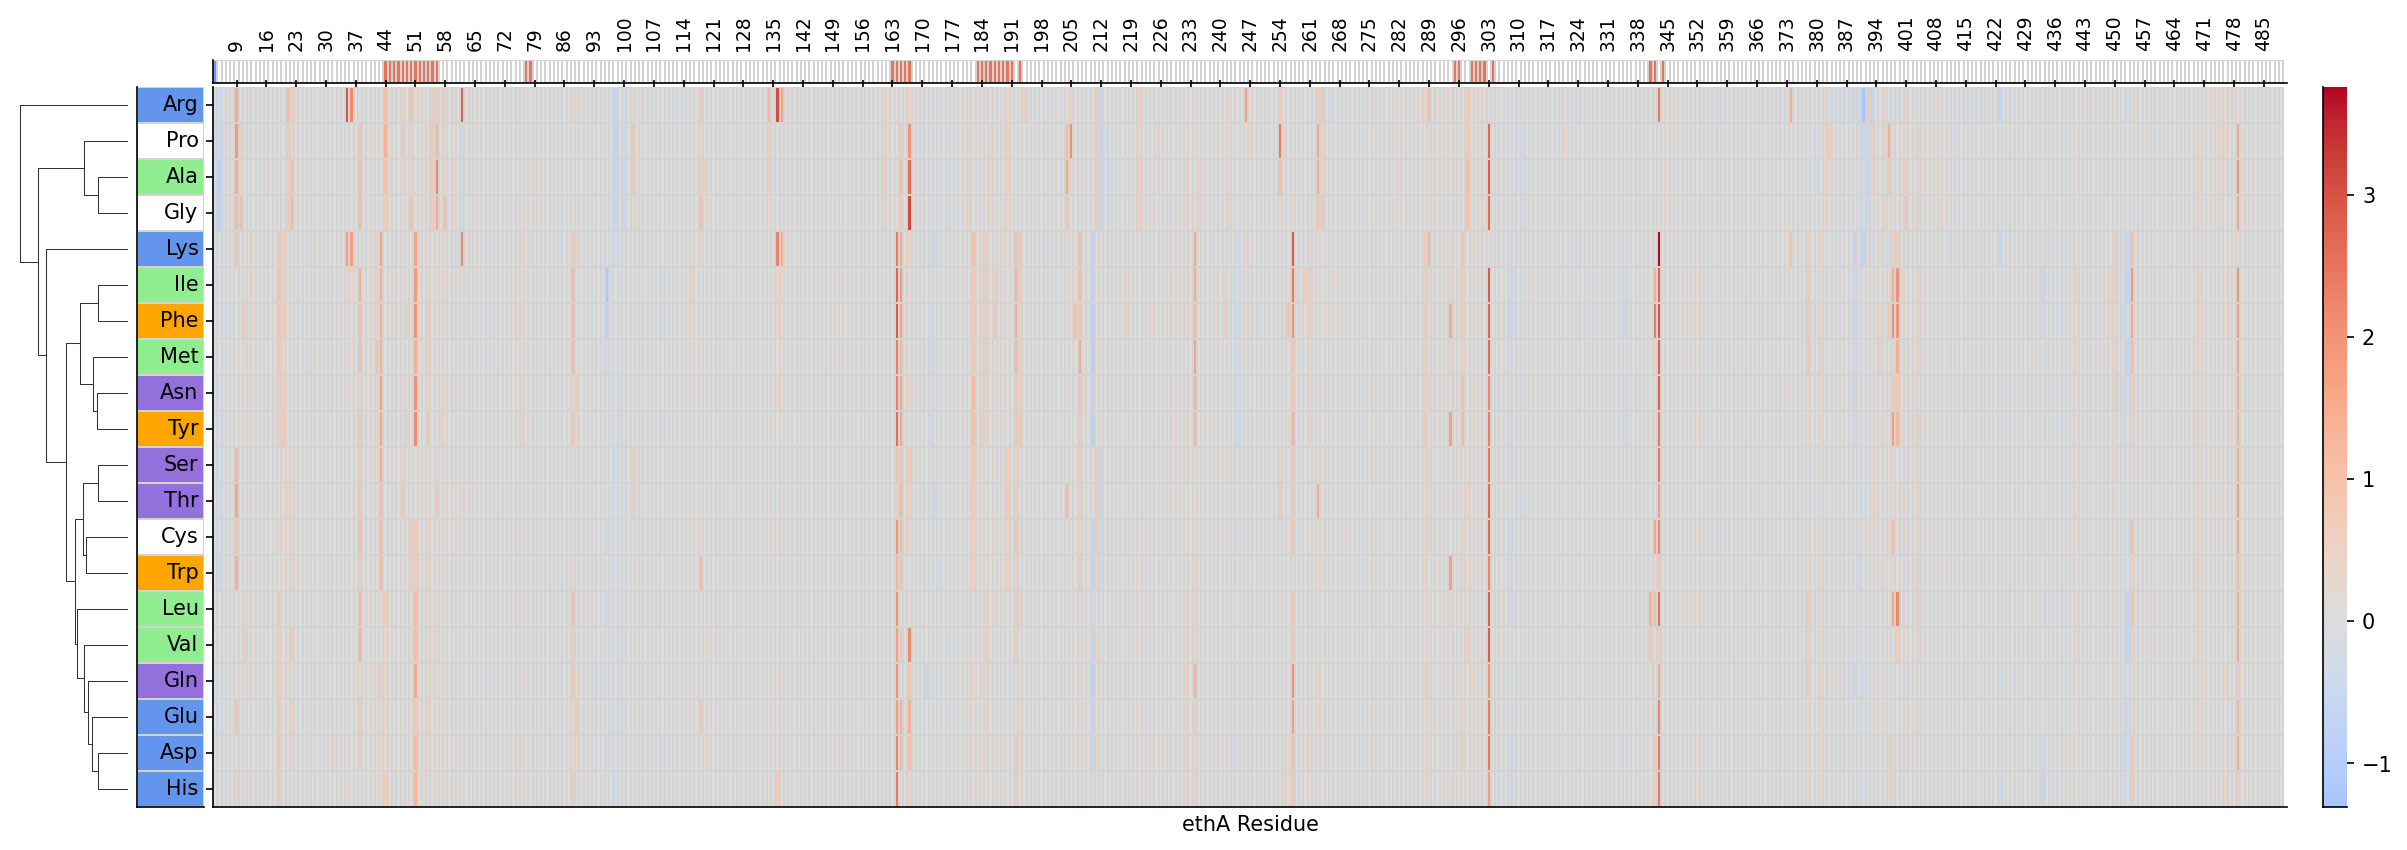

In [24]:
model_path = 'ETH_lineage_amino_acid'
gene = 'ethA'

ethA_GeO_scores, ethA_missense, ethA_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene)

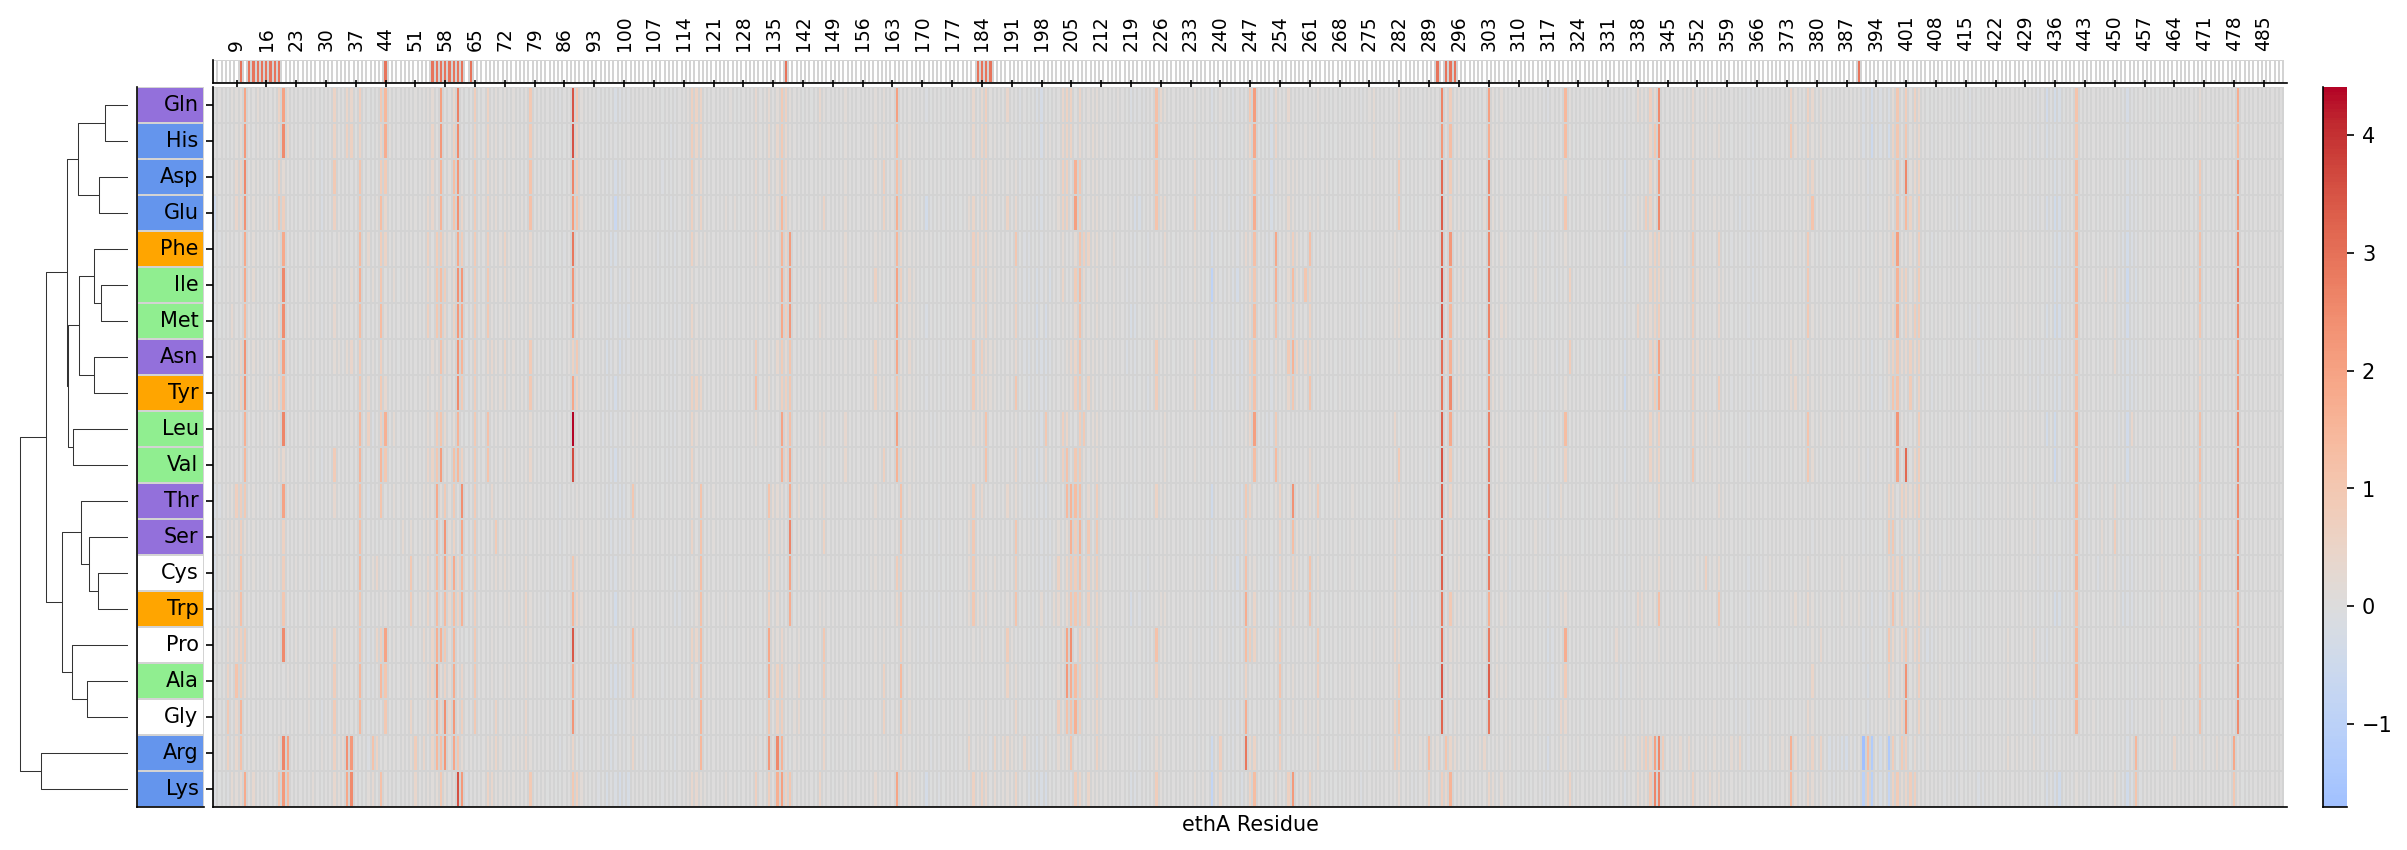

In [33]:
model_path = 'ETO_lineage_amino_acid'
gene = 'ethA'

ethA_GeO_scores, ethA_missense, ethA_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene)

In [34]:
ethA_GeO_scores.average.min()

-0.2724269143545809

In [35]:
ethA_GeO_scores.average.min()

-0.5669012049807727

In [37]:
ethA_GeO_scores.sort_values("average").head(10)

,codon,G_score,average,pval,BH_pval,Bonferroni_pval,clustering_result,color
208,210,2.662818,-0.566901,0.0140,0.104663,1.0,NaN,#ffffff
0,2,-1.889142,-0.402727,0.0100,0.094510,1.0,NaN,#ffffff
451,453,0.532112,-0.334372,0.2702,0.343235,1.0,NaN,#ffffff
3,5,-1.401769,-0.297957,0.0542,0.185279,1.0,NaN,#ffffff
306,308,0.580161,-0.295232,0.2456,0.331292,1.0,NaN,#ffffff
210,212,2.705225,-0.290394,0.0128,0.104433,1.0,NaN,#ffffff
96,98,0.030064,-0.289860,0.4498,0.472339,1.0,NaN,#ffffff
387,389,0.834644,-0.256619,0.1898,0.304573,1.0,NaN,#ffffff
389,391,1.272460,-0.255631,0.1072,0.241448,1.0,NaN,#ffffff
94,96,-0.463499,-0.246418,0.3392,0.394427,1.0,NaN,#ffffff


In [29]:
ethA_GeO_scores.head(20)

,codon,G_score,average,pval,BH_pval,Bonferroni_pval,clustering_result,color
0,2,-1.889142,-0.402727,0.0100,0.094510,1.0,NaN,#ffffff
1,3,-2.155202,-0.237362,0.0037,0.048200,1.0,-1.0,#6f92f3
2,4,-2.153458,-0.151266,0.0032,0.044183,1.0,-1.0,#6f92f3
3,5,-1.401769,-0.297957,0.0542,0.185279,1.0,NaN,#ffffff
4,6,-1.242944,-0.113436,0.0845,0.235076,1.0,NaN,#ffffff
5,7,-0.518278,0.056575,0.3110,0.370128,1.0,NaN,#ffffff
6,8,0.432371,-0.014464,0.3105,0.370128,1.0,NaN,#ffffff
7,9,0.540875,0.783237,0.2704,0.343235,1.0,NaN,#ffffff
8,10,1.811340,0.165210,0.0481,0.178340,1.0,NaN,#ffffff
9,11,1.909397,0.239117,0.0448,0.170787,1.0,NaN,#ffffff


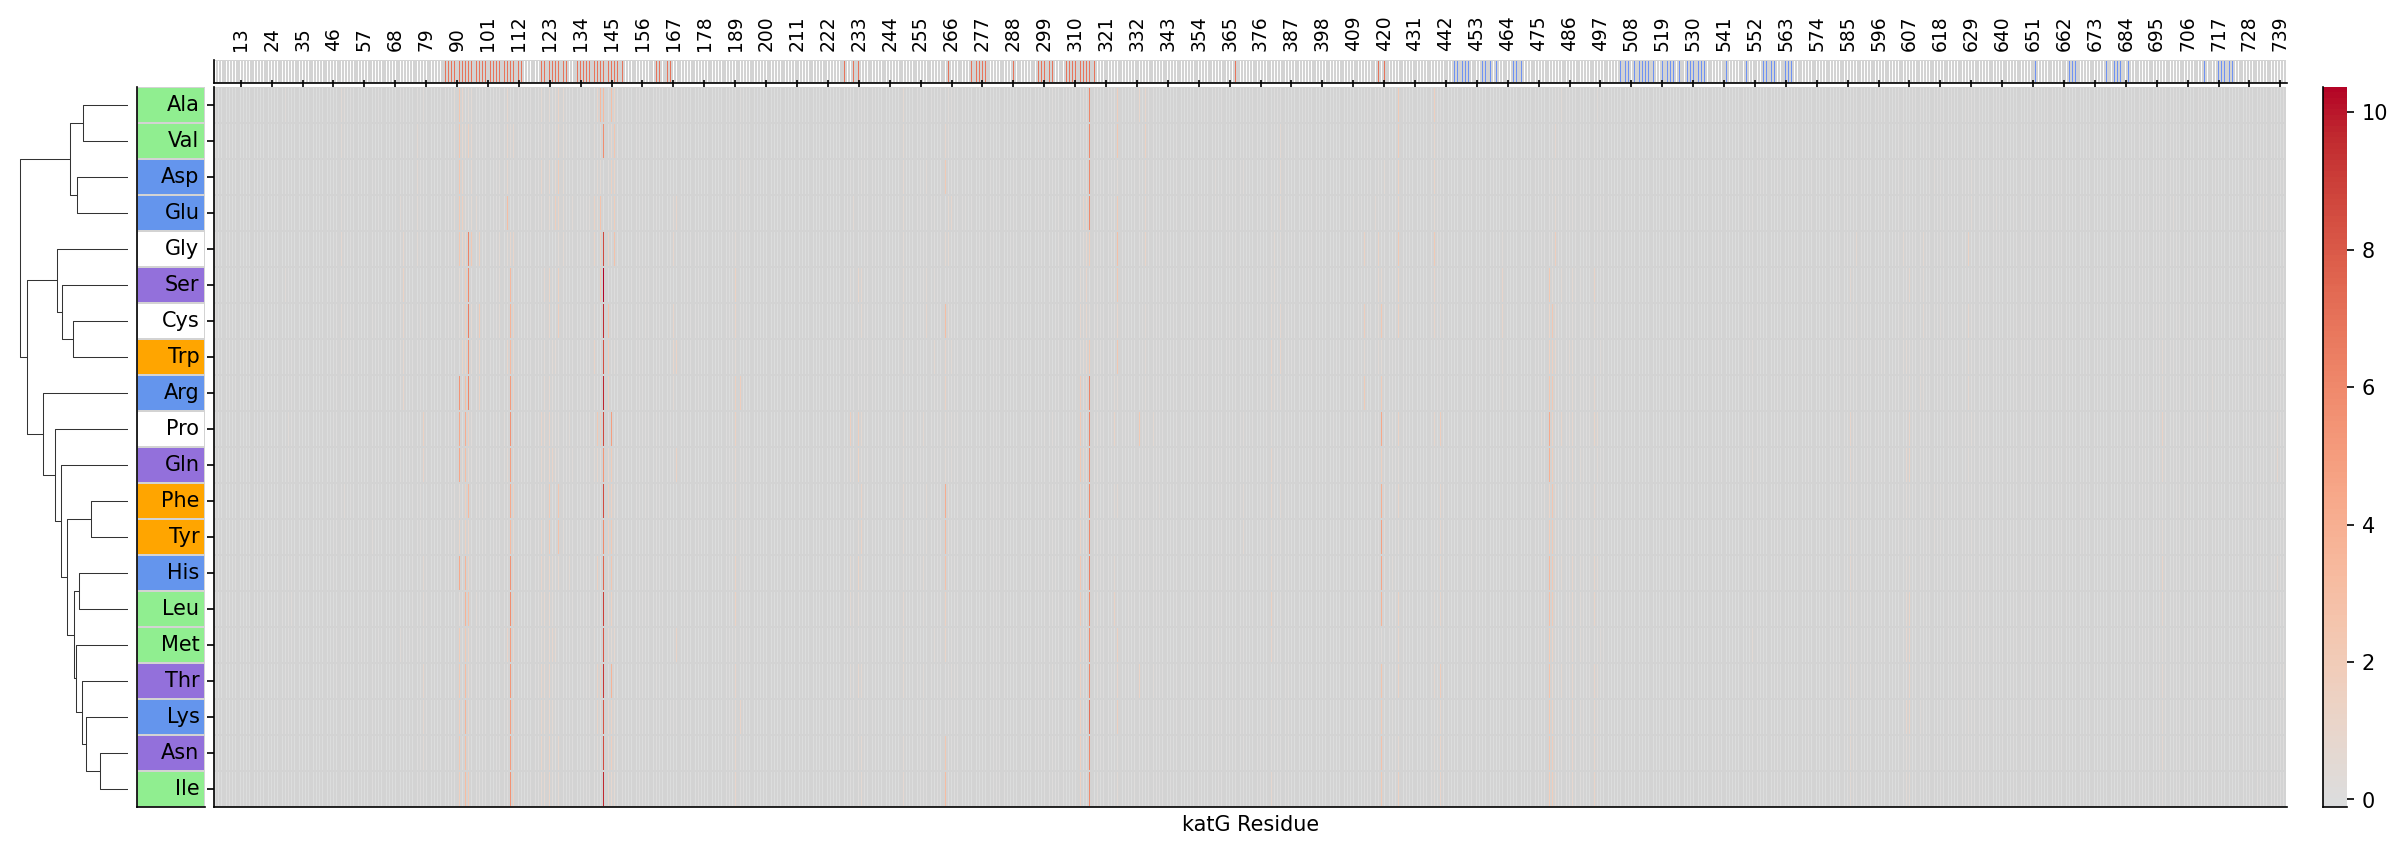

In [18]:
model_path = 'INH_lineage_amino_acid'
gene = 'katG'

katG_GeO_scores, katG_missense, katG_summary = plot_saturation_heatmap_with_GeO_colors(model_path, gene)

In [44]:
# 107, 275
katG_summary = pd.DataFrame(katG_missense.mean(axis=1)).reset_index()
katG_summary.columns = ['residue', 'average']

In [47]:
katG_summary.query("average < 0 & residue > 400").sort_values("average", ascending=True)

,residue,average
529,531,-0.025720
444,446,-0.023620
715,717,-0.018701
662,664,-0.017925
442,444,-0.017538
...,...,...
639,641,-0.000492
577,579,-0.000466
683,685,-0.000177
565,567,-0.000067


In [48]:
katG_summary.query("average < 0").sort_values("average", ascending=True)

,residue,average
17,19,-0.067475
196,198,-0.032348
377,379,-0.030900
81,83,-0.030660
242,244,-0.029477
...,...,...
395,397,-0.000411
206,208,-0.000247
683,685,-0.000177
565,567,-0.000067


# Does the CNN confuse missense and nonsense mutations?

# correlate the average log2-pred MICs (so the raw prediction) of nonsense and average missense predictions

## If there is a correlation, it is sharing information

In [110]:
# isolates_ethA_nonsense = isolate_variants.query("GENE=='ethA' & EFFECT == 'stop_gained' & variant != 'stop_gained'").ROLLINGDB_ID.unique()
# df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

# df_ETO_nonsense_train = df_ETO_phenos.merge(isolate_variants.query("GENE=='ethA' & EFFECT == 'stop_gained' & variant != 'stop_gained'")[['ROLLINGDB_ID', 'variant']], on='ROLLINGDB_ID').query("category=='train_set'")

# # merge with in silico predicted MICs
# df_ETO_nonsense_train = df_ETO_nonsense_train.merge(df_ETH_ethA[['variant', 'pred_MIC', 'codon']], on='variant')

# # df_ETO_nonsense_train.ROLLINGDB_ID.nunique()

# # df_ETO_nonsense_train_melted = df_ETO_nonsense_train[['variant', 'ROLLINGDB_ID', 'codon', 'pred_MIC', 'ETH_midpoint']].melt(id_vars=['variant', 'ROLLINGDB_ID', 'codon'])
# # df_ETO_nonsense_train_melted.ROLLINGDB_ID.nunique()

# # df_ETO_nonsense_train_melted.query("variable=='ETH_midpoint'").groupby('codon').ROLLINGDB_ID.nunique().min(), df_ETO_nonsense_train_melted.query("variable=='ETH_midpoint'").groupby('codon').ROLLINGDB_ID.nunique().max()

# sns.scatterplot(data=df_ETO_nonsense_train_melted.query("variable=='ETH_midpoint'"),
#                 x='codon',
#                 y='value',
#                 alpha=0.75,
#                 # hue='variable'
#                )

# drug = 'ETH'

# plt.axhline(y=cc_dict[drug], color='tomato', linestyle='dashed', linewidth=0.75, zorder=0, label=f'CC = {cc_dict[drug]} µg/mL')
# plt.yscale('log', base=2)
# plt.xlabel("ethA Codon")
# plt.ylabel("Ethionamide Midpoint (µg/mL)")
# plt.legend(fontsize=8)

# sns.despine()
# plt.savefig("supplement/ethionamide_midpoints_training_nonsense.svg")

In [ ]:
def compute_nonsense_missense_pred_corr(model_path, gene, corr_col='pred_MIC', log_base=2, annotate=False, codon_range=None):
    
    df_SSM = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis", "saturation_mutagenesis", gene, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'variant'})

    # add amino acid codon
    df_SSM['codon'] = df_SSM['variant'].apply(get_variant_number, args=('+'))

    # exclude the first codon too
    df_SSM = df_SSM.query("codon > 1")
    df_SSM['codon'] = df_SSM['codon'].astype(int)

    if codon_range is not None:
        codon_range = np.array(codon_range).astype(int)
        df_SSM = df_SSM.query("codon in @codon_range")
    
    df_SSM['variant'] = df_SSM['variant'].str.replace('_p_', '_p.').str.replace('+', '*')
    
    df_SSM.loc[df_SSM['variant'].str.endswith('*'), 'type'] = 'nonsense'
    df_SSM.loc[~df_SSM['variant'].str.endswith('*'), 'type'] = 'missense'

    df_SSM_summary = df_SSM.groupby(['codon', 'type'])[['log2_pred_MIC', 'pred_MIC']].mean().reset_index()
    df_SSM_summary_for_corr = df_SSM_summary.pivot(index='codon', columns='type', values=corr_col)

    print(st.spearmanr(df_SSM_summary_for_corr['missense'], df_SSM_summary_for_corr['nonsense']))

    fig, ax = plt.subplots()
    
    sns.scatterplot(data=df_SSM_summary_for_corr,
                x='missense',
                y='nonsense',
                alpha=0.75,
                    ax=ax
               )

    plt.xscale('log', base=log_base)
    plt.yscale('log', base=log_base)
    
    plt.xlabel('Average predicted MIC of Missense Mutations (µg/mL)', fontsize=10)
    plt.ylabel('Predicted MIC of Nonsense Mutations (µg/mL)', fontsize=10)

    if annotate:
        for codon in df_SSM_summary_for_corr.index.values:
            ax.text(x=df_SSM_summary_for_corr.loc[codon, 'missense'], y=df_SSM_summary_for_corr.loc[codon, 'nonsense'], s=codon, fontsize=8)
    
    sns.despine()
    plt.savefig(f"supplement/{gene}_missense_nonsense_comparison_all_codons.svg")

    return df_SSM_summary_for_corr

SignificanceResult(statistic=0.20773552989204797, pvalue=3.6950141106009745e-06)


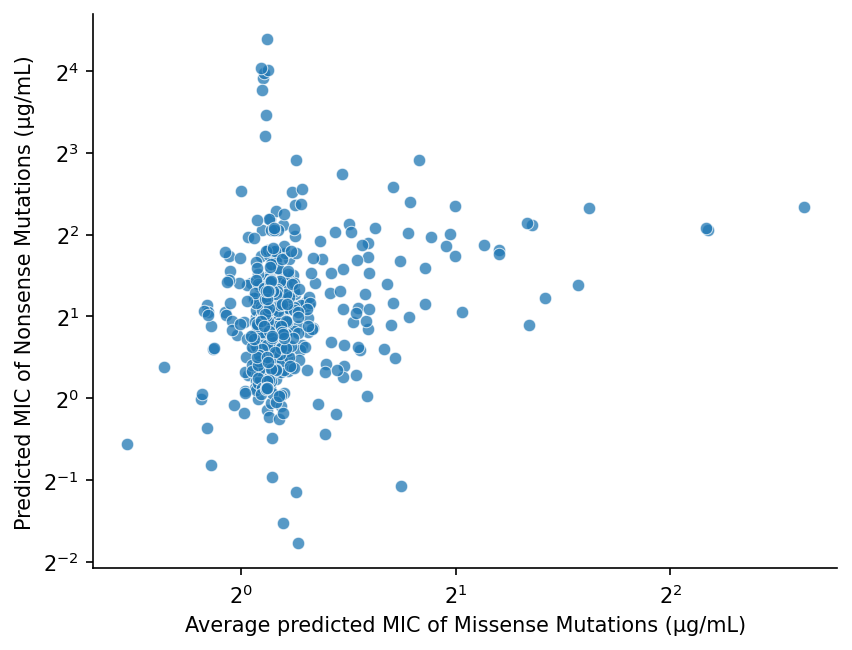

In [84]:
model_path = 'ETH_lineage_amino_acid'
gene = 'ethA'

df_SSM_summary_for_corr_ethA = compute_nonsense_missense_pred_corr(model_path, gene)

SignificanceResult(statistic=0.5833333333333334, pvalue=0.013970829934522285)


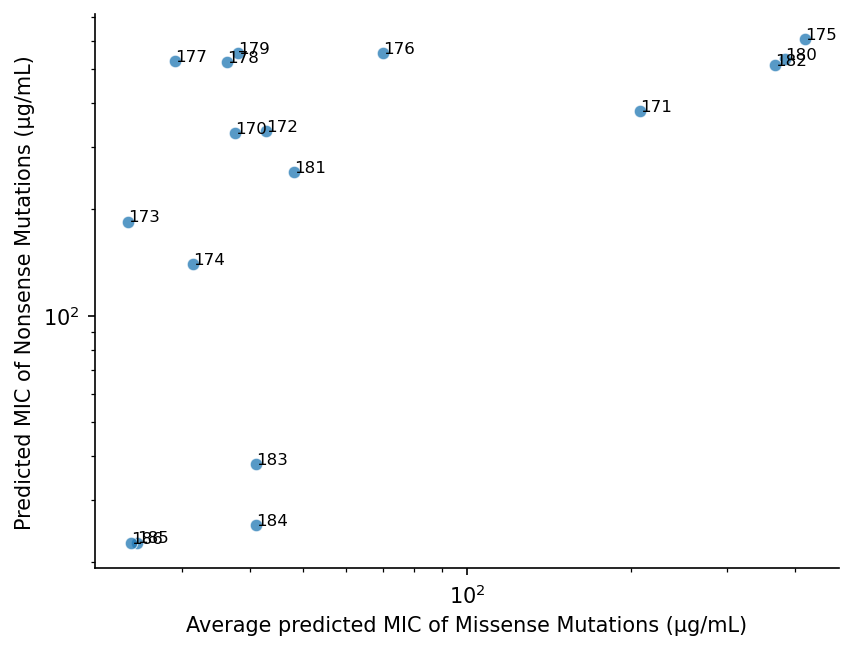

In [83]:
model_path = 'PZA_lineage_amino_acid'
gene = 'pncA'

df_SSM_summary_for_corr_pncA = compute_nonsense_missense_pred_corr(model_path, gene, log_base=10, annotate=True, codon_range=np.arange(170, 186+1))

# Hypothesize that the model associates small length changes (not early stop codons) with resistance because it learns the association between nonsense and resistance

## Compute the matched pairs difference in predicted MIC or fold change between for length-changing variants between models with and without AA features

## Restrict to protein length changing variants that are not due to early stop codons. 

In [86]:
# # get predictions from models without amino acid features
# all_drugs_insilico_pred_noAA = []

# for drug in ['RIF', 'INH', 'EMB', 'ETH', 'MXF', 'PZA', 'LEV', 'BDQ']: #os.listdir(data_dir):

#     if drug in ['MXF', 'BDQ', 'CFZ', 'DLM', 'ETH']:
#         model_path = f"{drug}_lineage"
#     else:
#         model_path = drug
        
#     df = plot_ECDF(model_path, cc_dict[drug], log_base=2, include_uncertain=True, V1=False, saveFig=False, show=False)
#     df['gene'] = df['mutation'].str.split('_').str[0]
#     df['drug'] = drug

#     all_drugs_insilico_pred_noAA.append(df)

# all_drugs_insilico_pred_noAA = pd.concat(all_drugs_insilico_pred_noAA)

In [446]:
# keep only protein-coding mutations, drop nonsense mutations
all_drugs_insilico_pred_combined_indels = pd.concat(all_drugs_insilico_pred_combined).query("mutation.str.contains('_p_') & ~mutation.str.contains('\*')").reset_index(drop=True)

all_drugs_insilico_pred_combined = all_drugs_insilico_pred_combined[['drug', 'Locus', 'gene', 'mutation', 'confidence', 'pred_MIC', 'ref_pred', 'fold_change']].rename(columns={'pred_MIC': 'pred_MIC_AA', 'fold_change': 'fold_change_AA'}).merge(all_drugs_insilico_pred_noAA[['drug', 'gene', 'mutation', 'pred_MIC', 'fold_change']], on=['drug', 'gene', 'mutation'])

all_drugs_insilico_pred_combined['pred_MIC_ratio'] = all_drugs_insilico_pred_combined['pred_MIC_AA'] / all_drugs_insilico_pred_combined['pred_MIC']
all_drugs_insilico_pred_combined['log_pred_MIC_ratio'] = np.log(all_drugs_insilico_pred_combined['pred_MIC_ratio'])

In [447]:
# get the affected codon (earliest) for each mutations
for i, row in all_drugs_insilico_pred_combined.iterrows():

    drug = row['drug']
    gene = row['gene']
    locus = row['Locus']
    mutation = row['mutation']
    
    variant = mutation.replace(row['gene'], '')

    # sense doesn't matter here unless return_start_and_end = True
    number = get_variant_number(variant, '+', return_start_and_end=False)

    all_drugs_insilico_pred_combined.loc[i, 'codon'] = number

all_drugs_insilico_pred_combined['codon'] = all_drugs_insilico_pred_combined['codon'].astype(int)

In [454]:
# get protein lengths
length_mapping_dict = {}
ref_length_mapping_dict = {}

for _, row in all_drugs_insilico_pred_combined[['drug', 'Locus']].drop_duplicates().iterrows():

    drug = row['drug']
    locus = row['Locus']
    
    df_protein_seqs = pd.read_csv(os.path.join(results_dir, drug, "inSilico_analysis", locus, "df_protein_seqs.csv"))
    
    for gene in all_drugs_insilico_pred_combined.query("Locus==@locus")['gene'].unique():
        
        df_protein_seqs[f'{gene}_length'] = df_protein_seqs[f'{gene}_AA'].str.replace('-', '').str.len()
        length_mapping_dict.update(dict(zip(df_protein_seqs.query("ROLLINGDB_ID.str.startswith(@gene)")['ROLLINGDB_ID'], df_protein_seqs.query("ROLLINGDB_ID.str.startswith(@gene)")[f'{gene}_length'])))

        ref_length_mapping_dict[gene] = df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")[f'{gene}_length'].values[0]


all_drugs_insilico_pred_combined['protein_length'] = all_drugs_insilico_pred_combined['mutation'].map(length_mapping_dict)
all_drugs_insilico_pred_combined['ref_protein_length'] = all_drugs_insilico_pred_combined['gene'].map(ref_length_mapping_dict)

assert len(all_drugs_insilico_pred_combined.loc[pd.isnull(all_drugs_insilico_pred_combined['protein_length'])]) == 0

all_drugs_insilico_pred_combined['norm_length'] = all_drugs_insilico_pred_combined['protein_length'] / all_drugs_insilico_pred_combined['ref_protein_length']
all_drugs_insilico_pred_combined['codon_prop'] = all_drugs_insilico_pred_combined['codon'] / all_drugs_insilico_pred_combined['ref_protein_length']

# remove mutations that don't change the length of the protein
all_drugs_insilico_pred_combined = all_drugs_insilico_pred_combined.query("norm_length != 1")
len(all_drugs_insilico_pred_combined)

146

In [455]:
all_drugs_insilico_pred_combined.drug.value_counts()

drug
RIF    37
ETH    31
PZA    31
INH    17
EMB    15
BDQ     9
MXF     3
LEV     3
Name: count, dtype: int64

In [456]:
# this means that there is no relationship between protein length and predicted MIC ratio
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['pred_MIC_ratio']
            )

SignificanceResult(statistic=-0.05074781118967718, pvalue=0.5429821636743852)

In [457]:
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['fold_change']
            )

SignificanceResult(statistic=-0.17289409979833406, pvalue=0.036899606847296366)

In [458]:
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['fold_change_AA']
            )

SignificanceResult(statistic=-0.20853063210284842, pvalue=0.011541579121776991)

In [459]:
all_drugs_insilico_pred_combined.pred_MIC_ratio.min(), all_drugs_insilico_pred_combined.pred_MIC_ratio.mean(), all_drugs_insilico_pred_combined.pred_MIC_ratio.max()

(6.885234429782903e-19, 8.633476884899089, 116.95235533728332)

In [336]:
# plot_col = 'log_pred_MIC_ratio'

# # Create the scatterplot with continuous hue
# scatter = sns.scatterplot(data=all_drugs_insilico_pred_combined.query("diff_length != 0 & ~mutation.str.contains('*')"),
#                           x='codon_prop',
#                           y='norm_diff_length',
#                           hue=plot_col,
#                           palette='Reds',
#                           legend=False  # We'll add a colorbar separately
#                          )

# sns.despine()

# # Create a colorbar with the Reds palette
# norm = plt.Normalize(all_drugs_insilico_pred_combined[plot_col].min(), all_drugs_insilico_pred_combined[plot_col].max())
# sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
# sm.set_array([])

# # Get the current axes
# ax = scatter.axes

# # Add a colorbar to the figure, specifying the axes
# cbar = scatter.figure.colorbar(sm, ax=ax, label=plot_col)

# plt.show()

# In silico Predictions for Individual Lineage SNPs

In [32]:
def plot_insilico_lineage_pred(drug, log_base=2, save_fName=None):
    
    df = pd.read_csv(f"{results_dir}/{drug}_lineage_amino_acid/inSilico_analysis/lineage_SNP_predictions.csv")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    plot_col = 'pred_MIC'
    
    sns.histplot(data=df, x=plot_col, stat="count", log_scale=log_base, ax=ax)
    ref_mic = df.query("Lineage=='MT_H37Rv'")[plot_col].values[0]
          
    if df[plot_col].max() > 10:
        max_val = np.rint(df[plot_col].max())
        min_val = np.rint(df[plot_col].min())
        mean_val = np.rint(df[plot_col].mean())
        ref_mic = np.rint(ref_mic)
        
    else:
        max_val = np.round(df[plot_col].max(), 2)
        min_val = np.round(df[plot_col].min(), 2)
        mean_val = np.round(df[plot_col].mean(), 2)
        ref_mic = np.round(ref_mic, 2)

    ax.axvline(x=ref_mic, color="tomato", label=f"No SNP = {ref_mic}", linestyle="--", linewidth=1)  
    
    # Force integer tick labels
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))    
    ax.set_title(f"Min = {min_val}, Mean = {mean_val}, Max = {max_val}")    
    ax.set_xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)")
    # fig.supxlabel()  # doesn't look as good
    ax.legend(fontsize=8)

    sns.despine()
    plt.tight_layout()

    if save_fName is not None:
        plt.savefig(save_fName, bbox_inches="tight", format='svg')
        # plt.close()
    else:
        plt.show()
    
    return df

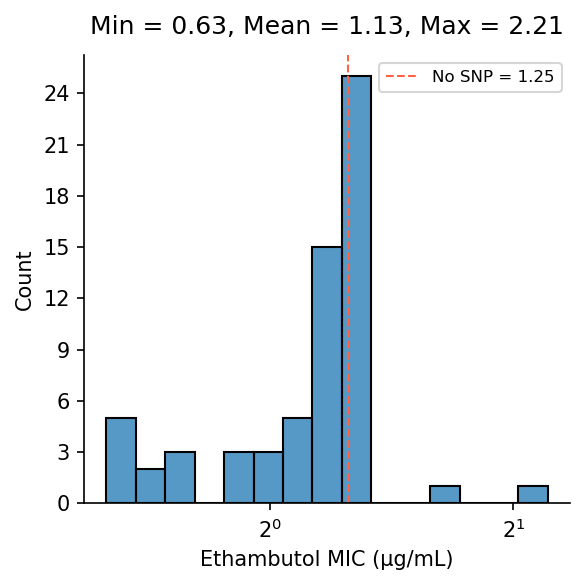

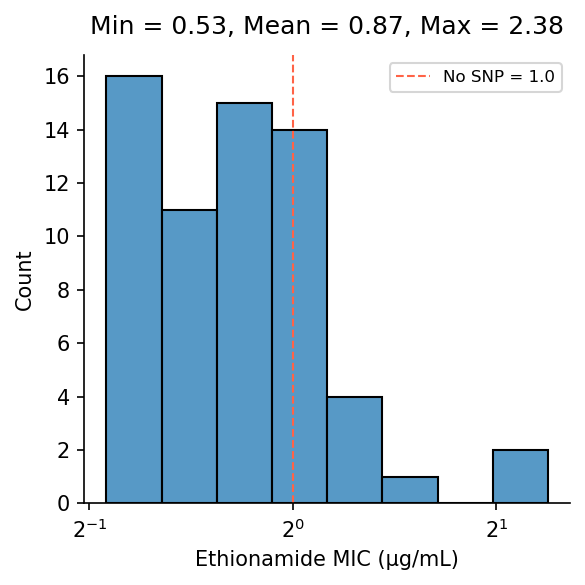

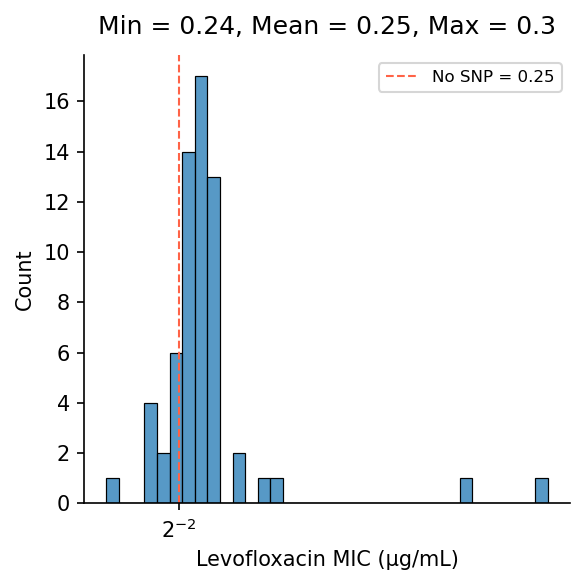

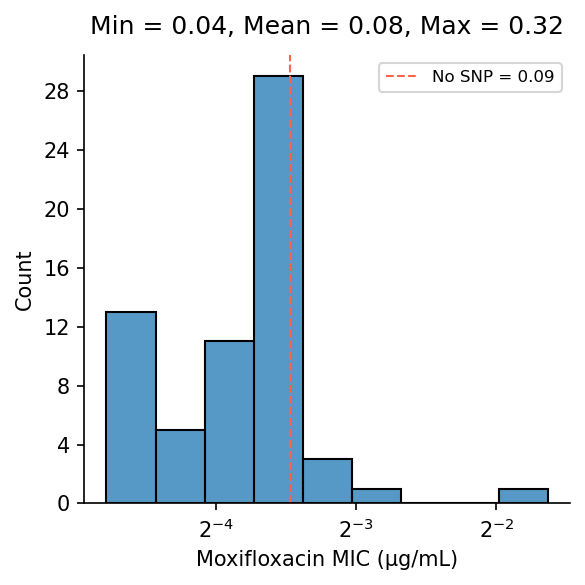

In [39]:
all_drugs_lineage_SNP_predictions = {}

for drug in ['EMB', 'ETO', 'LFX', 'MXF']:#drugs_lst:
    
    log_base = 2
    all_drugs_lineage_SNP_predictions[drug] = plot_insilico_lineage_pred(drug, log_base=log_base)#, save_fName=f"results/{abbr_drug_dict[drug]}/lineage_SNP_predictions.svg")

In [40]:
all_drugs_lineage_SNP_predictions['MXF'].sort_values("pred_MIC")

,Lineage,Position,log2_pred_MIC,pred_MIC
16,3.1.1,1084911,-4.779185,0.036418
17,4.3.4.2,1132368,-4.751926,0.037113
18,7,1137518,-4.747627,0.037224
15,4,931123,-4.747067,0.037238
19,3.1.2.1,1237818,-4.740268,0.037414
...,...,...,...,...
8,4.3.1,615614,-3.374622,0.096413
10,4.3,764995,-3.206440,0.108334
58,4.4,4307886,-3.155966,0.112191
50,4.3.4,3977226,-2.802173,0.143371


In [43]:
df_MXF = pd.read_csv(f"{data_dir}/MXF/data_for_model.csv")
df_MXF.query("Coll2014 in ['4.1.2', '4', '4.1']").MXF_midpoint.mean()

0.42668006993006996

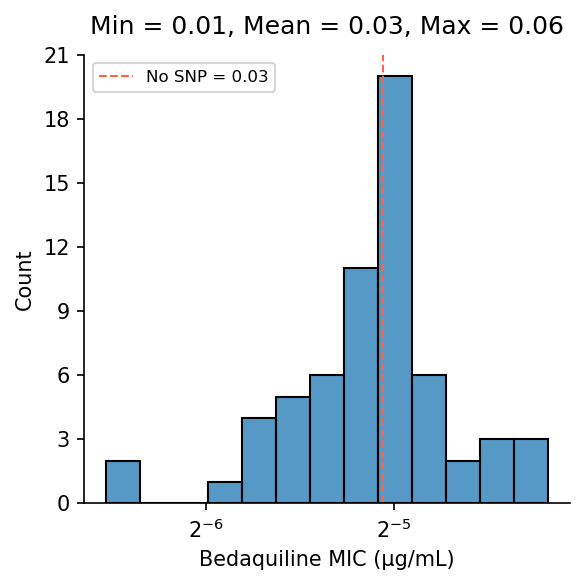

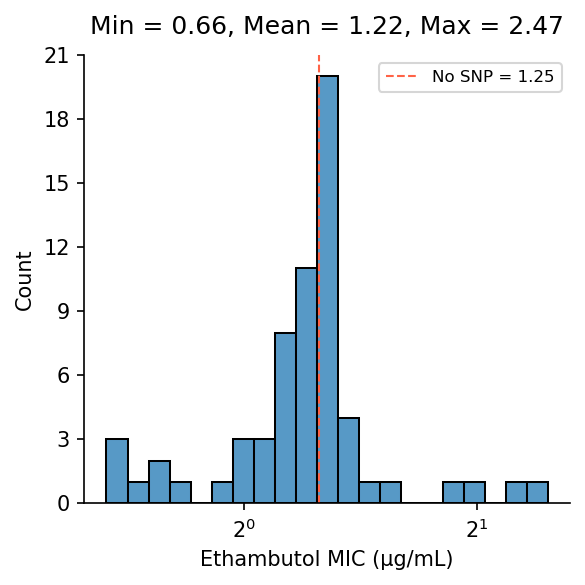

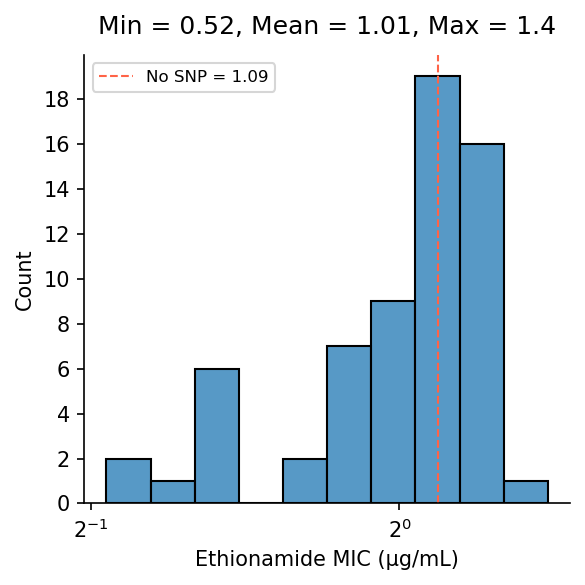

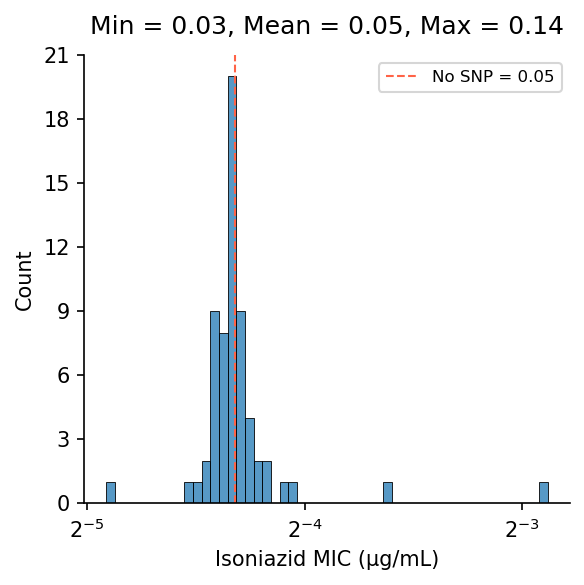

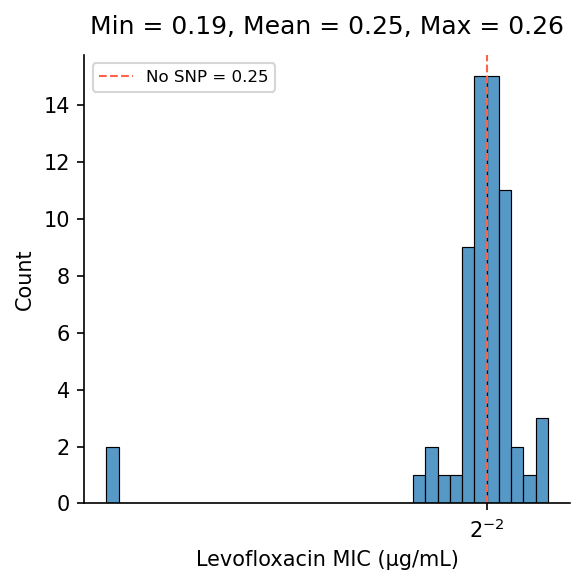

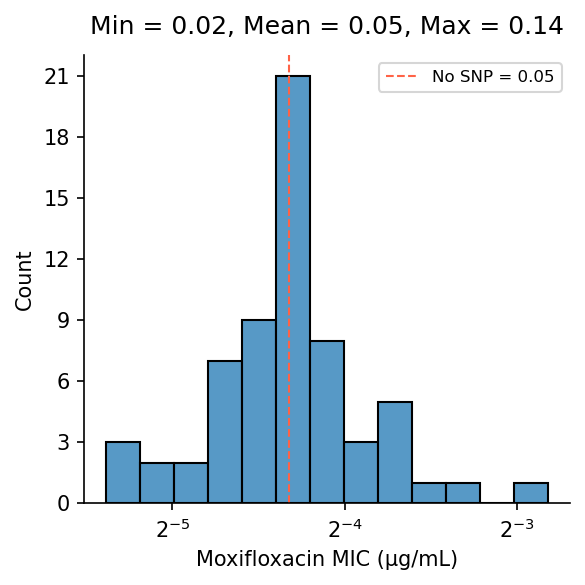

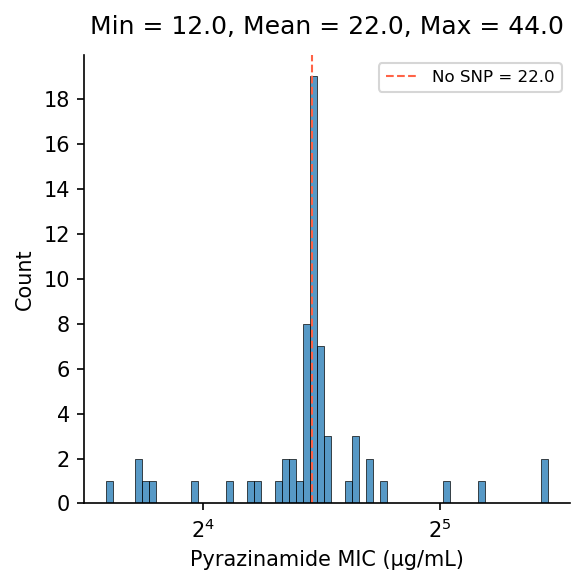

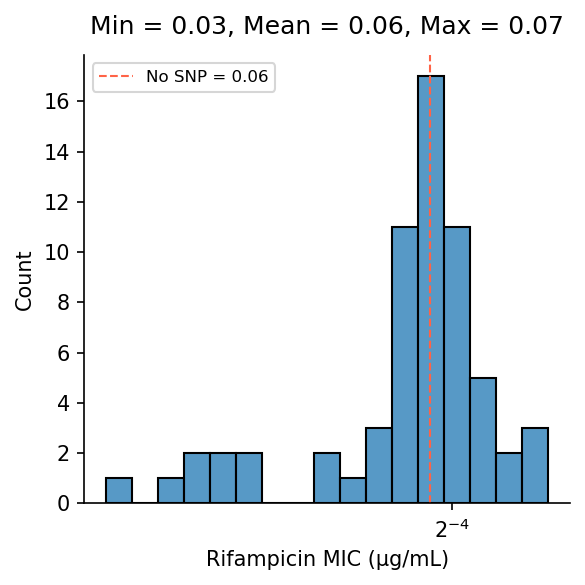

In [89]:
all_drugs_lineage_SNP_predictions = {}

for drug in os.listdir(data_dir):
    
    log_base = 2
    all_drugs_lineage_SNP_predictions[drug] = plot_insilico_lineage_pred(drug, log_base=log_base, save_fName=f"results/{abbr_drug_dict[drug]}/lineage_SNP_predictions.svg")

In [78]:
all_drugs_lineage_SNP_predictions['INH'].sort_values("pred_MIC", ascending=False)

,Lineage,Position,log2_pred_MIC,pred_MIC
50,4.3.4,3977226,-2.882208,0.135634
16,3.1.1,1084911,-3.602568,0.082323
39,1.1.1,3021283,-4.074529,0.059353
45,1.2.1,3479545,-4.104288,0.058141
31,BOV_AFRI,1882180,-4.181330,0.055118
...,...,...,...,...
58,4.4,4307886,-4.464530,0.045294
53,4.1.1.3,4229087,-4.473179,0.045023
52,4.4.1,4151558,-4.506425,0.043998
44,1.2.2,3470377,-4.548410,0.042736


In [60]:
all_drugs_lineage_SNP_predictions['INH'].query("Lineage=='2.2.1'")

,Lineage,Position,log2_pred_MIC,pred_MIC
12,2.2.1,797736,-4.308042,0.050484


In [35]:
all_drugs_lineage_SNP_predictions['BDQ'].query("Lineage in ['2.2.1', '2.2.1.1', '2.2.1.2']")

,Lineage,Position,log2_pred_MIC,pred_MIC
12,2.2.1,797736,-4.273495,0.051707
48,2.2.1.2,3836274,-6.355973,0.012208
55,2.2.1.1,4248115,-4.996188,0.031333
